This essentially enables you to download the dataset from MedMNIST 

In [ ]:
import medmnist
from medmnist import DermaMNIST #REPLACE
import numpy as np

# Choose the image size (28 for classic, or 64/128/224 for MedMNIST+)
IMG_SIZE = 28  

# Download DermMNIST (train/val/test) automatically
train_dataset = DermaMNIST(split="train", download=True, size=IMG_SIZE) #REPLACE
val_dataset   = DermaMNIST(split="val", download=True, size=IMG_SIZE) #REPLACE
test_dataset  = DermaMNIST(split="test", download=True, size=IMG_SIZE) #REPLACE

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

# Each dataset item is a tuple (PIL.Image, label)
img, label = train_dataset[0]

# Convert PIL image → NumPy array
img_array = np.array(img)

print("Sample image shape:", img_array.shape, "Label:", label)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# Load CSV
# ---------------------------
csv_path = "/Users/arihangupta/Downloads/dermamnist_surgery_pruning_metrics.csv"  # update with your path
df = pd.read_csv(csv_path)

# ---------------------------
# Preprocess
# ---------------------------
# Convert Ratio to percentage for plotting
df['RatioPercent'] = df['Ratio'] * 100

# ---------------------------
# Plot Accuracy vs Pruning Ratio
# ---------------------------
plt.figure(figsize=(8,6))
sns.lineplot(
    data=df[df['Stage'].str.contains("after_finetune")], 
    x='RatioPercent', y='Acc', hue='Variant', marker='o'
)
plt.title("Post-Finetune Accuracy vs Pruning Ratio")
plt.xlabel("Pruning Ratio (%)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend(title="Pruning Method")
plt.tight_layout()
plt.show()

# ---------------------------
# Plot AUC vs Pruning Ratio
# ---------------------------
plt.figure(figsize=(8,6))
sns.lineplot(
    data=df[df['Stage'].str.contains("after_finetune")], 
    x='RatioPercent', y='AUC', hue='Variant', marker='o'
)
plt.title("Post-Finetune AUC vs Pruning Ratio")
plt.xlabel("Pruning Ratio (%)")
plt.ylabel("AUC")
plt.grid(True)
plt.legend(title="Pruning Method")
plt.tight_layout()
plt.show()

# ---------------------------
# Plot Params vs Pruning Ratio
# ---------------------------
plt.figure(figsize=(8,6))
sns.lineplot(
    data=df[df['Stage'].str.contains("after_finetune")],
    x='RatioPercent', y='Params', hue='Variant', marker='o'
)
plt.title("Parameters vs Pruning Ratio")
plt.xlabel("Pruning Ratio (%)")
plt.ylabel("Number of Parameters")
plt.grid(True)
plt.legend(title="Pruning Method")
plt.tight_layout()
plt.show()

# ---------------------------
# Plot FLOPs vs Pruning Ratio
# ---------------------------
plt.figure(figsize=(8,6))
sns.lineplot(
    data=df[df['Stage'].str.contains("after_finetune")],
    x='RatioPercent', y='FLOPs_per_image', hue='Variant', marker='o'
)
plt.title("FLOPs vs Pruning Ratio")
plt.xlabel("Pruning Ratio (%)")
plt.ylabel("FLOPs per Image")
plt.grid(True)
plt.legend(title="Pruning Method")
plt.tight_layout()
plt.show()


Block-by-Block pruning

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("/Users/arihangupta/Downloads/dermamnist_pgto_pruning_metrics.csv")

# Map Stage -> Block
def stage_to_block(stage):
    if stage == "baseline":
        return 0
    elif "layer1" in stage:
        return 1
    elif "layer2" in stage:
        return 2
    elif "layer3" in stage:
        return 3
    elif "layer4" in stage:
        return 4
    elif "finetune" in stage:
        return 5
    return None

df["Block"] = df["Stage"].apply(stage_to_block)

# Variants of interest
variants = [
    ("l1", 0.5),
    ("l1", 0.7),
    ("bn_gamma", 0.5),
    ("bn_gamma", 0.7),
]

# Metrics
metrics = ["Acc", "AUC", "Loss", "FLOPs_M_per_image", 
           "ModelSizeMB", "InferenceTime_per_batch32_s", "PeakRAM_MB"]

for metric in metrics:
    plt.figure(figsize=(8,5))

    for method, ratio in variants:
        # Get variant rows
        subset = df[(df["Variant"] == method) & (df["Ratio"] == ratio)]

        # Append baseline (Block 0) explicitly
        baseline = df[df["Stage"] == "baseline"].copy()
        baseline["Variant"] = method
        baseline["Ratio"] = ratio
        subset = pd.concat([baseline, subset]).sort_values("Block")

        # Plot
        plt.plot(
            subset["Block"], subset[metric],
            marker="o", label=f"{method}-{ratio}"
        )

    plt.xlabel("Block")
    plt.ylabel(metric)
    plt.title(f"{metric} vs Block")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Ensure x-axis is discrete integers only
    plt.xticks(sorted(df["Block"].dropna().unique()))

    # Add padding to y-limits so curves don’t get cut off
    ymin, ymax = plt.ylim()
    plt.ylim(ymin - 0.05*(ymax-ymin), ymax + 0.05*(ymax-ymin))

    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("/Users/arihangupta/Downloads/dermamnist_surgery_pruning_metrics.csv")

# Keep only baseline + after_finetune rows
df_baseline = df[df["Stage"] == "baseline"]
df_after = df[df["Stage"] == "after_finetune"]

# Metrics to plot
metrics = ["Acc", "AUC", "Loss", "FLOPs_M_per_image", 
           "ModelSizeMB", "InferenceTime_per_batch32_s", "PeakRAM_MB"]

# Variants of interest
variants = df_after["Variant"].unique()

for metric in metrics:
    plt.figure(figsize=(8,5))

    for variant in variants:
        # Get baseline row
        baseline_row = df_baseline.copy()
        baseline_row["Variant"] = variant  # assign to variant line

        # Get after_finetune rows for this variant
        after_rows = df_after[df_after["Variant"] == variant]

        # Combine baseline + after
        plot_data = pd.concat([baseline_row, after_rows]).sort_values("Ratio")

        plt.plot(
            plot_data["Ratio"], plot_data[metric],
            marker="o", label=variant
        )

    plt.xlabel("Pruning Ratio")
    plt.ylabel(metric)
    plt.title(f"{metric} vs Pruning Ratio (Baseline + After Finetune)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # X-axis ticks = all ratios including 0 for baseline
    plt.xticks(sorted(plot_data["Ratio"].unique()))

    # Add y-axis padding
    ymin, ymax = plt.ylim()
    plt.ylim(ymin - 0.05*(ymax-ymin), ymax + 0.05*(ymax-ymin))

    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("/Users/arihangupta/Downloads/bloodmnist_pgto_pruning_metrics_progressive_fixed_with_energy.csv")

# Keep only desired stages
stages_keep = ["postcalib", "after_kd", "after_global_finetune", "baseline"]
df = df[df["Stage"].apply(lambda s: any(k in s for k in stages_keep))].copy()

# Map Stage -> Block index
def stage_to_block(stage: str):
    if stage == "baseline":
        return 0
    elif "layer1" in stage and "postcalib" in stage:
        return 1
    elif "layer2" in stage and "postcalib" in stage:
        return 2
    elif "layer3" in stage and "postcalib" in stage:
        return 3
    elif "layer4" in stage and "postcalib" in stage:
        return 4
    elif stage == "after_kd":
        return 5
    elif stage == "after_global_finetune":
        return 6
    return None

df["Block"] = df["Stage"].apply(stage_to_block)

# Use all unique (Variant, Ratio) pairs
variants = df[["Variant", "Ratio"]].drop_duplicates().values.tolist()

# Metrics to plot
metrics = [
    "Acc", "AUC", "Loss",
    "FLOPs_M_per_image", "ModelSizeMB",
    "InferenceTime_per_batch_s", "PeakRAM_MB"
]

for metric in metrics:
    plt.figure(figsize=(9,5))

    for method, ratio in variants:
        # Get subset
        subset = df[(df["Variant"] == method) & (df["Ratio"] == ratio)].copy()

        # Add baseline explicitly for this variant/ratio
        baseline = df[df["Stage"] == "baseline"].copy()
        baseline["Variant"] = method
        baseline["Ratio"] = ratio
        subset = pd.concat([baseline, subset])

        # Order by Block
        subset = subset.sort_values("Block")

        # Plot
        plt.plot(
            subset["Block"], subset[metric],
            marker="o", label=f"{method}-{ratio}"
        )

    plt.xlabel("Block")
    plt.ylabel(metric)
    plt.title(f"{metric} vs Block")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # X-axis ticks
    plt.xticks(sorted(df["Block"].dropna().unique()))

    # Add y padding
    ymin, ymax = plt.ylim()
    plt.ylim(ymin - 0.05*(ymax-ymin), ymax + 0.05*(ymax-ymin))

    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import numpy as np

def visualize_pruning_metrics(root_path):
    subdirs = ['bloodmnist', 'dermamnist', 'octmnist', 'pathmnist', 'tissuemnist']
    
    # Dataset-specific image counts for inference (WARMUP=5 + TIMING_BATCHES=30) * batch_size
    INFERENCE_IMAGE_COUNTS = {
        'dermamnist': (5 + 30) * 32,   # 1120 images
        'pathmnist': (5 + 30) * 16,    # 560 images
        'bloodmnist': (5 + 30) * 32,   # 1120 images
        'octmnist': (5 + 30) * 16,     # 560 images
        'tissuemnist': (5 + 30) * 8    # 280 images
    }
    
    for subdir in subdirs:
        subdir_path = os.path.join(root_path, subdir)
        pruning_csv = os.path.join(subdir_path, f"{subdir}_pgto_pruning_metrics_progressive_fixed_with_energy.csv")
        emissions_csv = os.path.join(subdir_path, 'emissions.csv')
        
        if not os.path.exists(pruning_csv):
            print(f"Pruning CSV not found for {subdir}: {pruning_csv}")
            continue
        if not os.path.exists(emissions_csv):
            print(f"Emissions CSV not found for {subdir}: {emissions_csv}")
            continue
        
        # Load and process pruning metrics
        df = pd.read_csv(pruning_csv)
        
        # Keep only desired stages
        stages_keep = ["postcalib", "after_kd", "after_global_finetune", "baseline"]
        df = df[df["Stage"].apply(lambda s: any(k in s for k in stages_keep))].copy()
        
        # Map Stage -> Block index
        def stage_to_block(stage: str):
            if stage == "baseline":
                return 0
            elif "layer1" in stage and "postcalib" in stage:
                return 1
            elif "layer2" in stage and "postcalib" in stage:
                return 2
            elif "layer3" in stage and "postcalib" in stage:
                return 3
            elif "layer4" in stage and "postcalib" in stage:
                return 4
            elif stage == "after_kd":
                return 5
            elif stage == "after_global_finetune":
                return 6
            return None
        
        df["Block"] = df["Stage"].apply(stage_to_block)
        
        # Use all unique (Variant, Ratio) pairs
        variants = df[["Variant", "Ratio"]].drop_duplicates().values.tolist()
        
        # Metrics to plot
        metrics = [
            "Acc", "AUC", "Loss",
            "FLOPs_M_per_image", "ModelSizeMB",
            "InferenceTime_per_batch_s", "PeakRAM_MB"
        ]
        
        # Create a subplot for all metrics for this dataset
        fig, axs = plt.subplots(2, 4, figsize=(20, 10))
        axs = axs.ravel()
        
        for idx, metric in enumerate(metrics):
            ax = axs[idx]
            
            for method, ratio in variants:
                # Get subset
                subset = df[(df["Variant"] == method) & (df["Ratio"] == ratio)].copy()
                
                # Add baseline explicitly for this variant/ratio
                baseline = df[df["Stage"] == "baseline"].copy()
                baseline["Variant"] = method
                baseline["Ratio"] = ratio
                subset = pd.concat([baseline, subset])
                
                # Order by Block
                subset = subset.sort_values("Block")
                
                # Plot
                ax.plot(
                    subset["Block"], subset[metric],
                    marker="o", label=f"{method}-{ratio}"
                )
            
            ax.set_xlabel("Block")
            ax.set_ylabel(metric)
            ax.set_title(f"{metric} vs Block ({subdir})")
            ax.legend()
            ax.grid(True, alpha=0.3)
            
            # X-axis ticks
            unique_blocks = sorted(df["Block"].dropna().unique())
            ax.set_xticks(unique_blocks)
            
            # Add y padding
            ymin, ymax = ax.get_ylim()
            ax.set_ylim(ymin - 0.05*(ymax-ymin), ymax + 0.05*(ymax-ymin))
        
        plt.tight_layout()
        plt.show()
        
        # Emissions/energy handling
        df_em = pd.read_csv(emissions_csv)
        
        # Parse project_name to extract variant, ratio, and type
        def parse_project_name(name):
            if 'baseline_inference' in name:
                return 'baseline', 0, 'inference'
            match = re.search(r'(.+)_r(\d+)_prune_retrain', name)
            if match:
                variant, ratio_str = match.groups()
                return variant, int(ratio_str), 'prune_retrain'
            match = re.search(r'(.+)_r(\d+)_pruned_inference', name)
            if match:
                variant, ratio_str = match.groups()
                return variant, int(ratio_str), 'pruned_inference'
            return None, None, None
        
        df_em[['Variant', 'Ratio', 'Type']] = df_em['project_name'].apply(
            lambda x: pd.Series(parse_project_name(x))
        )
        
        # Filter valid parses
        df_em_valid = df_em.dropna(subset=['Variant', 'Ratio', 'Type'])
        
        # Get baseline per-image cost
        num_images = INFERENCE_IMAGE_COUNTS.get(subdir, 1000)  # Fallback to 1000
        baseline_rows = df_em_valid[(df_em_valid['Variant'] == 'baseline') & (df_em_valid['Type'] == 'inference')]
        baseline_emissions_per_image = baseline_rows['emissions'].sum() / num_images if len(baseline_rows) > 0 else np.nan
        baseline_energy_per_image = baseline_rows['energy_consumed'].sum() / num_images if len(baseline_rows) > 0 else np.nan
        
        # Group by Variant, Ratio, Type and sum
        agg_df = df_em_valid.groupby(['Variant', 'Ratio', 'Type'])[['emissions', 'energy_consumed']].sum().reset_index()
        
        # Pivot to get prune_retrain (C) and pruned_inference (B)
        pruned_df = agg_df[agg_df['Type'] == 'pruned_inference'].rename(
            columns={'emissions': 'B_emissions', 'energy_consumed': 'B_energy'}
        )
        retrain_df = agg_df[agg_df['Type'] == 'prune_retrain'].rename(
            columns={'emissions': 'C_emissions', 'energy_consumed': 'C_energy'}
        )
        
        # Merge on Variant and Ratio
        merged = pd.merge(
            pruned_df[['Variant', 'Ratio', 'B_emissions', 'B_energy']],
            retrain_df[['Variant', 'Ratio', 'C_emissions', 'C_energy']],
            on=['Variant', 'Ratio'], how='inner'
        )
        
        # Compute per-image inference costs for pruned models
        merged['B_emissions_per_image'] = merged['B_emissions'] / num_images
        merged['B_energy_per_image'] = merged['B_energy'] / num_images
        
        # Compute intersection points to set x-axis scale
        valid_intersections_em = []
        valid_intersections_en = []
        for _, row in merged.iterrows():
            B_em_per_image = row['B_emissions_per_image']
            C_em = row['C_emissions']
            B_en_per_image = row['B_energy_per_image']
            C_en = row['C_energy']
            
            # Emissions intersection
            if not np.isnan(baseline_emissions_per_image) and baseline_emissions_per_image > B_em_per_image:
                delta_em = baseline_emissions_per_image - B_em_per_image
                break_even_x_em = C_em / delta_em
                if break_even_x_em > 0:
                    valid_intersections_em.append(break_even_x_em)
            
            # Energy intersection
            if not np.isnan(baseline_energy_per_image) and baseline_energy_per_image > B_en_per_image:
                delta_en = baseline_energy_per_image - B_en_per_image
                break_even_x_en = C_en / delta_en
                if break_even_x_en > 0:
                    valid_intersections_en.append(break_even_x_en)
        
        # Set max_images based on intersections
        DEFAULT_MAX_IMAGES = 100000
        MAX_IMAGES_CAP = 1000000
        max_images_em = max(valid_intersections_em) * 1.2 if valid_intersections_em else DEFAULT_MAX_IMAGES
        max_images_en = max(valid_intersections_en) * 1.2 if valid_intersections_en else DEFAULT_MAX_IMAGES
        max_images_em = min(max(max_images_em, 10000), MAX_IMAGES_CAP)
        max_images_en = min(max(max_images_en, 10000), MAX_IMAGES_CAP)
        
        unique_variants = merged['Variant'].unique()
        
        # Plot for emissions
        if not merged.empty and not np.isnan(baseline_emissions_per_image):
            plt.figure(figsize=(10, 6))
            
            # Baseline line: A(x)
            x_values = np.linspace(0, max_images_em, 100)
            plt.plot(x_values, baseline_emissions_per_image * x_values, 
                     linestyle='--', color='gray', label='Baseline (A)')
            
            # Pruned totals: B(x) + C
            for variant in unique_variants:
                subset = merged[merged['Variant'] == variant].sort_values('Ratio')
                for _, row in subset.iterrows():
                    ratio = row['Ratio']
                    B_per_image = row['B_emissions_per_image']
                    C = row['C_emissions']
                    plt.plot(x_values, (B_per_image * x_values) + C, 
                             marker=None, label=f"{variant} r{ratio} (B(x) + C)")
                    
                    # Plot intersection
                    if baseline_emissions_per_image > B_per_image:
                        break_even_x = C / (baseline_emissions_per_image - B_per_image)
                        if 0 < break_even_x < max_images_em:
                            break_even_y = baseline_emissions_per_image * break_even_x
                            plt.plot(break_even_x, break_even_y, 'ro', markersize=8)
                            plt.text(break_even_x, break_even_y, f'x={int(break_even_x)}', 
                                     verticalalignment='bottom', horizontalalignment='left', fontsize=10)
            
            plt.xlabel("Number of Images")
            plt.ylabel("Cumulative Emissions (kg CO2eq)")
            plt.title(f"Baseline vs Pruned Total Emissions ({subdir})")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print(f"No valid emissions data for {subdir}")
        
        # Plot for energy_consumed
        if not merged.empty and not np.isnan(baseline_energy_per_image):
            plt.figure(figsize=(10, 6))
            
            # Baseline line: A(x)
            x_values = np.linspace(0, max_images_en, 100)
            plt.plot(x_values, baseline_energy_per_image * x_values, 
                     linestyle='--', color='gray', label='Baseline (A)')
            
            # Pruned totals: B(x) + C
            for variant in unique_variants:
                subset = merged[merged['Variant'] == variant].sort_values('Ratio')
                for _, row in subset.iterrows():
                    ratio = row['Ratio']
                    B_per_image = row['B_energy_per_image']
                    C = row['C_energy']
                    plt.plot(x_values, (B_per_image * x_values) + C, 
                             marker=None, label=f"{variant} r{ratio} (B(x) + C)")
                    
                    # Plot intersection
                    if baseline_energy_per_image > B_per_image:
                        break_even_x = C / (baseline_energy_per_image - B_per_image)
                        if 0 < break_even_x < max_images_en:
                            break_even_y = baseline_energy_per_image * break_even_x
                            plt.plot(break_even_x, break_even_y, 'ro', markersize=8)
                            plt.text(break_even_x, break_even_y, f'x={int(break_even_x)}', 
                                     verticalalignment='bottom', horizontalalignment='left', fontsize=10)
            
            plt.xlabel("Number of Images")
            plt.ylabel("Cumulative Energy Consumed (kWh)")
            plt.title(f"Baseline vs Pruned Total Energy ({subdir})")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print(f"No valid energy data for {subdir}")

visualize_pruning_metrics("/Users/arihangupta/Downloads/pruning_project_data/exp3")

In [ ]:
#!/usr/bin/env python3
"""
Visualization script for combined pruning + KD CSVs across all datasets.
For each dataset and metric, generates a separate bar graph comparing baseline + final models
('after_global_finetune' stage) across methods (regional_gradients, l1, bn_gamma, slim_kd)
and ratios (0.5, 0.6, 0.7). No intermediate steps.
Plots one bar graph per metric, faceted by ratio, for readability.
Energy metrics merged from 'energy_summary_rXX' rows.
Handles NaN/0 for baseline energy as per data.
Requires: pandas, matplotlib, seaborn (install if needed: pip install pandas matplotlib seaborn).
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# Config: Updated based on pwd and file structure
SAVE_DIR_BASE = "/Users/arihangupta/Downloads/pruning_project_data/experimentbnl1rg"
DATASETS = ["bloodmnist", "dermamnist", "octmnist", "pathmnist", "tissuemnist"]  # All datasets from structure
RATIOS = [0.5, 0.6, 0.7]  # All keep ratios
VARIANTS = ['baseline', 'regional_gradients', 'l1', 'bn_gamma', 'slim_kd']  # All methods + baseline

# Key metrics to plot (from CSV: performance, size, energy)
METRICS = [
    'Acc', 'AUC',  # Performance
    'ModelSizeMB', 'FLOPs_M_per_image',  # Size/efficiency
    'RetrainEnergy_kWh', 'RetrainEmissions_kg',  # Retraining energy/emissions
    'PrunedEnergy_per_pred_kWh', 'PrunedEmissions_kg_total',  # Inference energy/emissions per pred/total
    'BreakEvenPredictions'  # Break-even analysis
]
PERFORMANCE_STAGE = 'after_global_finetune'  # Final stage for performance/size metrics
ENERGY_STAGE_PREFIX = 'energy_summary_r'  # Energy stage (e.g., 'energy_summary_r50')

# Normalization baseline (relative to 'baseline' variant where applicable)
NORMALIZE_METRICS = ['ModelSizeMB', 'FLOPs_M_per_image', 'RetrainEnergy_kWh', 'RetrainEmissions_kg',
                     'PrunedEnergy_per_pred_kWh', 'PrunedEmissions_kg_total']  # Normalize these to baseline

def load_and_filter_csv(dataset_name):
    """Load CSV for a dataset and filter to baseline + finals (no intermediates)."""
    csv_path = os.path.join(SAVE_DIR_BASE, dataset_name, f"{dataset_name}_combined_pruning_kd_metrics_with_energy.csv")
    if not os.path.exists(csv_path):
        print(f"Warning: CSV not found for {dataset_name}: {csv_path}")
        return pd.DataFrame()
    
    df = pd.read_csv(csv_path)
    print(f"Loaded {len(df)} rows for {dataset_name}.")
    
    # Filter performance/size: baseline (Ratio=0.0, Stage='baseline') + finals (Ratio in RATIOS, Stage='after_global_finetune')
    perf_df = df[
        (((df['Variant'] == 'baseline') & (df['Stage'] == 'baseline') & (df['Ratio'] == 0.0)) |
         ((df['Variant'] != 'baseline') & (df['Stage'] == PERFORMANCE_STAGE) & (df['Ratio'].isin(RATIOS))))
        & (df['Variant'].isin(VARIANTS))
    ][['Variant', 'Ratio', 'Acc', 'AUC', 'ModelSizeMB', 'FLOPs_M_per_image']].copy()
    
    # Filter energy: energy_summary rows for RATIOS (baseline has no retrain, so NaN for it)
    energy_df = df[
        (df['Stage'].str.startswith(ENERGY_STAGE_PREFIX, na=False)) &
        (df['Ratio'].isin(RATIOS)) &
        (df['Variant'].isin(VARIANTS))
    ][['Variant', 'Ratio', 'RetrainEnergy_kWh', 'RetrainEmissions_kg',
       'PrunedEnergy_per_pred_kWh', 'PrunedEmissions_kg_total', 'BreakEvenPredictions']].copy()
    
    # Merge on Variant and Ratio (baseline energy will be NaN for retrain, but kept)
    plot_df = perf_df.merge(energy_df, on=['Variant', 'Ratio'], how='outer')
    
    # Fill NaN for baseline energy (no retrain/inference diff) - set to 0 or baseline inference proxy
    baseline_mask = (plot_df['Variant'] == 'baseline') & (plot_df['Ratio'] == 0.0)
    for col in ['RetrainEnergy_kWh', 'RetrainEmissions_kg', 'PrunedEnergy_per_pred_kWh', 'PrunedEmissions_kg_total', 'BreakEvenPredictions']:
        if col in plot_df.columns:
            plot_df.loc[baseline_mask, col] = 0.0  # Baseline has no "retrain" cost
    
    # For plotting, duplicate baseline row for each ratio (energy is constant)
    baseline_rows = plot_df[plot_df['Variant'] == 'baseline'].copy()
    for ratio in RATIOS:
        baseline_copy = baseline_rows.copy()
        baseline_copy['Ratio'] = ratio
        plot_df = pd.concat([plot_df, baseline_copy], ignore_index=True)
    
    # Drop original baseline row to avoid duplication
    plot_df = plot_df[~((plot_df['Variant'] == 'baseline') & (plot_df['Ratio'] == 0.0))]
    
    return plot_df

def normalize_to_baseline(plot_df):
    """Normalize size/energy metrics to baseline values."""
    baseline_vals = {}
    baseline_row = plot_df[plot_df['Variant'] == 'baseline'].iloc[0] if len(plot_df[plot_df['Variant'] == 'baseline']) > 0 else None
    if baseline_row is not None:
        for metric in NORMALIZE_METRICS:
            if metric in baseline_row and not math.isnan(baseline_row[metric]) and baseline_row[metric] > 0:
                baseline_vals[metric] = baseline_row[metric]
    
    for idx, row in plot_df.iterrows():
        for metric, base_val in baseline_vals.items():
            if metric in row and not math.isnan(row[metric]):
                plot_df.at[idx, metric] = row[metric] / base_val
    
    # Handle large BreakEven: log10 if >1e6 for readability
    if 'BreakEvenPredictions' in plot_df.columns:
        plot_df['BreakEvenPredictions'] = np.where(
            plot_df['BreakEvenPredictions'] > 1e6,
            np.log10(plot_df['BreakEvenPredictions']),
            plot_df['BreakEvenPredictions']
        )
    
    return plot_df

def plot_dataset(dataset_name, plot_df):
    """Generate separate bar graph for each metric in one dataset, faceted by ratio."""
    if len(plot_df) == 0:
        print(f"No data to plot for {dataset_name}.")
        return
    
    # Melt to long format
    melt_df = plot_df.melt(id_vars=['Variant', 'Ratio'], value_vars=METRICS, var_name='Metric', value_name='Value')
    melt_df['Variant'] = pd.Categorical(melt_df['Variant'], categories=VARIANTS, ordered=True)
    melt_df['Ratio'] = melt_df['Ratio'].astype(str)  # For faceting
    
    metric_labels = {
        'Acc': 'Accuracy',
        'AUC': 'AUC',
        'ModelSizeMB': 'Model Size (MB)',
        'FLOPs_M_per_image': 'FLOPs (M/image)',
        'RetrainEnergy_kWh': 'Retrain Energy (kWh)',
        'RetrainEmissions_kg': 'Retrain Emissions (kg CO2e)',
        'PrunedEnergy_per_pred_kWh': 'Inference Energy (kWh/pred)',
        'PrunedEmissions_kg_total': 'Inference Emissions (kg CO2e)',
        'BreakEvenPredictions': 'Break-Even Predictions (log10 if >1M)'
    }
    
    # Plot each metric separately
    for metric in METRICS:
        metric_df = melt_df[melt_df['Metric'] == metric]
        
        # Create figure with subplots (one per ratio)
        fig, axes = plt.subplots(1, len(RATIOS), figsize=(6 * len(RATIOS), 6), sharey=True)
        if len(RATIOS) == 1:
            axes = [axes]
        
        colors = sns.color_palette('viridis', len(VARIANTS))
        
        for idx, ratio in enumerate(RATIOS):
            ax = axes[idx]
            ratio_df = metric_df[metric_df['Ratio'] == str(ratio)]
            
            # Bar plot for single metric
            for v_idx, variant in enumerate(VARIANTS):
                var_data = ratio_df[ratio_df['Variant'] == variant]
                if len(var_data) > 0:
                    ax.bar(v_idx, var_data['Value'].iloc[0], width=0.15, label=variant, color=colors[v_idx], alpha=0.8)
            
            ax.set_title(f'{dataset_name.upper()} - Keep Ratio {ratio}', fontsize=12, fontweight='bold')
            ax.set_ylabel(f'{metric_labels[metric]} {"(Normalized)" if metric in NORMALIZE_METRICS else ""}', fontsize=10)
            ax.set_xticks(range(len(VARIANTS)))
            ax.set_xticklabels(VARIANTS, rotation=45, ha='right')
            ax.grid(True, alpha=0.3, axis='y')
            if idx == len(RATIOS) - 1:
                ax.legend(title='Variant', bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout()
        
        # Save as separate image per dataset and metric
        output_image = os.path.join(SAVE_DIR_BASE, dataset_name, f"{dataset_name}_{metric}_final_models_bar_comparison.png")
        plt.savefig(output_image, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"Saved bar graph for {dataset_name} - {metric}: {output_image}")

# Main: Loop over all datasets
for dataset_name in DATASETS:
    print(f"\nProcessing {dataset_name}...")
    plot_df = load_and_filter_csv(dataset_name)
    if len(plot_df) > 0:
        plot_df = normalize_to_baseline(plot_df)
        plot_dataset(dataset_name, plot_df)
    else:
        print(f"Skipping {dataset_name}: No data.")

print("All bar graph visualizations complete.")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re

# Base directory containing the dataset folders
base_dir = "/Users/arihangupta/Downloads/pruning_project_data/exp2"

# List of datasets
datasets = ["bloodmnist", "dermamnist", "octmnist", "pathmnist", "tissuemnist"]

# Function to extract number of images from filename
def extract_image_count(filename):
    match = re.search(r'emissions_(\d+)\.csv', filename)
    if match:
        return int(match.group(1))
    return None

# Function to process files in a directory
def process_directory(directory, dataset_name):
    image_counts = []
    energy_values = []
    
    dir_path = os.path.join(base_dir, directory)
    if not os.path.exists(dir_path):
        print(f"Directory {dir_path} does not exist, skipping {dataset_name}.")
        return image_counts, energy_values
    
    for filename in os.listdir(dir_path):
        if filename.startswith("emissions_") and filename.endswith(".csv"):
            image_count = extract_image_count(filename)
            if image_count is not None:
                file_path = os.path.join(dir_path, filename)
                try:
                    df = pd.read_csv(file_path)
                    if 'energy_consumed' in df.columns:
                        # Average energy_consumed if multiple entries exist
                        avg_energy = df['energy_consumed'].mean()
                        image_counts.append(image_count)
                        energy_values.append(avg_energy)
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")
    
    return image_counts, energy_values

# Create scatter plot
plt.figure(figsize=(12, 8))

# Colors and markers for each dataset
styles = {
    "bloodmnist": {"color": "blue", "marker": "o", "label": "BloodMNIST"},
    "dermamnist": {"color": "red", "marker": "^", "label": "DermaMNIST"},
    "octmnist": {"color": "green", "marker": "s", "label": "OCTMNIST"},
    "pathmnist": {"color": "purple", "marker": "D", "label": "PathMNIST"},
    "tissuemnist": {"color": "orange", "marker": "*", "label": "TissueMNIST"}
}

# Process and plot each dataset
for dataset in datasets:
    image_counts, energy_values = process_directory(dataset, dataset)
    if image_counts and energy_values:
        plt.scatter(image_counts, energy_values, 
                    color=styles[dataset]["color"], 
                    marker=styles[dataset]["marker"], 
                    label=styles[dataset]["label"])

# Customize plot
plt.xlabel('Number of Images')
plt.ylabel('Energy Consumed (kWh)')
plt.title('Energy Consumption vs. Number of Images for All Datasets')
plt.legend()
plt.grid(True)

# Show plot
plt.show()

In [ ]:
#!/usr/bin/env python3
"""
Visualization script for combined pruning + KD CSVs across all datasets.
For each dataset and metric, generates a single bar graph comparing baseline + final models
('after_global_finetune' stage) across methods (regional_gradients, l1, bn_gamma, slim_kd)
and ratios (0.5, 0.6, 0.7) in one plot. No intermediate steps.
Plots one bar graph per metric, with bars grouped by variant and colored by ratio.
Energy metrics merged from 'energy_summary_rXX' rows.
Includes PredictionEnergy_per_image_kWh from CSV.
Baseline prediction energy is preserved (not forced to 0).
Legend moved to the right of the plot to avoid covering bars.
Requires: pandas, matplotlib, seaborn (install if needed: pip install pandas matplotlib seaborn).
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# Config: Updated based on pwd and file structure
SAVE_DIR_BASE = "/Users/arihangupta/Downloads/pruning_project_data/experimentbnl1rg"
DATASETS = ["bloodmnist", "dermamnist", "octmnist", "pathmnist", "tissuemnist"]
RATIOS = [0.5, 0.4, 0.3]
VARIANTS = ['baseline', 'regional_gradients', 'l1', 'bn_gamma', 'slim_kd']

# === Only the 6 plots you requested ===
METRICS = [
    'Acc', 'AUC',
    'ModelSizeMB', 'FLOPs_M_per_image',
    'RetrainEnergy_kWh',
    'PredictionEnergy_per_image_kWh'
]

PERFORMANCE_STAGE = 'after_global_finetune'
ENERGY_STAGE_PREFIX = 'energy_summary_r'
NORMALIZE_METRICS = []  # No normalization requested

def load_and_filter_csv(dataset_name):
    """Load CSV for a dataset and filter to baseline + finals (no intermediates)."""
    csv_path = os.path.join(SAVE_DIR_BASE, dataset_name, f"{dataset_name}_combined_pruning_kd_metrics_with_energy.csv")
    if not os.path.exists(csv_path):
        print(f"Warning: CSV not found for {dataset_name}: {csv_path}")
        return pd.DataFrame()
    
    df = pd.read_csv(csv_path)
    print(f"Loaded {len(df)} rows for {dataset_name}.")
    
    # === Get baseline prediction energy from energy_summary_r0pruned row ===
    baseline_pred_energy_row = df[
        (df['Variant'] == 'baseline') &
        (df['Stage'] == 'energy_summary_r0pruned') &
        (df['Ratio'] == 1.0)
    ]
    
    baseline_pred_energy = None
    if not baseline_pred_energy_row.empty and 'PredictionEnergy_per_image_kWh' in baseline_pred_energy_row.columns:
        baseline_pred_energy = baseline_pred_energy_row['PredictionEnergy_per_image_kWh'].iloc[0]
        print(f"Found baseline prediction energy: {baseline_pred_energy}")
    
    # === Performance metrics (Acc, AUC, size, FLOPs) for baseline and final models ===
    baseline_perf = df[
        (df['Variant'] == 'baseline') & 
        (df['Stage'] == 'baseline') & 
        (df['Ratio'] == 0.0)
    ][['Variant', 'Ratio', 'Acc', 'AUC', 'ModelSizeMB', 'FLOPs_M_per_image']].copy()
    
    final_perf = df[
        (df['Variant'] != 'baseline') & 
        (df['Stage'] == PERFORMANCE_STAGE) & 
        (df['Ratio'].isin(RATIOS)) &
        (df['Variant'].isin(VARIANTS))
    ][['Variant', 'Ratio', 'Acc', 'AUC', 'ModelSizeMB', 'FLOPs_M_per_image']].copy()
    
    # Combine baseline and final performance
    perf_df = pd.concat([baseline_perf, final_perf], ignore_index=True)
    
    # === Energy summary rows (non-baseline variants only) ===
    energy_df = df[
        (df['Stage'].str.startswith(ENERGY_STAGE_PREFIX, na=False)) &
        (df['Ratio'].isin(RATIOS)) &
        (df['Variant'].isin(VARIANTS[1:]))  # Exclude baseline from energy rows
    ][['Variant', 'Ratio', 'RetrainEnergy_kWh', 'RetrainEmissions_kg',
       'PrunedEnergy_per_pred_kWh', 'PrunedEmissions_kg_total',
       'PredictionEnergy_per_image_kWh', 'BreakEvenPredictions']].copy()
    
    # === Merge performance and energy data ===
    plot_df = perf_df.merge(energy_df, on=['Variant', 'Ratio'], how='left')
    
    # === Handle baseline rows properly ===
    baseline_mask = plot_df['Variant'] == 'baseline'
    
    # Set baseline energy-related metrics to 0 (except prediction energy)
    for col in ['RetrainEnergy_kWh', 'RetrainEmissions_kg',
                'PrunedEnergy_per_pred_kWh', 'PrunedEmissions_kg_total',
                'BreakEvenPredictions']:
        if col in plot_df.columns:
            plot_df.loc[baseline_mask, col] = 0.0
    
    # Set baseline prediction energy to the actual value
    if baseline_pred_energy is not None and not pd.isna(baseline_pred_energy):
        plot_df.loc[baseline_mask, 'PredictionEnergy_per_image_kWh'] = baseline_pred_energy
    
    # === Replicate baseline across all ratios ===
    baseline_rows = plot_df[baseline_mask].copy()
    if not baseline_rows.empty:
        # Remove original baseline row
        plot_df = plot_df[~baseline_mask]
        
        # Add baseline for each ratio
        for ratio in RATIOS:
            baseline_copy = baseline_rows.copy()
            baseline_copy['Ratio'] = ratio
            plot_df = pd.concat([plot_df, baseline_copy], ignore_index=True)
    
    # Filter to only include desired variants
    plot_df = plot_df[plot_df['Variant'].isin(VARIANTS)]
    
    print(f"Final dataset shape: {plot_df.shape}")
    if 'PredictionEnergy_per_image_kWh' in plot_df.columns:
        baseline_pred_values = plot_df[plot_df['Variant'] == 'baseline']['PredictionEnergy_per_image_kWh'].unique()
        print(f"Baseline prediction energy values in final dataset: {baseline_pred_values}")
    
    return plot_df


def normalize_to_baseline(plot_df):
    """Normalize size/energy metrics to baseline values."""
    baseline_vals = {}
    baseline_rows = plot_df[plot_df['Variant'] == 'baseline']
    
    if not baseline_rows.empty:
        baseline_row = baseline_rows.iloc[0]
        for metric in NORMALIZE_METRICS:
            if metric in baseline_row and not pd.isna(baseline_row[metric]) and baseline_row[metric] > 0:
                baseline_vals[metric] = baseline_row[metric]
                print(f"Baseline value for {metric}: {baseline_vals[metric]}")
    
    # Apply normalization
    for idx, row in plot_df.iterrows():
        for metric, base_val in baseline_vals.items():
            if metric in row and not pd.isna(row[metric]):
                plot_df.at[idx, metric] = row[metric] / base_val
    
    return plot_df

def plot_dataset(dataset_name, plot_df):
    """Generate one bar graph per metric for a dataset, with bars grouped by variant and colored by ratio."""
    if len(plot_df) == 0:
        print(f"No data to plot for {dataset_name}.")
        return
    
    print(f"Plotting data shape: {plot_df.shape}")
    print("Available variants:", plot_df['Variant'].unique())
    print("Available ratios:", plot_df['Ratio'].unique())
    
    # Melt to long format
    melt_df = plot_df.melt(id_vars=['Variant', 'Ratio'], value_vars=METRICS, var_name='Metric', value_name='Value')
    melt_df['Variant'] = pd.Categorical(melt_df['Variant'], categories=VARIANTS, ordered=True)
    melt_df['Ratio'] = melt_df['Ratio'].astype(str)
    
    metric_labels = {
        'Acc': 'Accuracy',
        'AUC': 'AUC',
        'ModelSizeMB': 'Model Size (MB)',
        'FLOPs_M_per_image': 'FLOPs (M/image)',
        'RetrainEnergy_kWh': 'Retrain Energy (kWh)',
        'PredictionEnergy_per_image_kWh': 'Prediction Energy (kWh/image)'
    }
    
    # Plot each of the 6 metrics
    for metric in METRICS:
        metric_df = melt_df[melt_df['Metric'] == metric]
        
        print(f"Plotting {metric} - data points: {len(metric_df)}")
        
        # Create figure
        plt.figure(figsize=(10, 6))
        
        # Bar plot settings
        bar_width = 0.15
        colors = sns.color_palette('viridis', len(RATIOS))
        x = np.arange(len(VARIANTS))
        
        # Plot bars for each ratio
        for idx, ratio in enumerate(RATIOS):
            ratio_df = metric_df[metric_df['Ratio'] == str(ratio)]
            values = []
            for var in VARIANTS:
                var_data = ratio_df[ratio_df['Variant'] == var]['Value']
                if len(var_data) > 0:
                    values.append(var_data.iloc[0])
                else:
                    values.append(0)
            
            plt.bar(x + idx * bar_width, values, bar_width, 
                   label=f'Ratio {ratio}', color=colors[idx], alpha=0.8)
        
        # Customize plot
        plt.title(f'{dataset_name.upper()} - {metric_labels[metric]}', fontsize=14, fontweight='bold')
        plt.xlabel('Variant', fontsize=12)
        plt.ylabel(f'{metric_labels[metric]} {"(Normalized)" if metric in NORMALIZE_METRICS else ""}', fontsize=12)
        plt.xticks(x + bar_width * (len(RATIOS) - 1) / 2, VARIANTS, rotation=45, ha='right')
        plt.legend(title='Keep Ratio', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        
        # Save plot
        output_image = os.path.join(SAVE_DIR_BASE, dataset_name, f"{dataset_name}_{metric}_all_ratios_bar_comparison.png")
        plt.savefig(output_image, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"Saved bar graph for {dataset_name} - {metric}: {output_image}")

# Main: Loop over all datasets
for dataset_name in DATASETS:
    print(f"\nProcessing {dataset_name}...")
    plot_df = load_and_filter_csv(dataset_name)
    if len(plot_df) > 0:
        plot_df = normalize_to_baseline(plot_df)
        plot_dataset(dataset_name, plot_df)
    else:
        print(f"Skipping {dataset_name}: No data.")

print("All bar graph visualizations complete.")

In [ ]:
#!/usr/bin/env python3
"""
Break-even predictions analysis for pruning experiments.

Calculates:
    RetrainEnergy_kWh / (baseline PredictionEnergy_per_image_kWh - pruned PredictionEnergy_per_image_kWh)

Outputs:
- Per-dataset CSV of break-even results
- Per-dataset bar plot (break-even predictions comparison)
- Combined CSV across datasets with all break-even rows
- Console summary (per-dataset and aggregated)
"""

import os
import argparse
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -------------------------
# Config (defaults)
# -------------------------
SAVE_DIR_BASE = "/Users/arihangupta/Downloads/pruning_project_data/experimentbnl1rg"
DATASETS = ["bloodmnist", "dermamnist", "octmnist", "pathmnist", "tissuemnist"]
RATIOS = [0.5, 0.4, 0.3]
VARIANTS = ['regional_gradients', 'l1', 'bn_gamma', 'slim_kd']  # Excluding baseline
PERFORMANCE_STAGE = 'after_global_finetune'
ENERGY_STAGE_PREFIX = 'energy_summary_r'  # stage names starting with this indicate energy summary rows

# -------------------------
# Helper functions
# -------------------------
def load_and_calculate_breakeven(dataset_name, save_dir_base=SAVE_DIR_BASE):
    """Load CSV for a dataset and calculate break-even predictions.

    Returns a DataFrame with columns:
      Variant, Ratio, RetrainEnergy_kWh, BaselinePredEnergy_kWh, PrunedPredEnergy_kWh,
      EnergySavingsPerPred_kWh, BreakEvenPredictions
    """
    csv_path = os.path.join(save_dir_base, dataset_name,
                            f"{dataset_name}_combined_pruning_kd_metrics_with_energy.csv")
    if not os.path.exists(csv_path):
        print(f"Warning: CSV not found for {dataset_name}: {csv_path}")
        return pd.DataFrame()

    df = pd.read_csv(csv_path)
    print(f"Loaded {len(df)} rows for {dataset_name} from {csv_path}")

    # Ensure numeric columns are numeric
    numeric_cols = ['RetrainEnergy_kWh', 'PredictionEnergy_per_image_kWh', 'Ratio']
    for c in numeric_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    # === Get baseline prediction energy from energy_summary_r0pruned row ===
    baseline_mask = (
        (df['Variant'].astype(str).str.lower() == 'baseline') &
        (df['Stage'].astype(str) == 'energy_summary_r0pruned') &
        (df['Ratio'] == 1.0)
    )

    baseline_pred_rows = df[baseline_mask]

    if baseline_pred_rows.empty:
        # Try a fallback: look for baseline + energy_summary_r0*
        fallback_mask = (
            (df['Variant'].astype(str).str.lower() == 'baseline') &
            (df['Stage'].astype(str).str.startswith('energy_summary_r', na=False))
        )
        baseline_pred_rows = df[fallback_mask]

    if baseline_pred_rows.empty or 'PredictionEnergy_per_image_kWh' not in baseline_pred_rows.columns:
        print(f"Warning: Could not find baseline prediction energy for {dataset_name}")
        return pd.DataFrame()

    # If multiple baseline rows present, take the mean of PredictionEnergy_per_image_kWh
    baseline_pred_energy = baseline_pred_rows['PredictionEnergy_per_image_kWh'].dropna().mean()
    if pd.isna(baseline_pred_energy):
        print(f"Warning: baseline PredictionEnergy_per_image_kWh is NaN for {dataset_name}")
        return pd.DataFrame()

    print(f"Baseline prediction energy for {dataset_name}: {baseline_pred_energy:.3e} kWh/image")

    # === Get energy summary rows for pruned variants ===
    energy_mask = (
        (df['Stage'].astype(str).str.startswith(ENERGY_STAGE_PREFIX, na=False)) &
        (df['Ratio'].isin(RATIOS)) &
        (df['Variant'].isin(VARIANTS))
    )

    energy_df = df[energy_mask].copy()
    needed_cols = ['Variant', 'Ratio', 'RetrainEnergy_kWh', 'PredictionEnergy_per_image_kWh']
    for c in needed_cols:
        if c not in energy_df.columns:
            print(f"Warning: expected column {c} not in CSV for {dataset_name}. Aborting dataset.")
            return pd.DataFrame()

    if energy_df.empty:
        print(f"Warning: No energy data rows found for {dataset_name}")
        return pd.DataFrame()

    # Coerce numeric and drop rows without needed numeric entries
    energy_df['RetrainEnergy_kWh'] = pd.to_numeric(energy_df['RetrainEnergy_kWh'], errors='coerce')
    energy_df['PredictionEnergy_per_image_kWh'] = pd.to_numeric(
        energy_df['PredictionEnergy_per_image_kWh'], errors='coerce'
    )
    energy_df = energy_df.dropna(subset=['RetrainEnergy_kWh', 'PredictionEnergy_per_image_kWh', 'Ratio'])

    # Calculate break-even predictions
    breakeven_results = []
    for _, row in energy_df.iterrows():
        retrain_energy = float(row['RetrainEnergy_kWh'])
        pruned_pred_energy = float(row['PredictionEnergy_per_image_kWh'])
        energy_savings_per_pred = baseline_pred_energy - pruned_pred_energy

        if energy_savings_per_pred <= 0:
            breakeven_preds = float('inf')
        else:
            breakeven_preds = retrain_energy / energy_savings_per_pred

        breakeven_results.append({
            'Dataset': dataset_name,
            'Variant': row['Variant'],
            'Ratio': float(row['Ratio']),
            'RetrainEnergy_kWh': retrain_energy,
            'BaselinePredEnergy_kWh': baseline_pred_energy,
            'PrunedPredEnergy_kWh': pruned_pred_energy,
            'EnergySavingsPerPred_kWh': energy_savings_per_pred,
            'BreakEvenPredictions': breakeven_preds
        })

    result_df = pd.DataFrame(breakeven_results)
    # Ensure consistent dtypes
    result_df['BreakEvenPredictions'] = pd.to_numeric(result_df['BreakEvenPredictions'], errors='coerce')
    return result_df


def plot_breakeven_analysis(dataset_name, breakeven_df, save_dir_base=SAVE_DIR_BASE):
    """Generate break-even predictions bar graph for a dataset."""
    if breakeven_df is None or breakeven_df.empty:
        print(f"No break-even data to plot for {dataset_name}.")
        return

    print(f"Plotting break-even data shape: {breakeven_df.shape} for {dataset_name}")

    # Use rows with finite break-even values for plotting
    plot_df = breakeven_df[np.isfinite(breakeven_df['BreakEvenPredictions'])].copy()
    if plot_df.empty:
        print(f"Warning: All break-even values are infinite for {dataset_name} — skipping plot.")
        return

    # Keep only variants that exist in this dataset
    variants_in_data = list(plot_df['Variant'].unique())
    variants_order = [v for v in VARIANTS if v in variants_in_data]

    if not variants_order:
        variants_order = sorted(plot_df['Variant'].unique())

    bar_width = 0.15
    colors = sns.color_palette('viridis', max(2, len(RATIOS)))
    x = np.arange(len(variants_order))

    plt.figure(figsize=(12, 7))
    for idx, ratio in enumerate(RATIOS):
        ratio_df = plot_df[plot_df['Ratio'] == ratio]
        values = []
        for var in variants_order:
            var_data = ratio_df[ratio_df['Variant'] == var]['BreakEvenPredictions']
            if len(var_data) > 0:
                values.append(float(var_data.iloc[0]))
            else:
                values.append(np.nan)  # leave gaps for missing combos

        positions = x + idx * bar_width
        plt.bar(positions, values, bar_width,
                label=f'Keep {ratio}', alpha=0.85, color=colors[idx % len(colors)])

    plt.title(f'{dataset_name.upper()} - Break-Even Predictions', fontsize=16, fontweight='bold')
    plt.xlabel('Variant', fontsize=12)
    plt.ylabel('Number of Predictions to Break Even', fontsize=12)
    plt.xticks(x + bar_width * (len(RATIOS) - 1) / 2, variants_order, rotation=45, ha='right')
    plt.legend(title='Keep Ratio', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3, axis='y')

    # Format large values
    ax = plt.gca()
    y_max = plot_df['BreakEvenPredictions'].replace([np.inf, -np.inf], np.nan).max()
    if pd.notna(y_max) and y_max > 1e5:
        ax.ticklabel_format(style='scientific', axis='y', scilimits=(0, 0))

    plt.tight_layout()

    # Ensure output dir exists
    out_dir = os.path.join(save_dir_base, dataset_name)
    os.makedirs(out_dir, exist_ok=True)
    output_image = os.path.join(out_dir, f"{dataset_name}_breakeven_predictions_comparison.png")
    plt.savefig(output_image, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved break-even analysis plot for {dataset_name}: {output_image}")


def analyze_energy_savings(dataset_name, breakeven_df):
    """Print analysis of energy savings per prediction for a dataset."""
    if breakeven_df is None or breakeven_df.empty:
        return

    print(f"\nEnergy savings analysis for {dataset_name}:")
    print(f"{'Variant':<18}{'Ratio':>8}{'Baseline(kWh)':>18}{'Pruned(kWh)':>15}{'Savings(kWh)':>15}{'Savings%':>10}")
    print("-" * 84)

    for _, row in breakeven_df.iterrows():
        baseline_energy = row['BaselinePredEnergy_kWh']
        pruned_energy = row['PrunedPredEnergy_kWh']
        savings = row['EnergySavingsPerPred_kWh']
        savings_pct = (savings / baseline_energy) * 100 if baseline_energy > 0 else np.nan

        savings_str = f"{savings:.2e}" if pd.notna(savings) else "NaN"
        print(f"{row['Variant']:<18}{row['Ratio']:8.2f}{baseline_energy:18.2e}{pruned_energy:15.2e}{savings_str:15}{savings_pct:10.1f}%")
    print("")


# -------------------------
# Main runner
# -------------------------
def main(args):
    save_dir = args.save_dir
    datasets = args.datasets if args.datasets else DATASETS

    all_breakeven = []
    for dataset_name in datasets:
        print("\n" + "=" * 60)
        print(f"Processing dataset: {dataset_name}")
        print("=" * 60)

        df_be = load_and_calculate_breakeven(dataset_name, save_dir_base=save_dir)
        if df_be.empty:
            print(f"Skipping {dataset_name}: no break-even data computed.")
            continue

        # Save per-dataset CSV
        out_dir = os.path.join(save_dir, dataset_name)
        os.makedirs(out_dir, exist_ok=True)
        csv_out = os.path.join(out_dir, f"{dataset_name}_breakeven_predictions.csv")
        df_be.to_csv(csv_out, index=False)
        print(f"Saved break-even CSV for {dataset_name}: {csv_out}")

        plot_breakeven_analysis(dataset_name, df_be, save_dir_base=save_dir)
        analyze_energy_savings(dataset_name, df_be)

        all_breakeven.append(df_be)

    # Aggregate across datasets
    if not all_breakeven:
        print("No datasets produced break-even results. Exiting.")
        return

    combined = pd.concat(all_breakeven, ignore_index=True)
    combined_csv = os.path.join(save_dir, "all_datasets_breakeven_predictions.csv")
    combined.to_csv(combined_csv, index=False)
    print(f"\nSaved combined break-even CSV: {combined_csv}")

    # Print aggregated summaries
    print("\nAverage break-even predictions by method (finite values only):")
    finite_mask = np.isfinite(combined['BreakEvenPredictions'])
    if finite_mask.any():
        avg_breakeven = combined[finite_mask].groupby('Variant')['BreakEvenPredictions'].mean().sort_values()
        for variant, avg in avg_breakeven.items():
            print(f"  {variant}: {avg:,.0f} predictions")
    else:
        print("  No finite break-even values available across datasets.")

    print("\nAverage energy savings per prediction by method (including negative):")
    avg_savings = combined.groupby('Variant')['EnergySavingsPerPred_kWh'].mean().sort_values(ascending=False)
    for variant, savings in avg_savings.items():
        print(f"  {variant}: {savings:.2e} kWh per prediction")

    # Optionally: show variants that never saved energy
    never_saved = combined.groupby('Variant').apply(
        lambda g: (g['BreakEvenPredictions'].replace([np.inf, -np.inf], np.nan).isna()).all()
    )
    never_saved = never_saved[never_saved].index.tolist()
    if never_saved:
        print("\nMethods that never showed positive energy savings in any dataset (infinite/NaN break-even):")
        for v in never_saved:
            print(f"  - {v}")


if __name__ == "__main__":
    main(argparse.Namespace(save_dir=SAVE_DIR_BASE, datasets=DATASETS))



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
from matplotlib.ticker import FuncFormatter

# Define paths
input_csv = Path("/Users/arihangupta/Downloads/bloodmnist_results.csv")
output_dir = Path("/Users/arihangupta/Downloads/timing")
output_dir_bar = output_dir / "bar_plots"
output_dir_facet = output_dir / "faceted_plots"
output_dir_heatmap = output_dir / "heatmaps"
output_dir_bar.mkdir(parents=True, exist_ok=True)
output_dir_facet.mkdir(parents=True, exist_ok=True)
output_dir_heatmap.mkdir(parents=True, exist_ok=True)

# Load the data
if not input_csv.exists():
    raise FileNotFoundError(f"CSV file not found at {input_csv}")
data = pd.read_csv(input_csv)

# Metrics to plot
metrics = [
    "throughput_imgs_per_s",
    "median_batch_ms",
    "p50_ms",
    "p90_ms",
    "peak_gpu_mem_MB",
    "avg_power_W",
    "energy_kWh_total",
    "emissions_kg_total",
    "cpu_power_w",
    "gpu_power_w"
]

# Check for repetitions
reps = data['rep'].unique()
if len(reps) < 3:
    print(f"Warning: Found only {len(reps)} repetitions {reps} in the data. Expected 3 (rep 0, 1, 2). Standard deviation error bars will be omitted.")

# Group by pruning_method, sparsity, and batch_size, and compute mean across repetitions
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ["pruning_method", "sparsity", "batch_size"]]
grouped = data.groupby(["pruning_method", "sparsity", "batch_size"])[numeric_cols].mean().reset_index()

# Save averaged data
grouped.to_csv(output_dir / "averaged_metrics.csv", index=False)

# Set seaborn style
sns.set(style="whitegrid", palette="tab10", context="notebook", font_scale=1.5)

# Define metrics that need scientific notation
sci_notation_metrics = ["energy_kWh_total", "emissions_kg_total"]

# Bar Plots (grouped by batch_size, with pruning_method as hue)
for metric in metrics:
    plt.figure(figsize=(16, 8))
    ax = sns.barplot(
        data=grouped,
        x="batch_size",
        y=metric,
        hue="pruning_method",
        hue_order=sorted(grouped["pruning_method"].unique()),
        dodge=True,
        errorbar=None,
        edgecolor='black'
    )
    # Set x-ticks and labels explicitly
    ax.set_xticks(range(len(grouped["batch_size"].unique())))
    ax.set_xticklabels(grouped["batch_size"].unique(), rotation=0, ha="center", fontsize=12)
    
    # Handle scientific notation for small numbers
    if metric in sci_notation_metrics:
        y_values = grouped[metric].dropna()
        if not y_values.empty:
            max_val = y_values.abs().max()
            if max_val > 0:
                exponent = int(np.floor(np.log10(max_val)))
                scale = 10 ** exponent
                ax.set_yticks(ax.get_yticks())
                ax.set_yticklabels([f"{x/scale:.2f}" for x in ax.get_yticks()])
                ax.set_ylabel(f"{metric.replace('_', ' ').title()} (×10^{exponent})")
            else:
                ax.set_ylabel(metric.replace('_', ' ').title())
        else:
            ax.set_ylabel(metric.replace('_', ' ').title())
    elif metric in ["throughput_imgs_per_s"]:
        plt.yscale("log")
        ax.set_yticks(ax.get_yticks())
        ax.set_yticklabels([f"{x:.2f}" for x in ax.get_yticks()])
        ax.set_ylabel(f"{metric.replace('_', ' ').title()} (Log Scale)")
    else:
        ax.set_ylabel(metric.replace('_', ' ').title())
    
    plt.title(f"{metric.replace('_', ' ').title()} by Batch Size and Pruning Method (bloodmnist)")
    plt.xlabel("Batch Size")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0., title="Pruning Method")
    plt.tight_layout()
    plt.savefig(output_dir_bar / f"{metric}_bar.png", dpi=300, bbox_inches="tight")
    plt.close()

# Faceted Line Plots (facet by sparsity, hue by pruning_method)
for metric in metrics:
    g = sns.FacetGrid(
        data=grouped,
        col="sparsity",
        col_wrap=3,
        height=5,
        aspect=1.3,
        sharey=False
    )
    g.map_dataframe(
        sns.lineplot,
        x="batch_size",
        y=metric,
        hue="pruning_method",
        style="pruning_method",
        markers=True,
        linewidth=3  # Thicker lines
    )
    # Set x-ticks and labels explicitly in facets
    for ax in g.axes.flat:
        ax.set_xticks(grouped["batch_size"].unique())
        ax.set_xticklabels(grouped["batch_size"].unique(), rotation=0, ha="center", fontsize=12)
        # Handle scientific notation for small numbers in facets
        if metric in sci_notation_metrics:
            y_values = grouped[metric].dropna()
            if not y_values.empty:
                max_val = y_values.abs().max()
                if max_val > 0:
                    exponent = int(np.floor(np.log10(max_val)))
                    scale = 10 ** exponent
                    ax.set_yticks(ax.get_yticks())
                    ax.set_yticklabels([f"{x/scale:.2f}" for x in ax.get_yticks()])
                    ax.set_ylabel(f"{metric.replace('_', ' ').title()} (×10^{exponent})")
                else:
                    ax.set_ylabel(metric.replace('_', ' ').title())
            else:
                ax.set_ylabel(metric.replace('_', ' ').title())
        elif metric in ["throughput_imgs_per_s"]:
            ax.set_yscale("log")
            ax.set_yticks(ax.get_yticks())
            ax.set_yticklabels([f"{x:.2f}" for x in ax.get_yticks()])
            ax.set_ylabel(f"{metric.replace('_', ' ').title()} (Log Scale)")
        else:
            ax.set_ylabel(metric.replace('_', ' ').title())
    
    g.set_titles("Sparsity: {col_name}")
    g.set_axis_labels("Batch Size", "")
    g.fig.suptitle(f"{metric.replace('_', ' ').title()} by Batch Size and Pruning Method (bloodmnist)", y=1.05)
    g.add_legend(title="Pruning Method")
    plt.tight_layout()
    g.savefig(output_dir_facet / f"{metric}_faceted.png", dpi=300, bbox_inches="tight")
    plt.close()

# Heatmaps for key metrics (one per metric and batch_size)
key_metrics = ["throughput_imgs_per_s", "energy_kWh_total", "peak_gpu_mem_MB"]
for metric in key_metrics:
    for batch_size in sorted(grouped["batch_size"].unique()):
        plt.figure(figsize=(8, 6))
        heatmap_data = grouped[grouped["batch_size"] == batch_size]
        pivot = heatmap_data.pivot(index="pruning_method", columns="sparsity", values=metric)
        # Handle scientific notation for annotations
        if metric in sci_notation_metrics:
            y_values = heatmap_data[metric].dropna()
            if not y_values.empty:
                max_val = y_values.abs().max()
                if max_val > 0:
                    exponent = int(np.floor(np.log10(max_val)))
                    scale = 10 ** exponent
                    sns.heatmap(pivot / scale, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': f"{metric.replace('_', ' ').title()} (×10^{exponent})"})
                else:
                    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': metric.replace('_', ' ').title()})
            else:
                sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': metric.replace('_', ' ').title()})
        else:
            sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': metric.replace('_', ' ').title()})
        plt.title(f"{metric.replace('_', ' ').title()} for Batch Size {batch_size} (bloodmnist)")
        plt.xlabel("Sparsity")
        plt.ylabel("Pruning Method")
        plt.tight_layout()
        plt.savefig(output_dir_heatmap / f"{metric}_bs{batch_size}_heatmap.png", dpi=300, bbox_inches="tight")
        plt.close()

print(f"Bar plots saved to {output_dir_bar}")
print(f"Faceted line plots saved to {output_dir_facet}")
print(f"Heatmaps saved to {output_dir_heatmap}")
print(f"Averaged metrics saved to {output_dir / 'averaged_metrics.csv'}")

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Load data ---
df = pd.read_csv("/Users/arihangupta/Downloads/bloodmnist_results.csv")   # <--- replace with your path

# Convert sparsity strings like "70%" to numeric if needed
if df['sparsity'].dtype == object:
    df['sparsity'] = df['sparsity'].str.rstrip('%').astype(float)

# Average across reps
grouped = df.groupby(["pruning_method", "sparsity", "batch_size"], dropna=False).mean(numeric_only=True).reset_index()

# Add labels for x-axis
grouped["sparsity_label"] = grouped["sparsity"].astype(int).astype(str) + "%"
grouped.loc[grouped["sparsity"] == 0, "sparsity_label"] = "Baseline"

# Order baseline → sparsities
spars_vals = sorted([s for s in grouped["sparsity"].unique() if s > 0])
order = ["Baseline"] + [f"{int(s)}%" for s in spars_vals]

# Identify baseline method name
methods = sorted(grouped["pruning_method"].unique())
baseline_keys = [m for m in methods if str(m).lower() == "baseline"]
baseline_key = baseline_keys[0] if baseline_keys else None

# Palette: baseline always gray
palette = {}
if baseline_key:
    palette[baseline_key] = "gray"
other_methods = [m for m in methods if m != baseline_key]
colors = sns.color_palette("Set2", len(other_methods))
for m, c in zip(other_methods, colors):
    palette[m] = c

# Metrics with nicer names
metric_labels = {
    "throughput_imgs_per_s": "Throughput (imgs/s)",
    "p50_ms": "Median Latency (ms)",
    "peak_gpu_mem_MB": "Peak GPU Memory (MB)",
    "gpu_power_w": "GPU Power (W)",
    "energy_kWh_total": "Energy (kWh)",
    "emissions_kg_total": r"Emissions (kg CO$_2$)",  # LaTeX-style subscript
    "cpu_power_w": "CPU Power (W)"
}

batch_sizes = sorted(grouped["batch_size"].unique())

# --- Plot loop ---
for metric, label in metric_labels.items():
    fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True, sharey=True)
    axes = axes.flatten()

    for ax, bsz in zip(axes, batch_sizes):
        subset = grouped[grouped["batch_size"] == bsz]

        # Baseline bar
        baseline_data = subset[subset["sparsity_label"] == "Baseline"]
        if not baseline_data.empty:
            sns.barplot(
                data=baseline_data, x="sparsity_label", y=metric, hue="pruning_method",
                dodge=False, ax=ax, order=order, palette=palette
            )

        # Other sparsity bars
        others = subset[subset["sparsity_label"] != "Baseline"]
        if not others.empty:
            sns.barplot(
                data=others, x="sparsity_label", y=metric, hue="pruning_method",
                dodge=True, ax=ax, order=order, palette=palette
            )

        ax.set_title(f"Batch size {bsz}", fontsize=11)
        ax.set_xlabel("Sparsity", fontsize=10)
        ax.set_ylabel(label, fontsize=10)

        # Solid divider between baseline and sparsities
        if "Baseline" in order:
            ax.axvline(x=0.5, color="black", linestyle="-", linewidth=1)

        # Remove legends from subplots
        ax.get_legend().remove()

    # Remove extra axes if <4 batch sizes
    for i in range(len(batch_sizes), len(axes)):
        fig.delaxes(axes[i])

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Method", loc="lower center", ncol=3, fontsize=9, title_fontsize=10)

    plt.suptitle(f"{label} vs Sparsity", fontsize=13, y=1.02)
    plt.tight_layout(rect=[0, 0.06, 1, 0.97])
    plt.show()



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# --- File list ---
csv_files = [
    "bloodmnist_results.csv",
    "dermamnist_results.csv",
#    "octmnist_results.csv",
    "pathmnist_results.csv",
#    "tissuemnist_results.csv"
]

# --- Loop through each dataset ---
for csv_file in csv_files:
    dataset_name = csv_file.split("_")[0]
    output_dir = os.path.join("/Users/arihangupta/Downloads/pruning_project_data/newRun/timing_exps2", dataset_name)
    os.makedirs(output_dir, exist_ok=True)

    # --- Load data ---
    df = pd.read_csv(os.path.join("/Users/arihangupta/Downloads/pruning_project_data/newRun/timing_exps2", csv_file))

    # Convert sparsity strings like "70%" to numeric
    if df['sparsity'].dtype == object:
        df['sparsity'] = df['sparsity'].str.rstrip('%').astype(float)

    # Average across reps
    grouped = df.groupby(["pruning_method", "sparsity", "batch_size"], dropna=False).mean(numeric_only=True).reset_index()

    # Add labels for x-axis
    grouped["sparsity_label"] = grouped["sparsity"].astype(int).astype(str) + "%"
    grouped.loc[grouped["sparsity"] == 0, "sparsity_label"] = "Baseline"

    # Order baseline → sparsities
    spars_vals = sorted([s for s in grouped["sparsity"].unique() if s > 0])
    order = ["Baseline"] + [f"{int(s)}%" for s in spars_vals]

    # Identify baseline method name
    methods = sorted(grouped["pruning_method"].unique())
    baseline_keys = [m for m in methods if str(m).lower() == "baseline"]
    baseline_key = baseline_keys[0] if baseline_keys else None

    # Palette: baseline always gray
    palette = {}
    if baseline_key:
        palette[baseline_key] = "gray"
    other_methods = [m for m in methods if m != baseline_key]
    colors = sns.color_palette("Set2", len(other_methods))
    for m, c in zip(other_methods, colors):
        palette[m] = c

    # Metrics with nicer names
    metric_labels = {
        "throughput_imgs_per_s": "Throughput (imgs/s)",
        "p50_ms": "Median Latency (ms)",
        "peak_gpu_mem_MB": "Peak GPU Memory (MB)",
        "gpu_power_w": "GPU Power (W)",
        "energy_kWh_total": "Energy (kWh)",
        "emissions_kg_total": "Emissions (kg CO₂)",
        "cpu_power_w": "CPU Power (W)"
    }

    batch_sizes = sorted(grouped["batch_size"].unique())

    # --- Plot loop ---
    for metric, label in metric_labels.items():
        fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True, sharey=True)
        axes = axes.flatten()

        for ax, bsz in zip(axes, batch_sizes):
            subset = grouped[grouped["batch_size"] == bsz]

            # Baseline bar
            baseline_data = subset[subset["sparsity_label"] == "Baseline"]
            if not baseline_data.empty:
                sns.barplot(
                    data=baseline_data, x="sparsity_label", y=metric, hue="pruning_method",
                    dodge=False, ax=ax, order=order, palette=palette, width=0.8
                )

            # Other sparsity bars
            others = subset[subset["sparsity_label"] != "Baseline"]
            if not others.empty:
                sns.barplot(
                    data=others, x="sparsity_label", y=metric, hue="pruning_method",
                    dodge=True, ax=ax, order=order, palette=palette, width=0.8
                )

            ax.set_title(f"Batch size {bsz}", fontsize=11, pad=10)
            ax.set_xlabel("Sparsity", fontsize=10)
            ax.set_ylabel(label, fontsize=10)

            # Solid divider between baseline and sparsities
            if "Baseline" in order:
                ax.axvline(x=0.5, color="black", linestyle="-", linewidth=1)

            # Remove legends from subplots
            ax.get_legend().remove()

        # Remove extra axes if <4 batch sizes
        for i in range(len(batch_sizes), len(axes)):
            fig.delaxes(axes[i])

        # Shared legend placed on the right
        handles, labels_ = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels_, title="Method", loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=1, fontsize=9, title_fontsize=10)

        # Adjusted suptitle with better positioning
        plt.suptitle(f"{label} vs Sparsity ({dataset_name})", fontsize=14, y=1, verticalalignment='bottom')

        # Fine-tune layout to prevent overlap
        plt.subplots_adjust(top=0.92, right=0.85, hspace=0.3, wspace=0.2)

        # Save figure
        save_path = os.path.join(output_dir, f"{metric}.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()

Code to help analyze timing experiment

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# --- File list ---
csv_files = [
    "pathmnist_results.csv",
    "dermamnist_results.csv",
    "dermamnist_results.csv",
]

# --- Loop through each dataset ---
for csv_file in csv_files:
    dataset_name = csv_file.split("_")[0]
    output_dir = os.path.join("/Users/arihangupta/Downloads/pruning_project_data/newRun/timing_exps2", dataset_name)
    os.makedirs(output_dir, exist_ok=True)

    # --- Load data ---
    df = pd.read_csv(os.path.join("/Users/arihangupta/Downloads/pruning_project_data/newRun/timing_exps2", csv_file))

    # Convert sparsity strings like "70%" to numeric
    if df['sparsity'].dtype == object:
        df['sparsity'] = df['sparsity'].str.rstrip('%').astype(float)

    # Average across reps
    grouped = df.groupby(["pruning_method", "sparsity", "batch_size"], dropna=False).mean(numeric_only=True).reset_index()

    # Create method groups
    def assign_method_group(row):
        method = row['pruning_method']
        if method in ['baseline', 'quantization']:
            return 'Baseline/Quant'
        elif 'regional_gradients' in method:
            return 'Regional Gradients'
        elif 'slim_kd' in method:
            return 'SLIM-KD'
        else:
            return method
    
    grouped['method_group'] = grouped.apply(assign_method_group, axis=1)
    
    # Define method group order for x-axis
    method_group_order = ['Baseline/Quant', 'Regional Gradients', 'SLIM-KD']
    
    # Define method order within each group
    method_order = [
        'baseline', 'quantization',
        'pgto_regional_gradients', 'pgto_regional_gradients_fp16',
        'slim_kd', 'slim_kd_fp16'
    ]
    methods = [m for m in method_order if m in grouped['pruning_method'].values]
    
    print(f"Unique pruning methods in {dataset_name}: {grouped['pruning_method'].unique()}")
    print(f"Method groups: {grouped['method_group'].unique()}")

    # Custom color palette matching original scheme
    palette = {
        'baseline': '#4B4B4B',  # Dark gray
        'quantization': '#A9A9A9',  # Light gray
        'pgto_regional_gradients': '#1F77B4',  # Dark blue
        'pgto_regional_gradients_fp16': '#AEC7E8',  # Light blue
        'slim_kd': '#2CA02C',  # Dark green
        'slim_kd_fp16': '#98DF8A'  # Light green
    }

    # Metrics with nicer names
    metric_labels = {
        "throughput_imgs_per_s": "Throughput (imgs/s)",
        "p50_ms": "Median Latency (ms)",
        "peak_gpu_mem_MB": "Peak GPU Memory (MB)",
        "gpu_power_w": "GPU Power (W)",
        "energy_kWh_total": "Energy Total (kWh)",
        "energy_kWh_per_batch": "Energy per Batch (kWh)",
        "energy_kWh_per_image": "Energy per Image (kWh)",
        "emissions_kg_total": "Emissions (kg CO₂)",
        "cpu_power_w": "CPU Power (W)"
    }

    batch_sizes = sorted(grouped["batch_size"].unique())

    # --- Plot loop ---
    for metric, label in metric_labels.items():
        fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True, sharey=True)
        axes = axes.flatten()

        for ax, bsz in zip(axes, batch_sizes):
            subset = grouped[grouped["batch_size"] == bsz]

            # Plot methods grouped by method_group on x-axis
            sns.barplot(
                data=subset, x="method_group", y=metric, hue="pruning_method",
                hue_order=methods, dodge=True, ax=ax, order=method_group_order, 
                palette=palette, width=0.7, gap=0.1
            )

            ax.set_title(f"Batch size {bsz}", fontsize=11, pad=10)
            ax.set_xlabel("Method Group", fontsize=10)
            ax.set_ylabel(label, fontsize=10)
            
            # Make gridlines fainter
            ax.grid(True, alpha=0.2, linewidth=0.5)
            ax.set_axisbelow(True)

            # Remove legends from subplots
            if ax.get_legend():
                ax.get_legend().remove()

        # Remove extra axes if <4 batch sizes
        for i in range(len(batch_sizes), len(axes)):
            fig.delaxes(axes[i])

        # Shared legend placed on the right with custom order
        handles, labels_ = axes[0].get_legend_handles_labels()
        ordered_handles = []
        ordered_labels = []
        for method in method_order:
            if method in labels_:
                idx = labels_.index(method)
                ordered_handles.append(handles[idx])
                ordered_labels.append(labels_[idx])
        
        fig.legend(ordered_handles, ordered_labels, title="Method", loc="center left", 
                   bbox_to_anchor=(1.02, 0.5), ncol=1, fontsize=9, title_fontsize=10)

        # Adjusted suptitle with better positioning
        plt.suptitle(f"{label} vs Method Group ({dataset_name})", fontsize=14, y=1, verticalalignment='bottom')

        # Fine-tune layout to prevent overlap
        plt.subplots_adjust(top=0.92, right=0.85, hspace=0.3, wspace=0.2)

        # Save figure
        save_path = os.path.join(output_dir, f"{metric}.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# --- File list ---
csv_files = [
    "bloodmnist_results.csv",
    "dermamnist_results.csv",
    "pathmnist_results.csv",
]

# --- Loop through each dataset ---
for csv_file in csv_files:
    dataset_name = csv_file.split("_")[0]
    output_dir = os.path.join("/Users/arihangupta/Downloads/pruning_project_data/newRun/timing_exps2", dataset_name)
    os.makedirs(output_dir, exist_ok=True)

    # --- Load data ---
    df = pd.read_csv(os.path.join("/Users/arihangupta/Downloads/pruning_project_data/newRun/timing_exps2", csv_file))

    # Convert sparsity strings like "70%" to numeric
    if df['sparsity'].dtype == object:
        df['sparsity'] = df['sparsity'].str.rstrip('%').astype(float)

    # Filter out amp stored → fp32 runtime combinations
    df = df[~((df['stored_precision'] == 'amp') & (df['runtime_precision'] == 'fp32'))]
    
    # Average across reps
    grouped = df.groupby(["pruning_method", "sparsity", "batch_size", "stored_precision", "runtime_precision"], dropna=False).mean(numeric_only=True).reset_index()

    # Create descriptive method labels with precision info
    def create_method_label(row):
        method = row['pruning_method']
        stored = row['stored_precision']
        runtime = row['runtime_precision']
        
        # Create base label
        if method == 'baseline':
            base = 'Baseline'
        elif method == 'quantization':
            base = 'Quantization'
        elif 'regional_gradients' in method:
            base = 'Regional Grad'
        elif 'slim_kd' in method:
            base = 'SLIM-KD'
        else:
            base = method
        
        # Add precision suffix - always show both for clarity
        precision_label = f" ({stored}/{runtime})"
        
        return base + precision_label
    
    grouped['method_label'] = grouped.apply(create_method_label, axis=1)
    
    # Create method groups
    def assign_method_group(row):
        method = row['pruning_method']
        if method in ['baseline', 'quantization']:
            return 'Baseline/Quant'
        elif 'regional_gradients' in method:
            return 'Regional Gradients'
        elif 'slim_kd' in method:
            return 'SLIM-KD'
        else:
            return method
    
    grouped['method_group'] = grouped.apply(assign_method_group, axis=1)
    
    # Define method group order for x-axis
    method_group_order = ['Baseline/Quant', 'Regional Gradients', 'SLIM-KD']
    
    # Get unique method labels in a consistent order
    method_labels = sorted(grouped['method_label'].unique())
    
    print(f"Unique pruning methods in {dataset_name}: {grouped['pruning_method'].unique()}")
    print(f"Method labels: {grouped['method_label'].unique()}")
    print(f"Method groups: {grouped['method_group'].unique()}")

    # Create distinct color palette based on method and precision combination
    def get_color(label):
        if 'Baseline' in label:
            if '(fp32/fp32)' in label:
                return '#1a1a1a'  # Almost black
            elif '(fp32/amp)' in label:
                return '#4d4d4d'  # Dark gray
            elif '(amp/amp)' in label:
                return '#808080'  # Medium gray
            else:
                return '#b3b3b3'  # Light gray
        elif 'Quantization' in label:
            if '(fp32/fp32)' in label:
                return '#8B4513'  # Saddle brown
            elif '(amp/amp)' in label:
                return '#CD853F'  # Peru (lighter brown)
            else:
                return '#DEB887'  # Burlywood
        elif 'Regional Grad' in label:
            if '(fp32/fp32)' in label:
                return '#00008B'  # Dark blue
            elif '(fp32/amp)' in label:
                return '#4169E1'  # Royal blue
            elif '(amp/fp32)' in label:
                return '#6495ED'  # Cornflower blue
            elif '(amp/amp)' in label:
                return '#87CEEB'  # Sky blue
            else:
                return '#B0E0E6'  # Powder blue
        elif 'SLIM-KD' in label:
            if '(fp32/fp32)' in label:
                return '#006400'  # Dark green
            elif '(fp32/amp)' in label:
                return '#228B22'  # Forest green
            elif '(amp/fp32)' in label:
                return '#32CD32'  # Lime green
            elif '(amp/amp)' in label:
                return '#90EE90'  # Light green
            else:
                return '#98FB98'  # Pale green
        else:
            return '#808080'  # Default gray
    
    palette = {label: get_color(label) for label in method_labels}

    # Metrics with nicer names
    metric_labels = {
        "throughput_imgs_per_s": "Throughput (imgs/s)",
        "p50_ms": "Median Latency (ms)",
        "peak_gpu_mem_MB": "Peak GPU Memory (MB)",
        "gpu_power_w": "GPU Power (W)",
        "energy_kWh_total": "Energy Total (kWh)",
        "energy_kWh_per_batch": "Energy per Batch (kWh)",
        "energy_kWh_per_image": "Energy per Image (kWh)",
        "emissions_kg_total": "Emissions (kg CO₂)",
        "cpu_power_w": "CPU Power (W)"
    }

    batch_sizes = sorted(grouped["batch_size"].unique())

    # --- Plot loop ---
    for metric, label in metric_labels.items():
        fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True, sharey=True)
        axes = axes.flatten()

        for ax, bsz in zip(axes, batch_sizes):
            subset = grouped[grouped["batch_size"] == bsz]

            # Plot methods grouped by method_group on x-axis
            sns.barplot(
                data=subset, x="method_group", y=metric, hue="method_label",
                hue_order=method_labels, dodge=True, ax=ax, order=method_group_order, 
                palette=palette, width=0.7, gap=0.1
            )

            ax.set_title(f"Batch size {bsz}", fontsize=11, pad=10)
            ax.set_xlabel("Method Group", fontsize=10)
            ax.set_ylabel(label, fontsize=10)
            
            # Make gridlines fainter
            ax.grid(True, alpha=0.2, linewidth=0.5)
            ax.set_axisbelow(True)

            # Remove legends from subplots
            if ax.get_legend():
                ax.get_legend().remove()

        # Remove extra axes if <4 batch sizes
        for i in range(len(batch_sizes), len(axes)):
            fig.delaxes(axes[i])

        # Shared legend placed on the right
        handles, labels_ = axes[0].get_legend_handles_labels()
        
        fig.legend(handles, labels_, title="Method (Precision)", loc="center left", 
                   bbox_to_anchor=(1.02, 0.5), ncol=1, fontsize=8, title_fontsize=10)

        # Adjusted suptitle with better positioning
        plt.suptitle(f"{label} vs Method Group ({dataset_name})", fontsize=14, y=1, verticalalignment='bottom')

        # Fine-tune layout to prevent overlap
        plt.subplots_adjust(top=0.92, right=0.82, hspace=0.3, wspace=0.2)

        # Save figure
        save_path = os.path.join(output_dir, f"{metric}.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
        
    print(f"Completed plots for {dataset_name}")

Analyzes images from pruning run

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Config: Updated for new file structure and variants
SAVE_DIR_BASE = "/Users/arihangupta/Downloads/pruning_project_data/newRun/new"
DATASETS = ["bloodmnist", "dermamnist", "pathmnist"]
RATIOS = [0.5]
VARIANTS = ['baseline', 'quantization', 'regional_gradients', 'regional_gradients_fp16', 'slim_kd', 'slim_kd_fp16']

# Metrics to plot (original bar graphs)
METRICS = [
    'Acc', 'AUC',
    'ModelSizeMB', 'FLOPs_M_per_image',
    'RetrainEnergy_kWh',  # Updated to match CSV column name
    'PredictionEnergy_per_image_kWh'
]

PERFORMANCE_STAGE = 'after_global_finetune'
PERFORMANCE_STAGE_FP16 = 'after_global_finetune_amp'  # For fp16 variants
ENERGY_STAGE_PREFIX = 'energy_summary_r50compressed'
NORMALIZE_METRICS = []  # No normalization requested

def load_and_filter_csv(dataset_name):
    """Load CSV for a dataset and filter to baseline + finals (no intermediates)."""
    csv_path = os.path.join(SAVE_DIR_BASE, dataset_name, f"{dataset_name}_combined_pruning_kd_metrics_with_energy.csv")
    if not os.path.exists(csv_path):
        print(f"Warning: CSV not found for {dataset_name}: {csv_path}")
        return pd.DataFrame()
    
    df = pd.read_csv(csv_path)
    print(f"Loaded {len(df)} rows for {dataset_name}. Available columns: {list(df.columns)}")
    
    # Get baseline prediction energy from energy_summary_r0pruned row
    baseline_pred_energy_row = df[
        (df['Variant'] == 'baseline') &
        (df['Stage'] == 'energy_summary_r0pruned') &
        (df['Ratio'] == 1.0)
    ]
    
    baseline_pred_energy = None
    if not baseline_pred_energy_row.empty and 'PredictionEnergy_per_image_kWh' in baseline_pred_energy_row.columns:
        baseline_pred_energy = baseline_pred_energy_row['PredictionEnergy_per_image_kWh'].iloc[0]
        print(f"Found baseline prediction energy for {dataset_name}: {baseline_pred_energy}")
    
    # Performance metrics (Acc, AUC, size, FLOPs) for baseline
    baseline_perf = df[
        (df['Variant'] == 'baseline') & 
        (df['Stage'] == 'baseline') & 
        (df['Ratio'] == 1.0)
    ][['Variant', 'Ratio', 'Acc', 'AUC', 'ModelSizeMB', 'FLOPs_M_per_image']].copy()
    
    # Performance for non-fp16 variants at after_global_finetune or quantized
    condition1 = df['Variant'].isin(['regional_gradients', 'slim_kd']) & (df['Stage'] == PERFORMANCE_STAGE)
    condition2 = (df['Variant'] == 'quantization') & (df['Stage'] == 'quantized')
    combined_condition = condition1 | condition2
    final_perf = df[
        combined_condition &
        df['Ratio'].isin(RATIOS) &
        df['Variant'].isin(VARIANTS)
    ][['Variant', 'Ratio', 'Acc', 'AUC', 'ModelSizeMB', 'FLOPs_M_per_image']].copy()
    
    # Performance for fp16 variants at after_global_finetune_amp
    final_perf_fp16 = df[
        (df['Variant'].isin(['regional_gradients_fp16', 'slim_kd_fp16'])) & 
        (df['Stage'] == PERFORMANCE_STAGE_FP16) & 
        (df['Ratio'].isin(RATIOS)) &
        (df['Variant'].isin(VARIANTS))
    ][['Variant', 'Ratio', 'Acc', 'AUC', 'ModelSizeMB', 'FLOPs_M_per_image']].copy()
    
    # Combine baseline and final performance
    perf_df = pd.concat([baseline_perf, final_perf, final_perf_fp16], ignore_index=True)
    
    # Energy summary rows (non-baseline variants only)
    energy_df = df[
        (df['Stage'].str.startswith(ENERGY_STAGE_PREFIX, na=False)) &
        (df['Ratio'].isin(RATIOS)) &
        (df['Variant'].isin(VARIANTS[1:]))  # Exclude baseline
    ][['Variant', 'Ratio', 'RetrainEnergy_kWh', 'PredictionEnergy_per_image_kWh']].copy()
    
    # Merge performance and energy data
    plot_df = perf_df.merge(energy_df, on=['Variant', 'Ratio'], how='left')
    
    # Handle baseline rows
    baseline_mask = plot_df['Variant'] == 'baseline'
    
    # Set baseline energy-related metrics to 0 (except prediction energy)
    for col in ['RetrainEnergy_kWh']:
        if col in plot_df.columns:
            plot_df.loc[baseline_mask, col] = 0.0
    
    # Set baseline prediction energy to the actual value
    if baseline_pred_energy is not None and not pd.isna(baseline_pred_energy):
        plot_df.loc[baseline_mask, 'PredictionEnergy_per_image_kWh'] = baseline_pred_energy
    
    # Replicate baseline across all ratios
    baseline_rows = plot_df[baseline_mask].copy()
    if not baseline_rows.empty:
        plot_df = plot_df[~baseline_mask]
        for ratio in RATIOS:
            baseline_copy = baseline_rows.copy()
            baseline_copy['Ratio'] = ratio
            plot_df = pd.concat([plot_df, baseline_copy], ignore_index=True)
    
    # Filter to desired variants
    plot_df = plot_df[plot_df['Variant'].isin(VARIANTS)]
    
    # Handle missing or NaN AUC values
    plot_df['AUC'] = plot_df['AUC'].fillna(0.0)  # Replace NaN AUC with 0 for plotting
    
    print(f"Final dataset shape for {dataset_name}: {plot_df.shape}")
    if 'PredictionEnergy_per_image_kWh' in plot_df.columns:
        baseline_pred_values = plot_df[plot_df['Variant'] == 'baseline']['PredictionEnergy_per_image_kWh'].unique()
        print(f"Baseline prediction energy values in final dataset for {dataset_name}: {baseline_pred_values}")
    
    return plot_df

def normalize_to_baseline(plot_df):
    """Normalize size/energy metrics to baseline values."""
    baseline_vals = {}
    baseline_rows = plot_df[plot_df['Variant'] == 'baseline']
    
    if not baseline_rows.empty:
        baseline_row = baseline_rows.iloc[0]
        for metric in NORMALIZE_METRICS:
            if metric in baseline_row and not pd.isna(baseline_row[metric]) and baseline_row[metric] > 0:
                baseline_vals[metric] = baseline_row[metric]
                print(f"Baseline value for {metric}: {baseline_vals[metric]}")
    
    # Apply normalization
    for idx, row in plot_df.iterrows():
        for metric, base_val in baseline_vals.items():
            if metric in row and not pd.isna(row[metric]):
                plot_df.at[idx, metric] = row[metric] / base_val
    
    return plot_df

def plot_dataset(dataset_name, plot_df):
    """Generate one bar graph per metric for a dataset, grouped by variant and colored by ratio."""
    if len(plot_df) == 0:
        print(f"No data to plot for {dataset_name}.")
        return
    
    print(f"Plotting data shape for {dataset_name}: {plot_df.shape}")
    print(f"Available variants: {plot_df['Variant'].unique()}")
    print(f"Available ratios: {plot_df['Ratio'].unique()}")
    
    # Melt to long format
    melt_df = plot_df.melt(id_vars=['Variant', 'Ratio'], value_vars=METRICS, var_name='Metric', value_name='Value')
    melt_df['Variant'] = pd.Categorical(melt_df['Variant'], categories=VARIANTS, ordered=True)
    melt_df['Ratio'] = melt_df['Ratio'].astype(str)
    
    metric_labels = {
        'Acc': 'Accuracy',
        'AUC': 'AUC',
        'ModelSizeMB': 'Model Size (MB)',
        'FLOPs_M_per_image': 'FLOPs (M/image)',
        'RetrainEnergy_kWh': 'Retrain Energy (kWh)',  # Updated label
        'PredictionEnergy_per_image_kWh': 'Prediction Energy (kWh/image)'
    }
    
    # Create output directory
    output_dir = os.path.join(SAVE_DIR_BASE, dataset_name)
    os.makedirs(output_dir, exist_ok=True)
    
    # Plot each metric
    for metric in METRICS:
        metric_df = melt_df[melt_df['Metric'] == metric]
        
        print(f"Plotting {metric} for {dataset_name} - data points: {len(metric_df)}")
        
        plt.figure(figsize=(12, 6))  # Increased width for more variants
        bar_width = 0.13  # Adjusted for six variants
        colors = sns.color_palette('viridis', len(RATIOS))
        x = np.arange(len(VARIANTS))
        
        # Plot bars for each ratio
        for idx, ratio in enumerate(RATIOS):
            ratio_df = metric_df[metric_df['Ratio'] == str(ratio)]
            values = []
            for var in VARIANTS:
                var_data = ratio_df[ratio_df['Variant'] == var]['Value']
                values.append(var_data.iloc[0] if len(var_data) > 0 else 0)
            
            plt.bar(x + idx * bar_width, values, bar_width, 
                   label=f'Ratio {ratio}', color=colors[idx], alpha=0.8)
        
        # Customize plot
        plt.title(f'{dataset_name.upper()} - {metric_labels[metric]}', fontsize=14, fontweight='bold')
        plt.xlabel('Variant', fontsize=12)
        plt.ylabel(f'{metric_labels[metric]} {"(Normalized)" if metric in NORMALIZE_METRICS else ""}', fontsize=12)
        plt.xticks(x + bar_width * (len(RATIOS) - 1) / 2, VARIANTS, rotation=45, ha='right')
        plt.legend(title='Keep Ratio', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        
        # Save plot
        output_image = os.path.join(output_dir, f"{dataset_name}_{metric}_all_ratios_bar_comparison.png")
        plt.savefig(output_image, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"Saved bar graph for {dataset_name} - {metric}: {output_image}")

def plot_energy_vs_predictions(dataset_name, plot_df):
    """Generate a line graph for total energy vs number of predictions for each variant, scaled to intersections with baseline."""
    if len(plot_df) == 0:
        print(f"No data to plot energy vs predictions for {dataset_name}.")
        return
    
    # Extract baseline prediction energy
    baseline_row = plot_df[plot_df['Variant'] == 'baseline']
    if baseline_row.empty or pd.isna(baseline_row['PredictionEnergy_per_image_kWh'].iloc[0]):
        print(f"Warning: No valid baseline prediction energy for {dataset_name}. Skipping energy vs predictions plot.")
        return
    baseline_pred = baseline_row['PredictionEnergy_per_image_kWh'].iloc[0]
    
    # Create output directory
    output_dir = os.path.join(SAVE_DIR_BASE, dataset_name)
    os.makedirs(output_dir, exist_ok=True)
    
    # Compute break-even x (intersections) for non-baseline variants
    break_evens = {}
    max_x = 0
    for variant in VARIANTS[1:]:  # Skip baseline
        row = plot_df[plot_df['Variant'] == variant]
        if row.empty:
            continue
        pred_energy = row['PredictionEnergy_per_image_kWh'].iloc[0]
        if pd.isna(pred_energy):
            continue
        
        # Calculate intercept (retrain energy), with special handling for fp16
        if variant.endswith('_fp16'):
            base_variant = variant.replace('_fp16', '')
            base_row = plot_df[plot_df['Variant'] == base_variant]
            if not base_row.empty:
                base_retrain = base_row['RetrainEnergy_kWh'].iloc[0]
            else:
                base_retrain = 0
            fp16_retrain = row['RetrainEnergy_kWh'].iloc[0]
            retrain = base_retrain + fp16_retrain
        else:
            retrain = row['RetrainEnergy_kWh'].iloc[0]
        
        if pd.isna(retrain):
            continue
        
        # Calculate break-even x = retrain / (baseline_pred - pred_energy)
        if baseline_pred > pred_energy and retrain > 0:
            x_intersect = retrain / (baseline_pred - pred_energy)
            if x_intersect > 0:
                break_evens[variant] = round(x_intersect)
                max_x = max(max_x, x_intersect)
            else:
                break_evens[variant] = 0
        else:
            break_evens[variant] = 0  # No intersection or negative
    
    # Set x-range: 0 to 1.1 * max_x (or small default if no positive intersections)
    if max_x == 0:
        max_x = 10000  # Default small range if no intersections
    x_max = 1.1 * max_x
    x = np.linspace(0, x_max, 100)
    
    # Create figure with subplots: left for plot, right for table
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Plot lines on left subplot
    colors = sns.color_palette('viridis', len(VARIANTS))
    
    # Baseline line (reference)
    y_baseline = baseline_pred * x
    ax1.plot(x, y_baseline, label='baseline', color=colors[0], linewidth=2, linestyle='--')  # Dashed for reference
    
    # Calculate y-range for label placement
    y_values = [baseline_pred * x_max]  # Include baseline max y
    for variant in VARIANTS[1:]:
        row = plot_df[plot_df['Variant'] == variant]
        if row.empty or pd.isna(row['PredictionEnergy_per_image_kWh'].iloc[0]):
            continue
        pred_energy = row['PredictionEnergy_per_image_kWh'].iloc[0]
        if variant.endswith('_fp16'):
            base_variant = variant.replace('_fp16', '')
            base_row = plot_df[plot_df['Variant'] == base_variant]
            base_retrain = base_row['RetrainEnergy_kWh'].iloc[0] if not base_row.empty else 0
            fp16_retrain = row['RetrainEnergy_kWh'].iloc[0]
            retrain = base_retrain + fp16_retrain
        else:
            retrain = row['RetrainEnergy_kWh'].iloc[0]
        if pd.isna(retrain):
            continue
        y_values.append(retrain + pred_energy * x_max)
    
    y_min, y_max = min(y_values), max(y_values)
    y_range = y_max - y_min
    num_base_methods = len(set(v.split('_fp16')[0] for v in VARIANTS[1:] if not v == 'quantization'))  # Exclude quantization
    label_step = y_range / (num_base_methods + 1)  # Evenly distribute by base method
    
    # Group variants by base method
    method_groups = {'regional_gradients': [], 'slim_kd': [], 'quantization': []}
    for variant in VARIANTS[1:]:
        base = variant.split('_fp16')[0] if variant.endswith('_fp16') else variant
        method_groups[base].append(variant)
    
    # Assign vertical offsets based on method pairs
    base_offsets = {}
    for idx, base_method in enumerate(['regional_gradients', 'slim_kd', 'quantization']):
        base_offsets[base_method] = y_min + label_step * (idx + 1)
    
    # Other variant lines with intersection points and arrow labels
    for idx, variant in enumerate(VARIANTS[1:]):  # Skip baseline
        row = plot_df[plot_df['Variant'] == variant]
        if row.empty:
            continue
        pred_energy = row['PredictionEnergy_per_image_kWh'].iloc[0]
        if pd.isna(pred_energy):
            continue
        
        # Retrain as before
        if variant.endswith('_fp16'):
            base_variant = variant.replace('_fp16', '')
            base_row = plot_df[plot_df['Variant'] == base_variant]
            base_retrain = base_row['RetrainEnergy_kWh'].iloc[0] if not base_row.empty else 0
            fp16_retrain = row['RetrainEnergy_kWh'].iloc[0]
            retrain = base_retrain + fp16_retrain
        else:
            retrain = row['RetrainEnergy_kWh'].iloc[0]
        
        if pd.isna(retrain):
            continue
        
        y = retrain + (pred_energy * x)
        line, = ax1.plot(x, y, color=colors[idx + 1], linewidth=2)
        
        # Plot intersection point if it exists
        if variant in break_evens and break_evens[variant] > 0:
            x_intersect = break_evens[variant]
            y_intersect = baseline_pred * x_intersect
            ax1.plot(x_intersect, y_intersect, 'o', color=colors[idx + 1], markersize=8, 
                     markeredgecolor='black', markeredgewidth=1)
        
        # Add arrow label pointing to the line with horizontal alignment near intersection
        if variant in break_evens and break_evens[variant] > 0:
            label_x = break_evens[variant]  # Use break-even point as horizontal base
        else:
            label_x = x_max * 0.9  # Default to 90% of x_max if no intersection
        label_y = retrain + (pred_energy * label_x)
        
        # Determine vertical offset based on method pairing
        base_method = variant.split('_fp16')[0] if variant.endswith('_fp16') else variant
        is_fp16 = variant.endswith('_fp16')
        base_y_offset = base_offsets[base_method]
        vertical_offset = label_step * 0.3  # Smaller offset for above/below
        if is_fp16:
            label_y_offset = base_y_offset - vertical_offset  # Below the base position
        else:
            label_y_offset = base_y_offset + vertical_offset  # Above the base position
        
        # Adjust horizontally to spread out
        horizontal_offset = label_step * 0.5  # Half step for horizontal spread
        adjusted_label_x = label_x + horizontal_offset * (idx % 2 == 0 and 1 or -1)  # Alternate left/right
        
        ax1.annotate(variant, xy=(label_x, label_y), xytext=(adjusted_label_x, label_y_offset),
                     xycoords='data', textcoords='data', fontsize=10, color=colors[idx + 1],
                     arrowprops=dict(facecolor=colors[idx + 1], shrink=0.05, width=1, headwidth=5),
                     horizontalalignment='center', verticalalignment='center',
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    
    # Customize left plot
    ax1.set_title(f'{dataset_name.upper()} - Total Energy Usage vs Number of Predictions', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of Predictions', fontsize=12)
    ax1.set_ylabel('Total Energy Usage (kWh)', fontsize=12)
    ax1.legend(title='Variant', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Create table on right subplot
    ax2.axis('off')  # Hide axes for table
    table_data = [['Variant', 'Break-even Predictions']]
    for variant, be in break_evens.items():
        be_str = f"{be:,}" if isinstance(be, (int, float)) else str(be)
        table_data.append([variant, be_str])
    
    # Add table
    table = ax2.table(cellText=table_data[1:], colLabels=table_data[0],
                      cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)  # Adjust table size
    ax2.set_title('Break-even Analysis\n(Intersections with Baseline)', fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    
    # Save plot
    output_image = os.path.join(output_dir, f"{dataset_name}_energy_vs_predictions.png")
    plt.savefig(output_image, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved energy vs predictions graph for {dataset_name}: {output_image}")
    print(f"Break-even values for {dataset_name}: {break_evens}")

# Main: Loop over all datasets
for dataset_name in DATASETS:
    print(f"\nProcessing {dataset_name}...")
    plot_df = load_and_filter_csv(dataset_name)
    if len(plot_df) > 0:
        plot_df = normalize_to_baseline(plot_df)
        plot_dataset(dataset_name, plot_df)
        plot_energy_vs_predictions(dataset_name, plot_df)  # Add the new graph
    else:
        print(f"Skipping {dataset_name}: No data.")

print("All visualizations complete.")

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Config: Updated for new file structure and variants
SAVE_DIR_BASE = "/Users/arihangupta/Downloads/pruning_project_data/updated_exp/pruned_models"
TIMING_EXPS_DIR = "/Users/arihangupta/Downloads/pruning_project_data/updated_exp/timing_exps"
DATASETS = ["bloodmnist", "dermamnist", "pathmnist"]
RATIOS = [0.5]
VARIANTS = ['baseline', 'quantization', 'regional_gradients', 'regional_gradients_fp16', 'slim_kd', 'slim_kd_fp16', 'hybrid_pruning', 'hybrid_pruning_fp16']

# Metrics to plot (original bar graphs)
METRICS = [
    'Acc', 'AUC',
    'ModelSizeMB', 'FLOPs_M_per_image',
    'RetrainEnergy_kWh',
    'PredictionEnergy_per_image_kWh'
]

PERFORMANCE_STAGE = 'after_global_finetune'
PERFORMANCE_STAGE_FP16 = 'after_global_finetune_amp'  # For fp16 variants
ENERGY_STAGE_PREFIX = 'energy_summary_r50compressed'
NORMALIZE_METRICS = []  # No normalization requested

def load_timing_energy(dataset_name):
    """Load energy data from timing experiments CSV files."""
    timing_csv_path = os.path.join(TIMING_EXPS_DIR, f"{dataset_name}_results.csv")
    
    if not os.path.exists(timing_csv_path):
        print(f"Warning: Timing CSV not found for {dataset_name}: {timing_csv_path}")
        return {}
    
    timing_df = pd.read_csv(timing_csv_path)
    print(f"Loaded timing data for {dataset_name}. Shape: {timing_df.shape}")
    print(f"Timing CSV columns: {list(timing_df.columns)}")
    
    # Create a mapping of variant -> energy_kWh_per_image
    energy_map = {}
    for _, row in timing_df.iterrows():
        variant = row['variant']
        if 'energy_kWh_per_image' in row:
            energy_map[variant] = row['energy_kWh_per_image']
    
    print(f"Energy mapping for {dataset_name}: {energy_map}")
    return energy_map

def load_and_filter_csv(dataset_name):
    """Load CSV for a dataset and filter to baseline + finals (no intermediates)."""
    csv_path = os.path.join(SAVE_DIR_BASE, dataset_name, f"{dataset_name}_combined_pruning_kd_metrics_with_energy.csv")
    if not os.path.exists(csv_path):
        print(f"Warning: CSV not found for {dataset_name}: {csv_path}")
        return pd.DataFrame()
    
    df = pd.read_csv(csv_path)
    print(f"Loaded {len(df)} rows for {dataset_name}. Available columns: {list(df.columns)}")
    
    # Load energy data from timing experiments
    energy_map = load_timing_energy(dataset_name)
    
    # Performance metrics (Acc, AUC, size, FLOPs) for baseline
    baseline_perf = df[
        (df['Variant'] == 'baseline') & 
        (df['Stage'] == 'baseline') & 
        (df['Ratio'] == 1.0)
    ][['Variant', 'Ratio', 'Acc', 'AUC', 'ModelSizeMB', 'FLOPs_M_per_image']].copy()
    
    # Performance for non-fp16 variants at after_global_finetune or quantized
    condition1 = df['Variant'].isin(['regional_gradients', 'slim_kd']) & (df['Stage'] == PERFORMANCE_STAGE)
    condition2 = (df['Variant'] == 'quantization') & (df['Stage'] == 'quantized')
    combined_condition = condition1 | condition2
    final_perf = df[
        combined_condition &
        df['Ratio'].isin(RATIOS) &
        df['Variant'].isin(VARIANTS)
    ][['Variant', 'Ratio', 'Acc', 'AUC', 'ModelSizeMB', 'FLOPs_M_per_image']].copy()
    
    # Performance for fp16 variants at after_global_finetune_amp
    final_perf_fp16 = df[
        (df['Variant'].isin(['regional_gradients_fp16', 'slim_kd_fp16'])) & 
        (df['Stage'] == PERFORMANCE_STAGE_FP16) & 
        (df['Ratio'].isin(RATIOS)) &
        (df['Variant'].isin(VARIANTS))
    ][['Variant', 'Ratio', 'Acc', 'AUC', 'ModelSizeMB', 'FLOPs_M_per_image']].copy()
    
    # Combine baseline and final performance
    perf_df = pd.concat([baseline_perf, final_perf, final_perf_fp16], ignore_index=True)
    
    # Energy summary rows (non-baseline variants only)
    energy_df = df[
        (df['Stage'].str.startswith(ENERGY_STAGE_PREFIX, na=False)) &
        (df['Ratio'].isin(RATIOS)) &
        (df['Variant'].isin(VARIANTS[1:]))  # Exclude baseline
    ][['Variant', 'Ratio', 'RetrainEnergy_kWh']].copy()
    
    # Merge performance and energy data
    plot_df = perf_df.merge(energy_df, on=['Variant', 'Ratio'], how='left')
    
    # Add prediction energy from timing experiments
    plot_df['PredictionEnergy_per_image_kWh'] = plot_df['Variant'].map(energy_map)
    
    # Handle baseline rows
    baseline_mask = plot_df['Variant'] == 'baseline'
    
    # Set baseline retrain energy to 0
    plot_df.loc[baseline_mask, 'RetrainEnergy_kWh'] = 0.0
    
    # Replicate baseline across all ratios
    baseline_rows = plot_df[baseline_mask].copy()
    if not baseline_rows.empty:
        plot_df = plot_df[~baseline_mask]
        for ratio in RATIOS:
            baseline_copy = baseline_rows.copy()
            baseline_copy['Ratio'] = ratio
            plot_df = pd.concat([plot_df, baseline_copy], ignore_index=True)
    
    # Filter to desired variants
    plot_df = plot_df[plot_df['Variant'].isin(VARIANTS)]
    
    # Handle missing or NaN AUC values
    plot_df['AUC'] = plot_df['AUC'].fillna(0.0)  # Replace NaN AUC with 0 for plotting
    
    print(f"Final dataset shape for {dataset_name}: {plot_df.shape}")
    if 'PredictionEnergy_per_image_kWh' in plot_df.columns:
        print(f"Prediction energy values in final dataset for {dataset_name}:")
        for variant in VARIANTS:
            variant_energy = plot_df[plot_df['Variant'] == variant]['PredictionEnergy_per_image_kWh'].unique()
            print(f"  {variant}: {variant_energy}")
    
    return plot_df

def normalize_to_baseline(plot_df):
    """Normalize size/energy metrics to baseline values."""
    baseline_vals = {}
    baseline_rows = plot_df[plot_df['Variant'] == 'baseline']
    
    if not baseline_rows.empty:
        baseline_row = baseline_rows.iloc[0]
        for metric in NORMALIZE_METRICS:
            if metric in baseline_row and not pd.isna(baseline_row[metric]) and baseline_row[metric] > 0:
                baseline_vals[metric] = baseline_row[metric]
                print(f"Baseline value for {metric}: {baseline_vals[metric]}")
    
    # Apply normalization
    for idx, row in plot_df.iterrows():
        for metric, base_val in baseline_vals.items():
            if metric in row and not pd.isna(row[metric]):
                plot_df.at[idx, metric] = row[metric] / base_val
    
    return plot_df

def plot_dataset(dataset_name, plot_df):
    """Generate one bar graph per metric for a dataset, grouped by variant and colored by ratio."""
    if len(plot_df) == 0:
        print(f"No data to plot for {dataset_name}.")
        return
    
    print(f"Plotting data shape for {dataset_name}: {plot_df.shape}")
    print(f"Available variants: {plot_df['Variant'].unique()}")
    print(f"Available ratios: {plot_df['Ratio'].unique()}")
    
    # Melt to long format
    melt_df = plot_df.melt(id_vars=['Variant', 'Ratio'], value_vars=METRICS, var_name='Metric', value_name='Value')
    melt_df['Variant'] = pd.Categorical(melt_df['Variant'], categories=VARIANTS, ordered=True)
    melt_df['Ratio'] = melt_df['Ratio'].astype(str)
    
    metric_labels = {
        'Acc': 'Accuracy',
        'AUC': 'AUC',
        'ModelSizeMB': 'Model Size (MB)',
        'FLOPs_M_per_image': 'FLOPs (M/image)',
        'RetrainEnergy_kWh': 'Retrain Energy (kWh)',
        'PredictionEnergy_per_image_kWh': 'Prediction Energy (kWh/image)'
    }
    
    # Create output directory
    output_dir = os.path.join(SAVE_DIR_BASE, dataset_name)
    os.makedirs(output_dir, exist_ok=True)
    
    # Plot each metric
    for metric in METRICS:
        metric_df = melt_df[melt_df['Metric'] == metric]
        
        print(f"Plotting {metric} for {dataset_name} - data points: {len(metric_df)}")
        
        plt.figure(figsize=(12, 6))  # Increased width for more variants
        bar_width = 0.13  # Adjusted for six variants
        colors = sns.color_palette('viridis', len(RATIOS))
        x = np.arange(len(VARIANTS))
        
        # Plot bars for each ratio
        for idx, ratio in enumerate(RATIOS):
            ratio_df = metric_df[metric_df['Ratio'] == str(ratio)]
            values = []
            for var in VARIANTS:
                var_data = ratio_df[ratio_df['Variant'] == var]['Value']
                values.append(var_data.iloc[0] if len(var_data) > 0 else 0)
            
            plt.bar(x + idx * bar_width, values, bar_width, 
                   label=f'Ratio {ratio}', color=colors[idx], alpha=0.8)
        
        # Customize plot
        plt.title(f'{dataset_name.upper()} - {metric_labels[metric]}', fontsize=14, fontweight='bold')
        plt.xlabel('Variant', fontsize=12)
        plt.ylabel(f'{metric_labels[metric]} {"(Normalized)" if metric in NORMALIZE_METRICS else ""}', fontsize=12)
        plt.xticks(x + bar_width * (len(RATIOS) - 1) / 2, VARIANTS, rotation=45, ha='right')
        plt.legend(title='Keep Ratio', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        
        # Save plot
        output_image = os.path.join(output_dir, f"{dataset_name}_{metric}_all_ratios_bar_comparison.png")
        plt.savefig(output_image, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"Saved bar graph for {dataset_name} - {metric}: {output_image}")

def plot_energy_vs_predictions(dataset_name, plot_df):
    """Generate a line graph for total energy vs number of predictions with legend and labeled intersection points."""
    if len(plot_df) == 0:
        print(f"No data to plot energy vs predictions for {dataset_name}.")
        return
    
    # Extract baseline prediction energy
    baseline_row = plot_df[plot_df['Variant'] == 'baseline']
    if baseline_row.empty or pd.isna(baseline_row['PredictionEnergy_per_image_kWh'].iloc[0]):
        print(f"Warning: No valid baseline prediction energy for {dataset_name}. Skipping energy vs predictions plot.")
        return
    baseline_pred = baseline_row['PredictionEnergy_per_image_kWh'].iloc[0]
    
    # Create output directory
    output_dir = os.path.join(SAVE_DIR_BASE, dataset_name)
    os.makedirs(output_dir, exist_ok=True)
    
    # Compute break-even x (intersections) for non-baseline variants
    break_evens = {}
    max_x = 0
    for variant in VARIANTS[1:]:  # Skip baseline
        row = plot_df[plot_df['Variant'] == variant]
        if row.empty:
            continue
        pred_energy = row['PredictionEnergy_per_image_kWh'].iloc[0]
        if pd.isna(pred_energy):
            continue
        
        # Calculate intercept (retrain energy), with special handling for fp16
        if variant.endswith('_fp16'):
            base_variant = variant.replace('_fp16', '')
            base_row = plot_df[plot_df['Variant'] == base_variant]
            if not base_row.empty:
                base_retrain = base_row['RetrainEnergy_kWh'].iloc[0]
            else:
                base_retrain = 0
            fp16_retrain = row['RetrainEnergy_kWh'].iloc[0]
            retrain = base_retrain + fp16_retrain
        else:
            retrain = row['RetrainEnergy_kWh'].iloc[0]
        
        if pd.isna(retrain):
            continue
        
        # Calculate break-even x = retrain / (baseline_pred - pred_energy)
        if baseline_pred > pred_energy and retrain > 0:
            x_intersect = retrain / (baseline_pred - pred_energy)
            if x_intersect > 0:
                break_evens[variant] = round(x_intersect)
                max_x = max(max_x, x_intersect)
            else:
                break_evens[variant] = 0
        else:
            break_evens[variant] = 0  # No intersection or negative
    
    # Set x-range: 0 to 1.1 * max_x (or small default if no positive intersections)
    if max_x == 0:
        max_x = 10000  # Default small range if no intersections
    x_max = 1.1 * max_x
    x = np.linspace(0, x_max, 100)
    
    # Create figure with subplots: left for plot, right for table
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Plot lines on left subplot
    colors = sns.color_palette('viridis', len(VARIANTS))
    
    # Baseline line (reference)
    y_baseline = baseline_pred * x
    ax1.plot(x, y_baseline, label='baseline', color=colors[0], linewidth=2, linestyle='--')
    
    # Other variant lines with intersection points and text labels
    for idx, variant in enumerate(VARIANTS[1:]):  # Skip baseline
        row = plot_df[plot_df['Variant'] == variant]
        if row.empty:
            continue
        pred_energy = row['PredictionEnergy_per_image_kWh'].iloc[0]
        if pd.isna(pred_energy):
            continue
        
        # Retrain as before
        if variant.endswith('_fp16'):
            base_variant = variant.replace('_fp16', '')
            base_row = plot_df[plot_df['Variant'] == base_variant]
            base_retrain = base_row['RetrainEnergy_kWh'].iloc[0] if not base_row.empty else 0
            fp16_retrain = row['RetrainEnergy_kWh'].iloc[0]
            retrain = base_retrain + fp16_retrain
        else:
            retrain = row['RetrainEnergy_kWh'].iloc[0]
        
        if pd.isna(retrain):
            continue
        
        y = retrain + (pred_energy * x)
        ax1.plot(x, y, label=variant, color=colors[idx + 1], linewidth=2)
        
        # Plot intersection point if it exists
        if variant in break_evens and break_evens[variant] > 0:
            x_intersect = break_evens[variant]
            y_intersect = baseline_pred * x_intersect
            ax1.plot(x_intersect, y_intersect, 'o', color=colors[idx + 1], markersize=8, 
                     markeredgecolor='black', markeredgewidth=1)
    
    # Customize left plot
    ax1.set_title(f'{dataset_name.upper()} - Total Energy Usage vs Number of Predictions', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of Predictions', fontsize=12)
    ax1.set_ylabel('Total Energy Usage (kWh)', fontsize=12)
    ax1.legend(title='Variant', loc='best', fontsize=10, title_fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Create table on right subplot
    ax2.axis('off')  # Hide axes for table
    table_data = [['Variant', 'Break-even Predictions']]
    for variant, be in break_evens.items():
        be_str = f"{be:,}" if isinstance(be, (int, float)) else str(be)
        table_data.append([variant, be_str])
    
    # Add table
    table = ax2.table(cellText=table_data[1:], colLabels=table_data[0],
                      cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)  # Adjust table size
    ax2.set_title('Break-even Analysis\n(Intersections with Baseline)', fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    
    # Save plot
    output_image = os.path.join(output_dir, f"{dataset_name}_energy_vs_predictions.png")
    plt.savefig(output_image, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved energy vs predictions graph for {dataset_name}: {output_image}")
    print(f"Break-even values for {dataset_name}: {break_evens}")

# Main: Loop over all datasets
for dataset_name in DATASETS:
    print(f"\nProcessing {dataset_name}...")
    plot_df = load_and_filter_csv(dataset_name)
    if len(plot_df) > 0:
        plot_df = normalize_to_baseline(plot_df)
        plot_dataset(dataset_name, plot_df)
        plot_energy_vs_predictions(dataset_name, plot_df)
    else:
        print(f"Skipping {dataset_name}: No data.")

print("All visualizations complete.")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import os
warnings.filterwarnings('ignore')

def create_output_directories(base_path):
    """Create output directories for saving plots"""
    output_path = Path(base_path) / 'visualization_outputs'
    datasets = ['bloodmnist', 'dermamnist', 'pathmnist']
    
    # Create main output directory
    output_path.mkdir(exist_ok=True)
    
    # Create subdirectories for each dataset
    for dataset in datasets:
        (output_path / dataset).mkdir(exist_ok=True)
    
    return output_path

def load_and_process_data(base_path):
    """Load and process both timing and performance data"""
    
    datasets = ['bloodmnist', 'dermamnist', 'pathmnist']
    all_timing_data = []
    all_performance_data = []
    
    # Load timing data
    for dataset in datasets:
        timing_file = Path(base_path) / 'timing_exps' / f'{dataset}_results.csv'
        if timing_file.exists():
            df = pd.read_csv(timing_file)
            df['dataset'] = dataset
            all_timing_data.append(df)
    
    # Load performance data from the new Performance directory
    for dataset in datasets:
        performance_file = Path(base_path) / 'Performance' / f'{dataset}_performance.csv'
        if performance_file.exists():
            df = pd.read_csv(performance_file)
            df['dataset'] = dataset
            all_performance_data.append(df)
    
    # Combine datasets
    timing_df = pd.concat(all_timing_data, ignore_index=True) if all_timing_data else pd.DataFrame()
    performance_df = pd.concat(all_performance_data, ignore_index=True) if all_performance_data else pd.DataFrame()
    
    # Average timing data replicates with CORRECT grouping
    if not timing_df.empty:
        # Only average across replicates - group by all the identifying columns
        grouping_cols = ['pruning_method', 'sparsity', 'stored_precision', 
                        'batch_size', 'runtime_precision']
        
        timing_metrics = ['throughput_imgs_per_s', 'median_batch_ms', 'peak_gpu_mem_MB', 
                         'avg_power_W', 'energy_kWh_total', 'energy_kWh_per_batch', 
                         'energy_kWh_per_image', 'emissions_kg_total', 'cpu_power_w', 
                         'gpu_power_w', 'auc']
        
        timing_averaged = timing_df.groupby(grouping_cols)[timing_metrics].mean().reset_index()
    else:
        timing_averaged = pd.DataFrame()
    
    return timing_averaged, performance_df

def get_method_color(method):
    """Get color for each method"""
    color_map = {
        'baseline': '#000000',  # Black
        'quantization': '#808080',  # Gray
        'regional_pruning': '#8B0000',  # Dark red
        'regional_pruning_fp16': '#FF6B6B',  # Light red
        'slim_kd': '#000080',  # Dark blue
        'slim_kd_fp16': '#6B6BFF',  # Light blue
        'hybrid_pruning': '#4B0082',  # Dark purple
        'hybrid_pruning_fp16': '#9370DB'  # Light purple
    }
    return color_map.get(method, '#333333')

def get_method_groups():
    """Define method groupings for plotting"""
    return [
        ['baseline', 'quantization'],
        ['slim_kd', 'slim_kd_fp16'], 
        ['regional_pruning', 'regional_pruning_fp16'],
        ['hybrid_pruning', 'hybrid_pruning_fp16']
    ]

def plot_grouped_bars(ax, data_dict, ylabel, title, show_values=False):
    """Create grouped bar plot with proper spacing"""
    
    method_groups = get_method_groups()
    
    x_pos = 0
    x_ticks = []
    x_labels = []
    bar_width = 0.35
    group_spacing = 0.8
    
    for group in method_groups:
        group_start = x_pos
        group_bars = []
        group_values = []
        
        for i, method in enumerate(group):
            if method in data_dict:
                value = data_dict[method]
                if value is not None and not pd.isna(value):
                    color = get_method_color(method)
                    bar = ax.bar(x_pos, value, bar_width, color=color, alpha=0.8)
                    group_bars.append(bar)
                    group_values.append(value)
                    
                    # Add value labels for specific metrics
                    if show_values:
                        if value < 1:
                            ax.text(x_pos, value, f'{value:.3f}',
                                   ha='center', va='bottom', fontsize=9, fontweight='bold')
                        else:
                            ax.text(x_pos, value, f'{value:.1f}',
                                   ha='center', va='bottom', fontsize=9, fontweight='bold')
                    
                    x_pos += bar_width
        
        # Add group label at center
        if group_bars:
            group_center = group_start + (len(group_bars) - 1) * bar_width / 2
            x_ticks.append(group_center)
            
            # Create group label
            if len(group) == 2:
                if group[0] == 'baseline':
                    x_labels.append('Baseline Methods')
                elif group[0] == 'slim_kd':
                    x_labels.append('Slim KD')
                elif group[0] == 'regional_pruning':
                    x_labels.append('Regional Pruning')
                elif group[0] == 'hybrid_pruning':
                    x_labels.append('Hybrid Pruning')
        
        x_pos += group_spacing
    
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, fontsize=11)
    
    # Remove gridlines
    ax.grid(False)

def plot_timing_metrics_dual(timing_df, dataset, metric_info, output_path):
    """Plot timing metrics with dual subplots for different batch sizes/precisions"""
    
    dataset_timing = timing_df[timing_df['dataset'] == dataset].copy()
    
    if dataset_timing.empty:
        return
    
    # Get unique configurations
    batch_sizes = sorted(dataset_timing['batch_size'].unique())
    runtime_precisions = sorted(dataset_timing['runtime_precision'].unique())
    
    # Create subplot figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    subplot_configs = [
        {'batch_size': batch_sizes[0] if len(batch_sizes) > 0 else 8, 'title_suffix': f'Batch Size {batch_sizes[0] if len(batch_sizes) > 0 else 8}'},
        {'batch_size': batch_sizes[1] if len(batch_sizes) > 1 else batch_sizes[0], 'title_suffix': f'Batch Size {batch_sizes[1] if len(batch_sizes) > 1 else batch_sizes[0]}'}
    ]
    
    # If we only have one batch size, use different runtime precisions
    if len(batch_sizes) == 1:
        if len(runtime_precisions) > 1:
            subplot_configs = [
                {'runtime_precision': runtime_precisions[0], 'batch_size': batch_sizes[0], 'title_suffix': f'{runtime_precisions[0]} Precision'},
                {'runtime_precision': runtime_precisions[1], 'batch_size': batch_sizes[0], 'title_suffix': f'{runtime_precisions[1]} Precision'}
            ]
    
    for idx, config in enumerate(subplot_configs):
        ax = axes[idx]
        
        # Filter data for this configuration
        config_data = dataset_timing.copy()
        if 'batch_size' in config:
            config_data = config_data[config_data['batch_size'] == config['batch_size']]
        if 'runtime_precision' in config:
            config_data = config_data[config_data['runtime_precision'] == config['runtime_precision']]
        
        if config_data.empty:
            ax.set_title(f"No data for {config['title_suffix']}")
            continue
        
        # Create data dictionary
        data_dict = {}
        for method in config_data['pruning_method'].unique():
            method_data = config_data[config_data['pruning_method'] == method]
            if not method_data.empty:
                value = method_data[metric_info['column']].mean()  # Average across replicates
                data_dict[method] = value
        
        plot_grouped_bars(ax, data_dict, metric_info['ylabel'], 
                         f"{metric_info['title']} - {config['title_suffix']}")
    
    plt.suptitle(f"{dataset.replace('mnist', '').title()} - {metric_info['title']}", 
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_path / dataset / f"{metric_info['column']}_{dataset}.png", 
               dpi=300, bbox_inches='tight')
    plt.close()

def plot_single_dataset_metrics(timing_df, performance_df, dataset, output_path):
    """Plot all metrics for a single dataset"""
    
    print(f"\nProcessing metrics for {dataset}...")
    
    # Filter data for this dataset
    dataset_timing = timing_df[timing_df['dataset'] == dataset].copy()
    dataset_performance = performance_df[performance_df['dataset'] == dataset].copy()
    
    if dataset_timing.empty:
        print(f"No timing data for {dataset}")
        return
    
    # Define timing metrics with dual subplot structure
    timing_metrics = [
        {'column': 'energy_kWh_total', 'ylabel': 'Total Energy (kWh)', 'title': 'Total Energy Consumption'},
        {'column': 'energy_kWh_per_batch', 'ylabel': 'Energy per Batch (kWh)', 'title': 'Energy per Batch'},
        {'column': 'energy_kWh_per_image', 'ylabel': 'Energy per Image (kWh)', 'title': 'Energy per Image'},
        {'column': 'emissions_kg_total', 'ylabel': 'Total Emissions (kg)', 'title': 'Total Emissions'},
        {'column': 'cpu_power_w', 'ylabel': 'CPU Power (W)', 'title': 'CPU Power Consumption'},
        {'column': 'gpu_power_w', 'ylabel': 'GPU Power (W)', 'title': 'GPU Power Consumption'},
        {'column': 'throughput_imgs_per_s', 'ylabel': 'Throughput (imgs/s)', 'title': 'Throughput'},
        {'column': 'median_batch_ms', 'ylabel': 'Batch Time (ms)', 'title': 'Median Batch Processing Time'},
        {'column': 'peak_gpu_mem_MB', 'ylabel': 'Memory (MB)', 'title': 'Peak GPU Memory Usage'}
    ]
    
    performance_metrics = [
        {'column': 'Acc', 'ylabel': 'Accuracy', 'title': 'Model Accuracy', 'show_values': True},
        {'column': 'AUC', 'ylabel': 'AUC', 'title': 'Area Under Curve', 'show_values': True},
        {'column': 'ModelSizeMB', 'ylabel': 'Model Size (MB)', 'title': 'Model Size', 'show_values': True},
        {'column': 'FLOPs_M_per_image', 'ylabel': 'FLOPs per Image (M)', 'title': 'Computational Cost'}
    ]
    
    # Create timing metric plots with dual subplots
    for metric in timing_metrics:
        plot_timing_metrics_dual(timing_df, dataset, metric, output_path)
    
    # Create performance metric plots (single plots)
    for metric in performance_metrics:
        if metric['column'] not in dataset_performance.columns:
            continue
            
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        # Create data dictionary
        data_dict = {}
        for _, row in dataset_performance.iterrows():
            variant = row['Variant']
            value = row[metric['column']]
            data_dict[variant] = value
        
        show_values = metric.get('show_values', False)
        plot_grouped_bars(ax, data_dict, metric['ylabel'], 
                         f"{dataset.replace('mnist', '').title()} - {metric['title']}", 
                         show_values=show_values)
        
        plt.tight_layout()
        plt.savefig(output_path / dataset / f"{metric['column']}_{dataset}.png", 
                   dpi=300, bbox_inches='tight')
        plt.close()
    
    # Create retrain energy plot
    if 'RetrainEnergy_kWh' in dataset_performance.columns:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        # Create data dictionary
        data_dict = {}
        for _, row in dataset_performance.iterrows():
            variant = row['Variant']
            value = row['RetrainEnergy_kWh']
            data_dict[variant] = value
        
        plot_grouped_bars(ax, data_dict, 'Retrain Energy (kWh)', 
                         f"{dataset.replace('mnist', '').title()} - Retraining Energy Cost")
        
        plt.tight_layout()
        plt.savefig(output_path / dataset / f"retrain_energy_{dataset}.png", 
                   dpi=300, bbox_inches='tight')
        plt.close()

def plot_energy_breakeven_single_dataset(timing_df, performance_df, dataset, output_path):
    """Create break-even analysis plot using energy_kWh_per_image from timing and RetrainEnergy_kWh from performance"""
    
    print(f"\nProcessing break-even analysis for {dataset}...")
    
    # Filter data for this dataset AND batch size 8 only
    dataset_timing = timing_df[
        (timing_df['dataset'] == dataset) & 
        (timing_df['batch_size'] == 8)
    ].copy()
    dataset_performance = performance_df[performance_df['dataset'] == dataset].copy()
    
    if dataset_timing.empty:
        print(f"No batch size 8 timing data found for {dataset}")
        return None
    
    if dataset_performance.empty:
        print(f"No performance data found for {dataset}")
        return None
    
    # Average timing data by method (only for batch size 8)
    timing_summary = dataset_timing.groupby(['pruning_method', 'runtime_precision']).agg({
        'energy_kWh_per_image': 'mean'
    }).reset_index()
    
    # Get baseline energy per image from timing data (use first runtime precision available)
    baseline_timing = timing_summary[timing_summary['pruning_method'] == 'baseline']
    
    if baseline_timing.empty:
        print(f"No baseline data found for {dataset} with batch size 8")
        return None
    
    baseline_pred_energy = baseline_timing['energy_kWh_per_image'].iloc[0]
    print(f"Baseline energy per image: {baseline_pred_energy:.8f} kWh")
    
    # Define variants in order (excluding baseline)
    variants = ['quantization', 'regional_pruning', 'regional_pruning_fp16', 
                'hybrid_pruning', 'hybrid_pruning_fp16', 'slim_kd', 'slim_kd_fp16']
    
    # Compute break-even points for non-baseline variants
    break_evens = {}
    max_x = 0
    
    for variant in variants:
        print(f"\nProcessing variant: {variant}")
        
        # Get timing data for this variant (use first runtime precision available)
        variant_timing = timing_summary[timing_summary['pruning_method'] == variant]
        if variant_timing.empty:
            print(f"  No timing data found")
            continue
            
        pred_energy = variant_timing['energy_kWh_per_image'].iloc[0]
        print(f"  Energy per image from timing: {pred_energy:.8f} kWh")
        
        if pd.isna(pred_energy):
            continue
        
        # Get retrain energy from performance data
        # Map variant names between timing and performance data
        performance_variant_map = {
            'quantization': 'quantization',
            'regional_pruning': 'regional_pruning', 
            'regional_pruning_fp16': 'regional_pruning_fp16',
            'hybrid_pruning': 'hybrid_pruning',
            'hybrid_pruning_fp16': 'hybrid_pruning_fp16',
            'slim_kd': 'slim_kd',
            'slim_kd_fp16': 'slim_kd_fp16'
        }
        
        performance_variant = performance_variant_map.get(variant, variant)
        variant_performance = dataset_performance[dataset_performance['Variant'] == performance_variant]
        
        if variant_performance.empty:
            print(f"  No performance data found for variant: {performance_variant}")
            continue
            
        retrain_energy = variant_performance['RetrainEnergy_kWh'].iloc[0]
        print(f"  Retrain energy from performance: {retrain_energy:.8f} kWh")
        
        if pd.isna(retrain_energy):
            continue
        
        # Calculate break-even point: x = retrain_energy / (baseline_pred - pred_energy)
        energy_saved_per_image = baseline_pred_energy - pred_energy
        print(f"  Energy saved per image: {energy_saved_per_image:.8f} kWh")
        
        if energy_saved_per_image > 0 and retrain_energy >= 0:
            if retrain_energy == 0:  # Quantization case
                x_intersect = 0
            else:
                x_intersect = retrain_energy / energy_saved_per_image
            
            if x_intersect >= 0:
                break_evens[variant] = round(x_intersect)
                max_x = max(max_x, x_intersect)
                print(f"  Break-even point: {x_intersect:.0f} predictions")
            else:
                break_evens[variant] = 0
                print(f"  Negative break-even, setting to 0")
        else:
            break_evens[variant] = 0  # No intersection or negative
            print(f"  No energy savings or negative retrain energy")
    
    # Set x-range: 0 to 1.1 * max_x (or default if no positive intersections)
    if max_x == 0:
        max_x = 10000  # Default range if no intersections
    x_max = 1.1 * max_x
    x = np.linspace(0, x_max, 100)
    
    print(f"\nMax break-even: {max_x}, Setting x_max to: {x_max}")
    
    # Create figure with subplots: left for plot, right for table
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Plot baseline line (reference)
    y_baseline = baseline_pred_energy * x
    ax1.plot(x, y_baseline, label='Baseline', color='#000000', linewidth=3, linestyle='-')
    
    # Plot variant lines with intersection points
    breakeven_results = []
    
    for variant in variants:
        if variant not in break_evens:
            continue
            
        variant_timing = timing_summary[timing_summary['pruning_method'] == variant]
        if variant_timing.empty:
            continue
            
        pred_energy = variant_timing['energy_kWh_per_image'].iloc[0]
        if pd.isna(pred_energy):
            continue
        
        # Get retrain energy from performance data
        performance_variant = performance_variant_map.get(variant, variant)
        variant_performance = dataset_performance[dataset_performance['Variant'] == performance_variant]
        
        if variant_performance.empty:
            continue
            
        retrain_energy = variant_performance['RetrainEnergy_kWh'].iloc[0]
        
        if pd.isna(retrain_energy):
            continue
        
        # Plot line: y = retrain_energy + (pred_energy * x)
        y = retrain_energy + (pred_energy * x)
        color = get_method_color(variant)
        line_style = '-' if not variant.endswith('_fp16') else '--'
        ax1.plot(x, y, color=color, linewidth=2, label=variant.replace('_', ' ').title(), linestyle=line_style)
        
        # Plot intersection point if it exists
        if variant in break_evens and break_evens[variant] > 0:
            x_intersect = break_evens[variant]
            y_intersect = baseline_pred_energy * x_intersect
            ax1.plot(x_intersect, y_intersect, 'o', color=color, markersize=8, 
                     markeredgecolor='black', markeredgewidth=1)
        
        # Store results for table
        energy_saved_per_image = baseline_pred_energy - pred_energy
        breakeven_results.append({
            'Dataset': dataset,
            'Method': variant.replace('_', ' ').title(),
            'Retrain Energy (kWh)': f'{retrain_energy:.6f}',
            'Energy Saved per Image (kWh)': f'{energy_saved_per_image:.8f}',
            'Break-even Predictions': f'{break_evens.get(variant, 0)}'
        })
    
    # Customize left plot
    ax1.set_title(f'{dataset.upper().replace("MNIST", "")} - Total Energy Usage vs Number of Predictions (Batch Size 8)', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of Predictions', fontsize=12)
    ax1.set_ylabel('Total Energy Usage (kWh)', fontsize=12)
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(False)  # Remove gridlines
    
    # Create table on right subplot
    ax2.axis('off')
    table_data = [['Variant', 'Break-even Predictions']]
    for variant in variants:
        if variant in break_evens:
            be = break_evens[variant]
            be_str = f"{be:,}" if isinstance(be, (int, float)) else str(be)
            table_data.append([variant.replace('_', ' ').title(), be_str])
    
    # Add table
    if len(table_data) > 1:
        table = ax2.table(cellText=table_data[1:], colLabels=table_data[0],
                          cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
        table.auto_set_font_size(False)
        table.set_fontsize(12)
        table.scale(1, 2)
        
        # Style the table
        for i in range(len(table_data[0])):
            table[(0, i)].set_facecolor('#40466e')
            table[(0, i)].set_text_props(weight='bold', color='white')
        
        # Alternate row colors
        for i in range(1, len(table_data)):
            for j in range(len(table_data[0])):
                if i % 2 == 0:
                    table[(i, j)].set_facecolor('#f1f1f2')
    
    ax2.set_title('Break-even Analysis\n(Intersections with Baseline)', 
                  fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    
    # Save plot
    plt.savefig(output_path / dataset / f"energy_breakeven_{dataset}.png", 
                dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"Saved energy vs predictions graph for {dataset} (batch size 8 only)")
    print(f"Break-even values for {dataset}:")
    for variant, be in break_evens.items():
        print(f"  {variant}: {be:,} predictions")
    
    return breakeven_results

def main():
    # Set your data path here
    base_path = "/Users/arihangupta/Downloads/pruning_project_data/updated_exp"
    
    # Create output directories
    output_path = create_output_directories(base_path)
    print(f"Created output directory: {output_path}")
    
    # Load and process data
    print("Loading and processing data...")
    timing_df, performance_df = load_and_process_data(base_path)
    
    print(f"Loaded {len(timing_df)} timing records and {len(performance_df)} performance records")
    
    datasets = timing_df['dataset'].unique() if not timing_df.empty else []
    print(f"Processing datasets: {datasets}")
    
    # Debug: Show what we have in performance data
    if not performance_df.empty:
        print(f"\nPerformance data columns: {list(performance_df.columns)}")
        for dataset in datasets:
            dataset_perf = performance_df[performance_df['dataset'] == dataset]
            print(f"{dataset} variants in performance data: {sorted(dataset_perf['Variant'].unique())}")
    
    # Debug: Show what configurations we have in timing
    for dataset in datasets:
        dataset_data = timing_df[timing_df['dataset'] == dataset]
        print(f"\n{dataset} timing configurations:")
        print(f"  Batch sizes: {sorted(dataset_data['batch_size'].unique())}")
        print(f"  Runtime precisions: {sorted(dataset_data['runtime_precision'].unique())}")
        print(f"  Pruning methods: {sorted(dataset_data['pruning_method'].unique())}")
    
    # Process each dataset independently
    all_breakeven_results = []
    
    for dataset in datasets:
        print(f"\n{'='*50}")
        print(f"Processing {dataset.upper()}")
        print(f"{'='*50}")
        
        # Plot all metrics for this dataset
        plot_single_dataset_metrics(timing_df, performance_df, dataset, output_path)
        
        # Create break-even analysis for this dataset (batch size 8 only)
        breakeven_results = plot_energy_breakeven_single_dataset(timing_df, performance_df, dataset, output_path)
        if breakeven_results:
            all_breakeven_results.extend(breakeven_results)
    
    # Create combined break-even table
    if all_breakeven_results:
        breakeven_df = pd.DataFrame(all_breakeven_results)
        
        # Create table figure
        fig, ax = plt.subplots(figsize=(16, len(all_breakeven_results)*0.4 + 2))
        ax.axis('tight')
        ax.axis('off')
        
        table = ax.table(cellText=breakeven_df.values,
                        colLabels=breakeven_df.columns,
                        cellLoc='center',
                        loc='center')
        
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.8)
        
        # Style the table
        for i in range(len(breakeven_df.columns)):
            table[(0, i)].set_facecolor('#40466e')
            table[(0, i)].set_text_props(weight='bold', color='white')
        
        # Alternate row colors
        for i in range(1, len(breakeven_df) + 1):
            for j in range(len(breakeven_df.columns)):
                if i % 2 == 0:
                    table[(i, j)].set_facecolor('#f1f1f2')
        
        ax.set_title('Energy Break-even Analysis Results - All Datasets (Batch Size 8)', fontsize=16, fontweight='bold', pad=20)
        
        plt.tight_layout()
        plt.savefig(output_path / 'combined_breakeven_table.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        # Save CSV
        breakeven_df.to_csv(output_path / 'combined_breakeven_results.csv', index=False)
        
        print(f"\nOverall Break-even Analysis Summary:")
        print("="*50)
        for _, row in breakeven_df.iterrows():
            print(f"{row['Dataset']} - {row['Method']}: {row['Break-even Predictions']} predictions")
    
    print(f"\nAll visualizations saved to: {output_path}")
    print("\nGenerated files:")
    for dataset in datasets:
        print(f"\n{dataset}/:")
        print(f"  - Dual subplot timing metric plots")
        print(f"  - Single performance metric plots")
        print(f"  - energy_breakeven_{dataset}.png (batch size 8 only)")
    print(f"\n- combined_breakeven_table.png")
    print(f"- combined_breakeven_results.csv")

if __name__ == "__main__":
    main()

SyntaxError: unterminated string literal (detected at line 649) (1591659078.py, line 649)

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import os
warnings.filterwarnings('ignore')

def create_output_directories(base_path):
    """Create output directories for saving plots"""
    output_path = Path(base_path) / 'visualization_outputs'
    datasets = ['bloodmnist', 'dermamnist', 'pathmnist']
    
    # Create main output directory
    output_path.mkdir(exist_ok=True)
    
    # Create subdirectories for each dataset
    for dataset in datasets:
        (output_path / dataset).mkdir(exist_ok=True)
    
    return output_path

def load_and_process_data(base_path):
    """Load and process both timing and performance data"""
    
    datasets = ['bloodmnist', 'dermamnist', 'pathmnist']
    all_timing_data = []
    all_performance_data = []
    
    # Load timing data
    for dataset in datasets:
        timing_file = Path(base_path) / 'timing_exps' / f'{dataset}_results.csv'
        if timing_file.exists():
            print(f"Loading timing data from: {timing_file}")
            df = pd.read_csv(timing_file)
            df['dataset'] = dataset
            all_timing_data.append(df)
            print(f"  Loaded {len(df)} timing records for {dataset}")
        else:
            print(f"Timing file not found: {timing_file}")
    
    # Load performance data - try multiple locations and patterns
    performance_locations = [
        Path(base_path) / 'Performance',
        Path(base_path) / 'performance', 
        Path(base_path) / 'pruned_models'
    ]
    
    for performance_dir in performance_locations:
        if performance_dir.exists():
            print(f"\nChecking for performance files in: {performance_dir}")
            
            # List all CSV files in the directory
            csv_files = list(performance_dir.glob('**/*.csv'))
            print(f"Found CSV files: {[f.name for f in csv_files]}")
            
            for dataset in datasets:
                # Try different possible filenames and patterns
                possible_patterns = [
                    f'{dataset}_performance.csv',
                    f'{dataset}.csv',
                    f'{dataset}_results.csv',
                    f'{dataset}_combined*.csv',
                    f'{dataset}_metrics*.csv'
                ]
                
                performance_file = None
                for pattern in possible_patterns:
                    matches = list(performance_dir.glob(f'**/{pattern}'))
                    if matches:
                        performance_file = matches[0]
                        break
                
                if performance_file and performance_file.exists():
                    print(f"Loading performance data from: {performance_file}")
                    try:
                        df = pd.read_csv(performance_file)
                        df['dataset'] = dataset  # Add dataset column
                        all_performance_data.append(df)
                        print(f"  Loaded {len(df)} performance records for {dataset}")
                        print(f"  Columns: {list(df.columns)}")
                        if 'Variant' in df.columns:
                            print(f"  Variants: {sorted(df['Variant'].unique())}")
                        break  # Found file for this dataset
                    except Exception as e:
                        print(f"  Error reading {performance_file}: {e}")
            
            if all_performance_data:
                break  # Found performance data, stop looking
    
    # If no performance files found in structured directories, try the base directory
    if not all_performance_data:
        print(f"\nNo performance data found in structured directories, checking base directory...")
        base_csv_files = list(Path(base_path).glob('*.csv'))
        print(f"CSV files in base directory: {[f.name for f in base_csv_files]}")
        
        for dataset in datasets:
            for csv_file in base_csv_files:
                if dataset in csv_file.name.lower():
                    try:
                        df = pd.read_csv(csv_file)
                        df['dataset'] = dataset
                        all_performance_data.append(df)
                        print(f"  Loaded {len(df)} records from {csv_file.name}")
                        print(f"  Columns: {list(df.columns)}")
                        break
                    except Exception as e:
                        print(f"  Error reading {csv_file}: {e}")
    
    # Combine datasets
    timing_df = pd.concat(all_timing_data, ignore_index=True) if all_timing_data else pd.DataFrame()
    performance_df = pd.concat(all_performance_data, ignore_index=True) if all_performance_data else pd.DataFrame()
    
    # Average timing data replicates with CORRECT grouping
    if not timing_df.empty:
        # Only average across replicates - group by all the identifying columns
        grouping_cols = ['dataset', 'pruning_method', 'sparsity', 'stored_precision', 
                        'batch_size', 'runtime_precision']
        
        timing_metrics = ['throughput_imgs_per_s', 'median_batch_ms', 'peak_gpu_mem_MB', 
                         'avg_power_W', 'energy_kWh_total', 'energy_kWh_per_batch', 
                         'energy_kWh_per_image', 'emissions_kg_total', 'cpu_power_w', 
                         'gpu_power_w', 'auc']
        
        # Only keep metrics that exist in the dataframe
        available_metrics = [col for col in timing_metrics if col in timing_df.columns]
        timing_averaged = timing_df.groupby(grouping_cols)[available_metrics].mean().reset_index()
    else:
        timing_averaged = pd.DataFrame()
    
    return timing_averaged, performance_df

def get_method_color(method):
    """Get color for each method"""
    color_map = {
        'baseline': '#000000',  # Black
        'quantization': '#808080',  # Gray
        'regional_pruning': '#8B0000',  # Dark red
        'regional_pruning_fp16': '#FF6B6B',  # Light red
        'slim_kd': '#000080',  # Dark blue
        'slim_kd_fp16': '#6B6BFF',  # Light blue
        'hybrid_pruning': '#4B0082',  # Dark purple
        'hybrid_pruning_fp16': '#9370DB'  # Light purple
    }
    return color_map.get(method, '#333333')

def get_method_groups():
    """Define method groupings for plotting"""
    return [
        ['baseline', 'quantization'],
        ['slim_kd', 'slim_kd_fp16'], 
        ['regional_pruning', 'regional_pruning_fp16'],
        ['hybrid_pruning', 'hybrid_pruning_fp16']
    ]

def plot_grouped_bars(ax, data_dict, ylabel, title, show_values=False):
    """Create grouped bar plot with proper spacing"""
    
    method_groups = get_method_groups()
    
    x_pos = 0
    x_ticks = []
    x_labels = []
    bar_width = 0.35
    group_spacing = 0.8
    
    for group in method_groups:
        group_start = x_pos
        group_bars = []
        group_values = []
        
        for i, method in enumerate(group):
            if method in data_dict:
                value = data_dict[method]
                if value is not None and not pd.isna(value):
                    color = get_method_color(method)
                    bar = ax.bar(x_pos, value, bar_width, color=color, alpha=0.8)
                    group_bars.append(bar)
                    group_values.append(value)
                    
                    # Add value labels for specific metrics
                    if show_values:
                        if value < 1:
                            ax.text(x_pos, value, f'{value:.3f}',
                                   ha='center', va='bottom', fontsize=9, fontweight='bold')
                        elif value < 10:
                            ax.text(x_pos, value, f'{value:.2f}',
                                   ha='center', va='bottom', fontsize=9, fontweight='bold')
                        else:
                            ax.text(x_pos, value, f'{value:.1f}',
                                   ha='center', va='bottom', fontsize=9, fontweight='bold')
                    
                    x_pos += bar_width
        
        # Add group label at center
        if group_bars:
            group_center = group_start + (len(group_bars) - 1) * bar_width / 2
            x_ticks.append(group_center)
            
            # Create group label
            if len(group) == 2:
                if group[0] == 'baseline':
                    x_labels.append('Baseline Methods')
                elif group[0] == 'slim_kd':
                    x_labels.append('Slim KD')
                elif group[0] == 'regional_pruning':
                    x_labels.append('Regional Pruning')
                elif group[0] == 'hybrid_pruning':
                    x_labels.append('Hybrid Pruning')
        
        x_pos += group_spacing
    
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, fontsize=11)
    
    # Remove gridlines
    ax.grid(False)

def plot_timing_metrics_dual(timing_df, dataset, metric_info, output_path):
    """Plot timing metrics with dual subplots for different batch sizes/precisions"""
    
    dataset_timing = timing_df[timing_df['dataset'] == dataset].copy()
    
    if dataset_timing.empty:
        print(f"No timing data for {dataset}")
        return
    
    # Get unique configurations
    batch_sizes = sorted(dataset_timing['batch_size'].unique())
    runtime_precisions = sorted(dataset_timing['runtime_precision'].unique()) if 'runtime_precision' in dataset_timing.columns else ['fp32']
    
    # Create subplot figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    subplot_configs = [
        {'batch_size': batch_sizes[0] if len(batch_sizes) > 0 else 8, 'title_suffix': f'Batch Size {batch_sizes[0] if len(batch_sizes) > 0 else 8}'},
        {'batch_size': batch_sizes[1] if len(batch_sizes) > 1 else batch_sizes[0], 'title_suffix': f'Batch Size {batch_sizes[1] if len(batch_sizes) > 1 else batch_sizes[0]}'}
    ]
    
    # If we only have one batch size, use different runtime precisions
    if len(batch_sizes) == 1:
        if len(runtime_precisions) > 1:
            subplot_configs = [
                {'runtime_precision': runtime_precisions[0], 'batch_size': batch_sizes[0], 'title_suffix': f'{runtime_precisions[0]} Precision'},
                {'runtime_precision': runtime_precisions[1], 'batch_size': batch_sizes[0], 'title_suffix': f'{runtime_precisions[1]} Precision'}
            ]
    
    for idx, config in enumerate(subplot_configs):
        ax = axes[idx]
        
        # Filter data for this configuration
        config_data = dataset_timing.copy()
        if 'batch_size' in config:
            config_data = config_data[config_data['batch_size'] == config['batch_size']]
        if 'runtime_precision' in config:
            config_data = config_data[config_data['runtime_precision'] == config['runtime_precision']]
        
        if config_data.empty:
            ax.set_title(f"No data for {config['title_suffix']}")
            continue
        
        # Create data dictionary
        data_dict = {}
        for method in config_data['pruning_method'].unique():
            method_data = config_data[config_data['pruning_method'] == method]
            if not method_data.empty:
                value = method_data[metric_info['column']].mean()  # Average across replicates
                data_dict[method] = value
        
        plot_grouped_bars(ax, data_dict, metric_info['ylabel'], 
                         f"{metric_info['title']} - {config['title_suffix']}")
    
    plt.suptitle(f"{dataset.replace('mnist', '').title()} - {metric_info['title']}", 
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_path / dataset / f"{metric_info['column']}_{dataset}.png", 
               dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  Saved: {metric_info['column']}_{dataset}.png")

def plot_single_dataset_metrics(timing_df, performance_df, dataset, output_path):
    """Plot all metrics for a single dataset"""
    
    print(f"\n{'='*40}")
    print(f"Processing metrics for {dataset}...")
    print(f"{'='*40}")
    
    # Filter data for this dataset
    dataset_timing = timing_df[timing_df['dataset'] == dataset].copy()
    
    # Check if performance_df has dataset column
    if not performance_df.empty and 'dataset' in performance_df.columns:
        dataset_performance = performance_df[performance_df['dataset'] == dataset].copy()
        print(f"Found {len(dataset_performance)} performance records for {dataset}")
    else:
        print(f"No performance data available for {dataset}")
        dataset_performance = pd.DataFrame()
    
    if dataset_timing.empty:
        print(f"No timing data for {dataset}")
        return
    else:
        print(f"Found {len(dataset_timing)} timing records for {dataset}")
    
    # Define timing metrics with dual subplot structure
    timing_metrics = [
        {'column': 'energy_kWh_total', 'ylabel': 'Total Energy (kWh)', 'title': 'Total Energy Consumption'},
        {'column': 'energy_kWh_per_batch', 'ylabel': 'Energy per Batch (kWh)', 'title': 'Energy per Batch'},
        {'column': 'energy_kWh_per_image', 'ylabel': 'Energy per Image (kWh)', 'title': 'Energy per Image'},
        {'column': 'emissions_kg_total', 'ylabel': 'Total Emissions (kg)', 'title': 'Total Emissions'},
        {'column': 'cpu_power_w', 'ylabel': 'CPU Power (W)', 'title': 'CPU Power Consumption'},
        {'column': 'gpu_power_w', 'ylabel': 'GPU Power (W)', 'title': 'GPU Power Consumption'},
        {'column': 'throughput_imgs_per_s', 'ylabel': 'Throughput (imgs/s)', 'title': 'Throughput'},
        {'column': 'median_batch_ms', 'ylabel': 'Batch Time (ms)', 'title': 'Median Batch Processing Time'},
        {'column': 'peak_gpu_mem_MB', 'ylabel': 'Memory (MB)', 'title': 'Peak GPU Memory Usage'}
    ]
    
    performance_metrics = [
        {'column': 'Acc', 'ylabel': 'Accuracy', 'title': 'Model Accuracy', 'show_values': True},
        {'column': 'AUC', 'ylabel': 'AUC', 'title': 'Area Under Curve', 'show_values': True},
        {'column': 'ModelSizeMB', 'ylabel': 'Model Size (MB)', 'title': 'Model Size', 'show_values': True},
        {'column': 'FLOPs_M_per_image', 'ylabel': 'FLOPs per Image (M)', 'title': 'Computational Cost', 'show_values': False}
    ]
    
    # Create timing metric plots with dual subplots
    print(f"\nCreating timing metric plots...")
    for metric in timing_metrics:
        if metric['column'] in dataset_timing.columns:
            plot_timing_metrics_dual(timing_df, dataset, metric, output_path)
        else:
            print(f"  Skipping {metric['column']} - not found in timing data")
    
    # Create performance metric plots (single plots) - only if we have performance data
    if not dataset_performance.empty:
        print(f"\nCreating performance metric plots...")
        print(f"Available performance columns: {list(dataset_performance.columns)}")
        
        for metric in performance_metrics:
            if metric['column'] in dataset_performance.columns:
                print(f"  Creating plot for {metric['column']}")
                
                fig, ax = plt.subplots(1, 1, figsize=(10, 6))
                
                # Create data dictionary
                data_dict = {}
                for _, row in dataset_performance.iterrows():
                    variant = row['Variant']
                    value = row[metric['column']]
                    if not pd.isna(value):
                        data_dict[variant] = value
                
                if data_dict:  # Only plot if we have data
                    show_values = metric.get('show_values', False)
                    plot_grouped_bars(ax, data_dict, metric['ylabel'], 
                                     f"{dataset.replace('mnist', '').title()} - {metric['title']}", 
                                     show_values=show_values)
                    
                    plt.tight_layout()
                    plt.savefig(output_path / dataset / f"{metric['column']}_{dataset}.png", 
                               dpi=300, bbox_inches='tight')
                    plt.close()
                    print(f"    Saved: {metric['column']}_{dataset}.png")
                else:
                    print(f"    No valid data for {metric['column']}")
            else:
                print(f"  Skipping {metric['column']} - not found in performance data")
        
        # Create retrain energy plot
        if 'RetrainEnergy_kWh' in dataset_performance.columns:
            print(f"  Creating retrain energy plot")
            
            fig, ax = plt.subplots(1, 1, figsize=(10, 6))
            
            # Create data dictionary
            data_dict = {}
            for _, row in dataset_performance.iterrows():
                variant = row['Variant']
                value = row['RetrainEnergy_kWh']
                if not pd.isna(value):
                    data_dict[variant] = value
            
            if data_dict:
                plot_grouped_bars(ax, data_dict, 'Retrain Energy (kWh)', 
                                 f"{dataset.replace('mnist', '').title()} - Retraining Energy Cost")
                
                plt.tight_layout()
                plt.savefig(output_path / dataset / f"retrain_energy_{dataset}.png", 
                           dpi=300, bbox_inches='tight')
                plt.close()
                print(f"    Saved: retrain_energy_{dataset}.png")
        
        # Create break-even predictions plot if available
        if 'BreakEvenPredictions' in dataset_performance.columns:
            print(f"  Creating break-even predictions plot")
            
            fig, ax = plt.subplots(1, 1, figsize=(10, 6))
            
            # Create data dictionary
            data_dict = {}
            for _, row in dataset_performance.iterrows():
                variant = row['Variant']
                value = row['BreakEvenPredictions']
                if not pd.isna(value) and value != 0:
                    data_dict[variant] = value
            
            if data_dict:
                plot_grouped_bars(ax, data_dict, 'Break-even Predictions', 
                                 f"{dataset.replace('mnist', '').title()} - Break-even Analysis")
                
                plt.tight_layout()
                plt.savefig(output_path / dataset / f"breakeven_predictions_{dataset}.png", 
                           dpi=300, bbox_inches='tight')
                plt.close()
                print(f"    Saved: breakeven_predictions_{dataset}.png")
    else:
        print(f"No performance data available for {dataset} - skipping performance plots")

def plot_energy_breakeven_single_dataset(timing_df, performance_df, dataset, output_path):
    """Create break-even analysis plot using energy_kWh_per_image from timing and RetrainEnergy_kWh from performance"""
    
    print(f"\n{'='*40}")
    print(f"Processing break-even analysis for {dataset}...")
    print(f"{'='*40}")
    
    # Filter data for this dataset AND batch size 8 only
    dataset_timing = timing_df[
        (timing_df['dataset'] == dataset) & 
        (timing_df['batch_size'] == 8)
    ].copy()
    
    # Check if performance_df has dataset column
    if not performance_df.empty and 'dataset' in performance_df.columns:
        dataset_performance = performance_df[performance_df['dataset'] == dataset].copy()
    else:
        print(f"No performance data available for break-even analysis of {dataset}")
        return None
    
    if dataset_timing.empty:
        print(f"No batch size 8 timing data found for {dataset}")
        return None
    
    if dataset_performance.empty:
        print(f"No performance data found for {dataset}")
        return None
    
    print(f"Found {len(dataset_timing)} timing records (batch size 8)")
    print(f"Found {len(dataset_performance)} performance records")
    
    # Average timing data by method (only for batch size 8)
    if 'runtime_precision' in dataset_timing.columns:
        timing_summary = dataset_timing.groupby(['pruning_method', 'runtime_precision']).agg({
            'energy_kWh_per_image': 'mean'
        }).reset_index()
    else:
        timing_summary = dataset_timing.groupby(['pruning_method']).agg({
            'energy_kWh_per_image': 'mean'
        }).reset_index()
    
    # Get baseline energy per image from timing data
    baseline_timing = timing_summary[timing_summary['pruning_method'] == 'baseline']
    
    if baseline_timing.empty:
        print(f"No baseline data found for {dataset} with batch size 8")
        return None
    
    baseline_pred_energy = baseline_timing['energy_kWh_per_image'].iloc[0]
    print(f"Baseline energy per image: {baseline_pred_energy:.8f} kWh")
    
    # Define variants in order (excluding baseline)
    variants = ['quantization', 'regional_pruning', 'regional_pruning_fp16', 
                'hybrid_pruning', 'hybrid_pruning_fp16', 'slim_kd', 'slim_kd_fp16']
    
    # Compute break-even points for non-baseline variants
    break_evens = {}
    max_x = 0
    
    print(f"\nAvailable timing methods: {sorted(timing_summary['pruning_method'].unique())}")
    print(f"Available performance variants: {sorted(dataset_performance['Variant'].unique())}")
    
    for variant in variants:
        print(f"\nProcessing variant: {variant}")
        
        # Get timing data for this variant
        variant_timing = timing_summary[timing_summary['pruning_method'] == variant]
        if variant_timing.empty:
            print(f"  No timing data found for {variant}")
            continue
            
        pred_energy = variant_timing['energy_kWh_per_image'].iloc[0]
        print(f"  Energy per image from timing: {pred_energy:.8f} kWh")
        
        if pd.isna(pred_energy):
            print(f"  Invalid energy value for {variant}")
            continue
        
        # Get retrain energy from performance data
        variant_performance = dataset_performance[dataset_performance['Variant'] == variant]
        
        if variant_performance.empty:
            print(f"  No performance data found for variant: {variant}")
            continue
            
        retrain_energy = variant_performance['RetrainEnergy_kWh'].iloc[0]
        print(f"  Retrain energy from performance: {retrain_energy:.8f} kWh")
        
        if pd.isna(retrain_energy):
            print(f"  Invalid retrain energy for {variant}")
            continue
        
        # Calculate break-even point: x = retrain_energy / (baseline_pred - pred_energy)
        energy_saved_per_image = baseline_pred_energy - pred_energy
        print(f"  Energy saved per image: {energy_saved_per_image:.8f} kWh")
        
        if energy_saved_per_image > 0 and retrain_energy >= 0:
            if retrain_energy == 0:  # Quantization case
                x_intersect = 0
            else:
                x_intersect = retrain_energy / energy_saved_per_image
            
            if x_intersect >= 0:
                break_evens[variant] = round(x_intersect)
                max_x = max(max_x, x_intersect)
                print(f"  Break-even point: {x_intersect:.0f} predictions")
            else:
                break_evens[variant] = 0
                print(f"  Negative break-even, setting to 0")
        else:
            break_evens[variant] = 0  # No intersection or negative
            print(f"  No energy savings or negative retrain energy")
    
    if not break_evens:
        print(f"No break-even data computed for {dataset}")
        return None
    
    # Set x-range: 0 to 1.1 * max_x (or default if no positive intersections)
    if max_x == 0:
        max_x = 10000  # Default range if no intersections
    x_max = 1.1 * max_x
    x = np.linspace(0, x_max, 100)
    
    print(f"\nMax break-even: {max_x}, Setting x_max to: {x_max}")
    
    # Create figure with subplots: left for plot, right for table
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Plot baseline line (reference)
    y_baseline = baseline_pred_energy * x
    ax1.plot(x, y_baseline, label='Baseline', color='#000000', linewidth=3, linestyle='-')
    
    # Plot variant lines with intersection points
    breakeven_results = []
    
    for variant in variants:
        if variant not in break_evens:
            continue
            
        variant_timing = timing_summary[timing_summary['pruning_method'] == variant]
        if variant_timing.empty:
            continue
            
        pred_energy = variant_timing['energy_kWh_per_image'].iloc[0]
        if pd.isna(pred_energy):
            continue
        
        # Get retrain energy from performance data
        variant_performance = dataset_performance[dataset_performance['Variant'] == variant]
        
        if variant_performance.empty:
            continue
            
        retrain_energy = variant_performance['RetrainEnergy_kWh'].iloc[0]
        
        if pd.isna(retrain_energy):
            continue
        
        # Plot line: y = retrain_energy + (pred_energy * x)
        y = retrain_energy + (pred_energy * x)
        color = get_method_color(variant)
        line_style = '-' if not variant.endswith('_fp16') else '--'
        ax1.plot(x, y, color=color, linewidth=2, label=variant.replace('_', ' ').title(), linestyle=line_style)
        
        # Plot intersection point if it exists
        if variant in break_evens and break_evens[variant] > 0:
            x_intersect = break_evens[variant]
            y_intersect = baseline_pred_energy * x_intersect
            ax1.plot(x_intersect, y_intersect, 'o', color=color, markersize=8, 
                     markeredgecolor='black', markeredgewidth=1)
        
        # Store results for table
        energy_saved_per_image = baseline_pred_energy - pred_energy
        breakeven_results.append({
            'Dataset': dataset,
            'Method': variant.replace('_', ' ').title(),
            'Retrain Energy (kWh)': f'{retrain_energy:.6f}',
            'Energy Saved per Image (kWh)': f'{energy_saved_per_image:.8f}',
            'Break-even Predictions': f'{break_evens.get(variant, 0)}'
        })
    
    # Customize left plot
    ax1.set_title(f'{dataset.upper().replace("MNIST", "")} - Total Energy Usage vs Number of Predictions (Batch Size 8)', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of Predictions', fontsize=12)
    ax1.set_ylabel('Total Energy Usage (kWh)', fontsize=12)
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(False)  # Remove gridlines
    
    # Create table on right subplot
    ax2.axis('off')
    table_data = [['Variant', 'Break-even Predictions']]
    for variant in variants:
        if variant in break_evens:
            be = break_evens[variant]
            be_str = f"{be:,}" if isinstance(be, (int, float)) else str(be)
            table_data.append([variant.replace('_', ' ').title(), be_str])
    
    # Add table
    if len(table_data) > 1:
        table = ax2.table(cellText=table_data[1:], colLabels=table_data[0],
                          cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
        table.auto_set_font_size(False)
        table.set_fontsize(12)
        table.scale(1, 2)
        
        # Style the table
        for i in range(len(table_data[0])):
            table[(0, i)].set_facecolor('#40466e')
            table[(0, i)].set_text_props(weight='bold', color='white')
        
        # Alternate row colors
        for i in range(1, len(table_data)):
            for j in range(len(table_data[0])):
                if i % 2 == 0:
                    table[(i, j)].set_facecolor('#f1f1f2')
    
    ax2.set_title('Break-even Analysis\n(Intersections with Baseline)', 
                  fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    
    # Save plot
    plt.savefig(output_path / dataset / f"energy_breakeven_{dataset}.png", 
                dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved energy vs predictions graph for {dataset} (batch size 8 only)")
    print(f"Break-even values for {dataset}:")
    for variant, be in break_evens.items():
        print(f"  {variant}: {be:,} predictions")
    
    return breakeven_results

def main():
    # Set your data path here
    base_path = "/Users/arihangupta/Downloads/pruning_project_data/updated_exp"
    
    # Create output directories
    output_path = create_output_directories(base_path)
    print(f"Created output directory: {output_path}")
    
    # Load and process data
    print("Loading and processing data...")
    timing_df, performance_df = load_and_process_data(base_path)
    
    print(f"\nData Loading Summary:")
    print(f"  Timing records: {len(timing_df)}")
    print(f"  Performance records: {len(performance_df)}")
    
    if timing_df.empty:
        print("No timing data found! Check the data path and file structure.")
        return
    
    datasets = timing_df['dataset'].unique()
    print(f"  Processing datasets: {datasets}")
    
    # Debug: Show what we have in performance data
    if not performance_df.empty:
        print(f"\nPerformance data summary:")
        print(f"  Columns: {list(performance_df.columns)}")
        if 'dataset' in performance_df.columns:
            for dataset in datasets:
                dataset_perf = performance_df[performance_df['dataset'] == dataset]
                if not dataset_perf.empty:
                    print(f"  {dataset} variants: {sorted(dataset_perf['Variant'].unique())}")
        else:
            print(f"  All variants: {sorted(performance_df['Variant'].unique())}")
    else:
        print("No performance data loaded!")
    
    # Debug: Show timing data configurations
    for dataset in datasets:
        dataset_data = timing_df[timing_df['dataset'] == dataset]
        print(f"\n{dataset} timing configurations:")
        print(f"  Records: {len(dataset_data)}")
        print(f"  Batch sizes: {sorted(dataset_data['batch_size'].unique())}")
        if 'runtime_precision' in dataset_data.columns:
            print(f"  Runtime precisions: {sorted(dataset_data['runtime_precision'].unique())}")
        print(f"  Pruning methods: {sorted(dataset_data['pruning_method'].unique())}")
    
    # Process each dataset independently
    all_breakeven_results = []
    
    for dataset in datasets:
        print(f"\n{'='*60}")
        print(f"PROCESSING {dataset.upper()}")
        print(f"{'='*60}")
        
        # Plot all metrics for this dataset
        plot_single_dataset_metrics(timing_df, performance_df, dataset, output_path)
        
        # Create break-even analysis for this dataset (batch size 8 only)
        breakeven_results = plot_energy_breakeven_single_dataset(timing_df, performance_df, dataset, output_path)
        if breakeven_results:
            all_breakeven_results.extend(breakeven_results)
    
    # Create combined break-even table if we have results
    if all_breakeven_results:
        print(f"\n{'='*60}")
        print(f"CREATING COMBINED BREAK-EVEN ANALYSIS")
        print(f"{'='*60}")
        
        breakeven_df = pd.DataFrame(all_breakeven_results)
        
        # Create table figure
        fig, ax = plt.subplots(figsize=(16, len(all_breakeven_results)*0.4 + 2))
        ax.axis('tight')
        ax.axis('off')
        
        table = ax.table(cellText=breakeven_df.values,
                        colLabels=breakeven_df.columns,
                        cellLoc='center',
                        loc='center')
        
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.8)
        
        # Style the table
        for i in range(len(breakeven_df.columns)):
            table[(0, i)].set_facecolor('#40466e')
            table[(0, i)].set_text_props(weight='bold', color='white')
        
        # Alternate row colors
        for i in range(1, len(breakeven_df) + 1):
            for j in range(len(breakeven_df.columns)):
                if i % 2 == 0:
                    table[(i, j)].set_facecolor('#f1f1f2')
        
        ax.set_title('Energy Break-even Analysis Results - All Datasets (Batch Size 8)', 
                    fontsize=16, fontweight='bold', pad=20)
        
        plt.tight_layout()
        plt.savefig(output_path / 'combined_breakeven_table.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        # Save CSV
        breakeven_df.to_csv(output_path / 'combined_breakeven_results.csv', index=False)
        
        print(f"Saved combined break-even table and CSV")
        print(f"\nOverall Break-even Analysis Summary:")
        print("="*50)
        for _, row in breakeven_df.iterrows():
            print(f"{row['Dataset']} - {row['Method']}: {row['Break-even Predictions']} predictions")
    else:
        print(f"\nNo break-even results generated - check data availability")
    
    # Summary of generated files
    print(f"\n{'='*60}")
    print(f"SUMMARY - All visualizations saved to: {output_path}")
    print(f"{'='*60}")
    
    for dataset in datasets:
        dataset_dir = output_path / dataset
        if dataset_dir.exists():
            generated_files = list(dataset_dir.glob('*.png'))
            print(f"\n{dataset.upper()}/ ({len(generated_files)} files):")
            
            # Group files by type
            timing_files = [f for f in generated_files if any(metric in f.name for metric in 
                           ['energy_kWh', 'emissions_kg', 'cpu_power', 'gpu_power', 'throughput', 'median_batch', 'peak_gpu'])]
            performance_files = [f for f in generated_files if any(metric in f.name for metric in 
                               ['Acc', 'AUC', 'ModelSizeMB', 'FLOPs_M', 'retrain_energy', 'breakeven'])]
            
            if timing_files:
                print(f"  Timing metrics ({len(timing_files)} files):")
                for f in sorted(timing_files):
                    print(f"    - {f.name}")
            
            if performance_files:
                print(f"  Performance metrics ({len(performance_files)} files):")
                for f in sorted(performance_files):
                    print(f"    - {f.name}")
    
    # List combined files
    combined_files = list(output_path.glob('combined_*.png')) + list(output_path.glob('combined_*.csv'))
    if combined_files:
        print(f"\nCOMBINED FILES:")
        for f in sorted(combined_files):
            print(f"  - {f.name}")
    
    print(f"\n{'='*60}")
    print(f"PROCESSING COMPLETE!")
    print(f"{'='*60}")

if __name__ == "__main__":
    main()

Created output directory: /Users/arihangupta/Downloads/pruning_project_data/updated_exp/visualization_outputs
Loading and processing data...
Loading timing data from: /Users/arihangupta/Downloads/pruning_project_data/updated_exp/timing_exps/bloodmnist_results.csv
  Loaded 79 timing records for bloodmnist
Loading timing data from: /Users/arihangupta/Downloads/pruning_project_data/updated_exp/timing_exps/dermamnist_results.csv
  Loaded 72 timing records for dermamnist
Loading timing data from: /Users/arihangupta/Downloads/pruning_project_data/updated_exp/timing_exps/pathmnist_results.csv
  Loaded 72 timing records for pathmnist

Checking for performance files in: /Users/arihangupta/Downloads/pruning_project_data/updated_exp/Performance
Found CSV files: ['emissions.csv', 'dermamnist_combined_pruning_kd_metrics_with_energy.csv', 'emissions.csv', 'pathmnist_combined_pruning_kd_metrics_with_energy.csv', 'emissions.csv', 'bloodmnist_combined_pruning_kd_metrics_with_energy.csv']
Loading perfor

In [42]:
import pandas as pd
import numpy as np
from pathlib import Path

def average_timing_replicates(df):
    """
    Average timing data across replicates with the same configuration.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The timing data with all columns
        
    Returns:
    --------
    pandas DataFrame
        Averaged data with one row per unique configuration
    """
    
    # Columns to group by (configuration identifiers)
    grouping_cols = [
        'pruning_method',
        'sparsity', 
        'stored_precision',
        'batch_size',
        'runtime_precision'
    ]
    
    # Columns to average
    averaging_cols = [
        'num_passes',
        'images_processed',
        'elapsed_s',
        'throughput_imgs_per_s',
        'median_batch_ms',
        'p50_ms',
        'p90_ms',
        'peak_gpu_mem_MB',
        'avg_power_W',
        'energy_kWh_total',
        'energy_kWh_per_batch',
        'energy_kWh_per_image',
        'emissions_kg_total',
        'cpu_power_w',
        'gpu_power_w'
    ]
    
    # Keep only the columns we need
    cols_to_keep = grouping_cols + averaging_cols
    
    # Filter to only existing columns
    cols_to_keep = [col for col in cols_to_keep if col in df.columns]
    averaging_cols = [col for col in averaging_cols if col in df.columns]
    
    print(f"  Grouping by: {grouping_cols}")
    print(f"  Averaging: {averaging_cols}")
    
    # Select only needed columns
    df_subset = df[cols_to_keep].copy()
    
    # Group by configuration and calculate mean and count
    df_averaged = df_subset.groupby(grouping_cols, as_index=False).agg({
        **{col: 'mean' for col in averaging_cols},
    })
    
    # Add replicate count
    replicate_counts = df_subset.groupby(grouping_cols).size().reset_index(name='num_replicates')
    df_averaged = df_averaged.merge(replicate_counts, on=grouping_cols, how='left')
    
    return df_averaged

def process_all_datasets(base_path, output_path=None):
    """
    Process all dataset CSV files and average their replicates.
    
    Parameters:
    -----------
    base_path : str or Path
        Path to the directory containing the CSV files
    output_path : str or Path, optional
        Path to save averaged files. If None, saves to base_path/averaged/
    """
    
    base_path = Path(base_path)
    
    # Set output path
    if output_path is None:
        output_path = base_path / 'averaged'
    else:
        output_path = Path(output_path)
    
    # Create output directory
    output_path.mkdir(exist_ok=True)
    print(f"Output directory: {output_path}")
    
    # Find all CSV files
    csv_files = list(base_path.glob('*_results.csv'))
    
    if not csv_files:
        print(f"No CSV files found matching '*_results.csv' in {base_path}")
        print("Looking for any CSV files...")
        csv_files = list(base_path.glob('*.csv'))
    
    if not csv_files:
        print(f"No CSV files found in {base_path}")
        return
    
    print(f"\nFound {len(csv_files)} CSV files:")
    for f in csv_files:
        print(f"  - {f.name}")
    
    # Process each file
    all_results = []
    
    for csv_file in csv_files:
        print(f"\n{'='*60}")
        print(f"Processing: {csv_file.name}")
        print(f"{'='*60}")
        
        try:
            # Load data
            df = pd.read_csv(csv_file)
            print(f"Loaded {len(df)} rows")
            print(f"Columns: {list(df.columns)}")
            
            # Check if we have replicate column
            if 'rep' in df.columns:
                unique_reps = df['rep'].unique()
                print(f"Replicates found: {sorted(unique_reps)}")
            
            # Average replicates
            df_averaged = average_timing_replicates(df)
            
            print(f"\nAveraging complete:")
            print(f"  Original rows: {len(df)}")
            print(f"  Averaged rows: {len(df_averaged)}")
            print(f"  Rows averaged: {len(df) - len(df_averaged)}")
            
            # Extract dataset name from filename
            dataset_name = csv_file.stem.replace('_results', '')
            
            # Add dataset column
            df_averaged.insert(0, 'dataset', dataset_name)
            
            # Save individual averaged file
            output_file = output_path / f"{dataset_name}_averaged.csv"
            df_averaged.to_csv(output_file, index=False)
            print(f"\nSaved to: {output_file}")
            
            # Store for combined file
            all_results.append(df_averaged)
            
            # Show sample of averaged data
            print(f"\nSample of averaged data:")
            print(df_averaged.head(3).to_string())
            
        except Exception as e:
            print(f"Error processing {csv_file.name}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    # Create combined file with all datasets
    if all_results:
        print(f"\n{'='*60}")
        print(f"Creating combined dataset file")
        print(f"{'='*60}")
        
        combined_df = pd.concat(all_results, ignore_index=True)
        combined_file = output_path / 'all_datasets_averaged.csv'
        combined_df.to_csv(combined_file, index=False)
        
        print(f"Combined file saved to: {combined_file}")
        print(f"Total rows: {len(combined_df)}")
        print(f"Datasets: {sorted(combined_df['dataset'].unique())}")
        
        # Print summary statistics
        print(f"\n{'='*60}")
        print(f"SUMMARY BY DATASET")
        print(f"{'='*60}")
        for dataset in sorted(combined_df['dataset'].unique()):
            dataset_data = combined_df[combined_df['dataset'] == dataset]
            print(f"\n{dataset}:")
            print(f"  Configurations: {len(dataset_data)}")
            print(f"  Methods: {sorted(dataset_data['pruning_method'].unique())}")
            print(f"  Batch sizes: {sorted(dataset_data['batch_size'].unique())}")
            if 'num_replicates' in dataset_data.columns:
                print(f"  Replicates per config: {dataset_data['num_replicates'].mode()[0]}")
    
    print(f"\n{'='*60}")
    print(f"ALL PROCESSING COMPLETE!")
    print(f"{'='*60}")

def main():
    """Main function to run the averaging process"""
    
    # ============================================
    # CONFIGURATION - MODIFY THESE PATHS
    # ============================================
    
    # Path to your data directory containing the CSV files
    base_path = "/Users/arihangupta/Downloads/pruning_project_data/updated_exp/Timing"
    
    # Optional: specify custom output path
    # If None, will create 'averaged' subfolder in base_path
    output_path = None  # or "/path/to/output/directory"
    
    # ============================================
    # RUN PROCESSING
    # ============================================
    
    print("="*60)
    print("TIMING DATA AVERAGING SCRIPT")
    print("="*60)
    print(f"\nInput directory: {base_path}")
    
    # Check if path exists
    if not Path(base_path).exists():
        print(f"\nERROR: Path does not exist: {base_path}")
        print("Please update the base_path in the script.")
        return
    
    # Process all datasets
    process_all_datasets(base_path, output_path)

if __name__ == "__main__":
    main()

TIMING DATA AVERAGING SCRIPT

Input directory: /Users/arihangupta/Downloads/pruning_project_data/updated_exp/Timing
Output directory: /Users/arihangupta/Downloads/pruning_project_data/updated_exp/Timing/averaged

Found 3 CSV files:
  - pathmnist_results.csv
  - dermamnist_results.csv
  - bloodmnist_results.csv

Processing: pathmnist_results.csv
Loaded 72 rows
Columns: ['run_id', 'model_name', 'pruning_method', 'sparsity', 'stored_precision', 'batch_size', 'runtime_precision', 'rep', 'num_passes', 'images_processed', 'elapsed_s', 'throughput_imgs_per_s', 'median_batch_ms', 'p50_ms', 'p90_ms', 'peak_gpu_mem_MB', 'avg_power_W', 'energy_kWh_total', 'energy_kWh_per_batch', 'energy_kWh_per_image', 'emissions_kg_total', 'cpu_power_w', 'gpu_power_w', 'ram_power_w', 'timestamp', 'seed', 'git_commit', 'py_version', 'torch_version', 'dataset']
Replicates found: [0, 1, 2]
  Grouping by: ['pruning_method', 'sparsity', 'stored_precision', 'batch_size', 'runtime_precision']
  Averaging: ['num_passes'

In [48]:
import pandas as pd
import os

# Folder containing merged CSVs
merged_folder = "/Users/arihangupta/Downloads/pruning_project_data/updated_exp/merged"

# Columns to remove
cols_to_remove = [
    "num_replicates", "Stage", "Ratio", "Params", "Zeros", "TotalParams", "PctZeros",
    "PrunedInferenceEnergy_kWh_total", "PrunedEnergy_per_pred_kWh", "PrunedEmissions_kg_total",
    "PredictionEnergy_per_image_kWh", "ModelPath", "ImagesProcessedDuringTiming"
]

# Process each CSV in the folder
for file_name in os.listdir(merged_folder):
    if file_name.endswith("_merged.csv"):
        file_path = os.path.join(merged_folder, file_name)
        df = pd.read_csv(file_path)

        # Drop columns if they exist in the CSV
        df = df.drop(columns=[col for col in cols_to_remove if col in df.columns])

        # Save back to the same file
        df.to_csv(file_path, index=False)
        print(f"Updated {file_name}")


Updated bloodmnist_merged.csv
Updated pathmnist_merged.csv
Updated dermamnist_merged.csv


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

def create_output_directories(base_path):
    """Create output directories for saving plots"""
    output_path = Path(base_path) / 'visualization_outputs'
    datasets = ['bloodmnist', 'dermamnist', 'pathmnist']
    
    # Create main output directory
    output_path.mkdir(exist_ok=True)
    
    # Create subdirectories for each dataset
    for dataset in datasets:
        (output_path / dataset).mkdir(exist_ok=True)
    
    return output_path

def load_merged_data(merged_dir):
    """Load data from individual merged CSV files"""
    merged_path = Path(merged_dir)
    all_data = []
    
    # Look for CSV files in the merged directory
    csv_files = list(merged_path.glob('*_merged.csv'))
    print(f"Found CSV files: {[f.name for f in csv_files]}")
    
    for csv_file in csv_files:
        # Extract dataset name from filename
        dataset_name = csv_file.stem.replace('_merged', '')
        print(f"Loading {dataset_name} data from {csv_file.name}")
        
        df = pd.read_csv(csv_file)
        df['dataset'] = dataset_name
        all_data.append(df)
        print(f"  Loaded {len(df)} records for {dataset_name}")
    
    # Combine all datasets
    combined_df = pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()
    print(f"\nTotal combined records: {len(combined_df)}")
    
    return combined_df

def get_method_color(method):
    """Get color for each method"""
    color_map = {
        'baseline': '#000000',  # Black
        'quantization': '#808080',  # Gray
        'regional_pruning': '#8B0000',  # Dark red
        'regional_pruning_fp16': '#FF6B6B',  # Light red
        'slim_kd': '#000080',  # Dark blue
        'slim_kd_fp16': '#6B6BFF',  # Light blue
        'hybrid_pruning': '#4B0082',  # Dark purple
        'hybrid_pruning_fp16': '#9370DB'  # Light purple
    }
    return color_map.get(method, '#333333')

def get_method_groups():
    """Define method groupings for plotting"""
    return [
        ['baseline', 'quantization'],
        ['slim_kd', 'slim_kd_fp16'], 
        ['regional_pruning', 'regional_pruning_fp16'],
        ['hybrid_pruning', 'hybrid_pruning_fp16']
    ]

def plot_grouped_bars(ax, data_dict, ylabel, title, show_values=False, y_limits=None):
    """Create grouped bar plot with proper spacing"""
    
    method_groups = get_method_groups()
    
    x_pos = 0
    x_ticks = []
    x_labels = []
    bar_width = 0.35
    group_spacing = 0.8
    
    for group in method_groups:
        group_start = x_pos
        group_bars = []
        
        for i, method in enumerate(group):
            if method in data_dict:
                value = data_dict[method]
                if value is not None and not pd.isna(value):
                    color = get_method_color(method)
                    bar = ax.bar(x_pos, value, bar_width, color=color, alpha=0.8)
                    group_bars.append(bar)
                    
                    # Add value labels for specific metrics
                    if show_values:
                        if value < 1:
                            ax.text(x_pos, value, f'{value:.3f}',
                                   ha='center', va='bottom', fontsize=9, fontweight='bold')
                        elif value < 10:
                            ax.text(x_pos, value, f'{value:.2f}',
                                   ha='center', va='bottom', fontsize=9, fontweight='bold')
                        else:
                            ax.text(x_pos, value, f'{value:.1f}',
                                   ha='center', va='bottom', fontsize=9, fontweight='bold')
                    
                    x_pos += bar_width
        
        # Add group label at center
        if group_bars:
            group_center = group_start + (len(group_bars) - 1) * bar_width / 2
            x_ticks.append(group_center)
            
            # Create group label
            if group[0] == 'baseline':
                x_labels.append('Baseline Methods')
            elif group[0] == 'slim_kd':
                x_labels.append('Slim KD')
            elif group[0] == 'regional_pruning':
                x_labels.append('Regional Pruning')
            elif group[0] == 'hybrid_pruning':
                x_labels.append('Hybrid Pruning')
        
        x_pos += group_spacing
    
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, fontsize=11)
    ax.grid(False)
    
    # Set y-axis limits if provided
    if y_limits:
        ax.set_ylim(y_limits)

def check_if_values_same_across_batch_sizes(df, dataset, metric):
    """Check if metric values are the same across batch sizes for a dataset"""
    dataset_data = df[df['dataset'] == dataset]
    
    # Group by pruning method and check if values are the same across batch sizes
    same_values = True
    for method in dataset_data['pruning_method'].unique():
        method_data = dataset_data[dataset_data['pruning_method'] == method]
        if len(method_data[metric].unique()) > 1:
            same_values = False
            break
    
    return same_values

def get_y_limits_for_metric(dataset_data, metric_col):
    """Calculate appropriate y-limits for a metric across all batch sizes"""
    valid_values = dataset_data[metric_col].dropna()
    if valid_values.empty:
        return None
    
    min_val = valid_values.min()
    max_val = valid_values.max()
    
    # Add some padding (5% on each side)
    range_val = max_val - min_val
    if range_val == 0:
        # If all values are the same, add some padding around the value
        padding = abs(min_val) * 0.1 if min_val != 0 else 1
        return (min_val - padding, max_val + padding)
    else:
        padding = range_val * 0.05
        return (min_val - padding, max_val + padding)

def plot_metric_for_dataset(df, dataset, metric_dict, output_path):
    """Plot a metric for a dataset - single plot if values same across batch sizes, dual if different"""
    
    dataset_data = df[df['dataset'] == dataset].copy()
    if dataset_data.empty:
        print(f"    No data for {dataset}")
        return
    
    metric_col = metric_dict['column']
    
    # Check if metric exists in data
    if metric_col not in dataset_data.columns:
        print(f"    Column '{metric_col}' not found for {dataset}")
        return
    
    # Check if values are the same across batch sizes
    same_across_batches = check_if_values_same_across_batch_sizes(df, dataset, metric_col)
    
    if same_across_batches:
        # Single plot - use batch size 8 data (or first available batch size)
        available_batch_sizes = sorted(dataset_data['batch_size'].unique())
        data_subset = dataset_data[dataset_data['batch_size'] == available_batch_sizes[0]]
        
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        # Create data dictionary
        data_dict = {}
        for _, row in data_subset.iterrows():
            method = row['pruning_method']
            value = row[metric_col]
            if not pd.isna(value):
                data_dict[method] = value
        
        if not data_dict:
            print(f"    No valid data for {metric_col} in {dataset}")
            plt.close()
            return
        
        show_values = metric_dict.get('show_values', False)
        plot_grouped_bars(ax, data_dict, metric_dict['ylabel'], 
                         f"{dataset.replace('mnist', '').title()} - {metric_dict['title']}", 
                         show_values=show_values)
        
        plt.tight_layout()
        plt.savefig(output_path / dataset / f"{metric_col}_{dataset}.png", 
                   dpi=300, bbox_inches='tight')
        plt.close()
        print(f"    Saved single plot: {metric_col}_{dataset}.png")
        
    else:
        # Dual plot - separate for each batch size with SAME Y-AXIS SCALE
        batch_sizes = sorted(dataset_data['batch_size'].unique())
        
        if len(batch_sizes) < 2:
            print(f"    Only one batch size available for {dataset}, creating single plot")
            # Fall back to single plot
            data_subset = dataset_data[dataset_data['batch_size'] == batch_sizes[0]]
            
            fig, ax = plt.subplots(1, 1, figsize=(10, 6))
            
            data_dict = {}
            for _, row in data_subset.iterrows():
                method = row['pruning_method']
                value = row[metric_col]
                if not pd.isna(value):
                    data_dict[method] = value
            
            if data_dict:
                show_values = metric_dict.get('show_values', False)
                plot_grouped_bars(ax, data_dict, metric_dict['ylabel'], 
                                 f"{dataset.replace('mnist', '').title()} - {metric_dict['title']}", 
                                 show_values=show_values)
                
                plt.tight_layout()
                plt.savefig(output_path / dataset / f"{metric_col}_{dataset}.png", 
                           dpi=300, bbox_inches='tight')
                plt.close()
                print(f"    Saved single plot: {metric_col}_{dataset}.png")
            else:
                plt.close()
            return
        
        # Calculate y-limits across ALL batch sizes to ensure same scale
        y_limits = get_y_limits_for_metric(dataset_data, metric_col)
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        for idx, batch_size in enumerate(batch_sizes[:2]):  # Only take first 2 batch sizes
            ax = axes[idx]
            data_subset = dataset_data[dataset_data['batch_size'] == batch_size]
            
            # Create data dictionary
            data_dict = {}
            for _, row in data_subset.iterrows():
                method = row['pruning_method']
                value = row[metric_col]
                if not pd.isna(value):
                    data_dict[method] = value
            
            if data_dict:
                show_values = metric_dict.get('show_values', False)
                plot_grouped_bars(ax, data_dict, metric_dict['ylabel'], 
                                 f"{metric_dict['title']} - Batch Size {batch_size}", 
                                 show_values=show_values, y_limits=y_limits)
            else:
                ax.set_title(f"No data for Batch Size {batch_size}")
                if y_limits:
                    ax.set_ylim(y_limits)
        
        plt.suptitle(f"{dataset.replace('mnist', '').title()} - {metric_dict['title']}", 
                    fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig(output_path / dataset / f"{metric_col}_{dataset}.png", 
                   dpi=300, bbox_inches='tight')
        plt.close()
        print(f"    Saved dual plot with matching scales: {metric_col}_{dataset}.png")

def calculate_adjusted_retrain_energy(df, dataset, method):
    """Calculate adjusted retrain energy for fp16 methods"""
    dataset_data = df[df['dataset'] == dataset]
    
    if method.endswith('_fp16'):
        base_method = method.replace('_fp16', '')
        
        # Get base method retrain energy
        base_data = dataset_data[dataset_data['pruning_method'] == base_method]
        fp16_data = dataset_data[dataset_data['pruning_method'] == method]
        
        if not base_data.empty and not fp16_data.empty:
            base_retrain = base_data['RetrainEnergy_kWh'].iloc[0]
            fp16_retrain = fp16_data['RetrainEnergy_kWh'].iloc[0]
            
            # Handle NaN values
            base_retrain = 0 if pd.isna(base_retrain) else base_retrain
            fp16_retrain = 0 if pd.isna(fp16_retrain) else fp16_retrain
            
            return base_retrain + fp16_retrain
        elif not fp16_data.empty:
            fp16_retrain = fp16_data['RetrainEnergy_kWh'].iloc[0]
            return 0 if pd.isna(fp16_retrain) else fp16_retrain
    else:
        # Regular method
        method_data = dataset_data[dataset_data['pruning_method'] == method]
        if not method_data.empty:
            retrain = method_data['RetrainEnergy_kWh'].iloc[0]
            return 0 if pd.isna(retrain) else retrain
    
    return 0

def plot_breakeven_analysis(df, dataset, output_path):
    """Create break-even analysis using RetrainEnergy_kWh as intercept and energy_kWh_per_image as slope"""
    
    print(f"    Creating break-even analysis for {dataset}...")
    
    # Use batch size 8 data for break-even analysis (or first available batch size)
    dataset_data = df[df['dataset'] == dataset].copy()
    
    if dataset_data.empty:
        print(f"    No data for {dataset}")
        return
    
    # Get available batch sizes and use batch size 8 if available, otherwise use first available
    available_batch_sizes = sorted(dataset_data['batch_size'].unique())
    preferred_batch_size = 8 if 8 in available_batch_sizes else available_batch_sizes[0]
    
    analysis_data = dataset_data[dataset_data['batch_size'] == preferred_batch_size].copy()
    print(f"    Using batch size {preferred_batch_size} for break-even analysis")
    
    # Get baseline energy per image
    baseline_data = analysis_data[analysis_data['pruning_method'] == 'baseline']
    if baseline_data.empty:
        print(f"    No baseline data for {dataset}")
        return
    
    baseline_energy_per_image = baseline_data['energy_kWh_per_image'].iloc[0]
    if pd.isna(baseline_energy_per_image):
        print(f"    Invalid baseline energy per image for {dataset}")
        return
    
    print(f"    Baseline energy per image: {baseline_energy_per_image:.8f} kWh")
    
    # Define variants (excluding baseline)
    variants = ['quantization', 'regional_pruning', 'regional_pruning_fp16', 
                'hybrid_pruning', 'hybrid_pruning_fp16', 'slim_kd', 'slim_kd_fp16']
    
    # Calculate break-even points
    break_evens = {}
    max_x = 0
    
    for variant in variants:
        variant_data = analysis_data[analysis_data['pruning_method'] == variant]
        if variant_data.empty:
            print(f"    No data for {variant}")
            continue
        
        # Get energy per image (slope)
        energy_per_image = variant_data['energy_kWh_per_image'].iloc[0]
        
        # Get adjusted retrain energy (intercept)
        retrain_energy = calculate_adjusted_retrain_energy(df, dataset, variant)
        
        if pd.isna(energy_per_image):
            print(f"    Invalid energy per image for {variant}")
            continue
        
        print(f"    {variant}: energy_per_image={energy_per_image:.8f}, retrain_energy={retrain_energy:.8f}")
        
        # Calculate break-even: retrain_energy / (baseline_energy - variant_energy)
        energy_saved_per_image = baseline_energy_per_image - energy_per_image
        
        if energy_saved_per_image > 0 and retrain_energy >= 0:
            if retrain_energy == 0:
                x_intersect = 0
            else:
                x_intersect = retrain_energy / energy_saved_per_image
            
            if x_intersect >= 0:
                break_evens[variant] = round(x_intersect)
                max_x = max(max_x, x_intersect)
                print(f"    {variant} break-even: {x_intersect:.0f} predictions")
            else:
                break_evens[variant] = 0
                print(f"    {variant} break-even set to 0 (negative)")
        else:
            break_evens[variant] = 0
            print(f"    {variant} break-even set to 0 (no savings or negative retrain)")
    
    if not break_evens:
        print(f"    No break-even data for {dataset}")
        return
    
    # Set x-range
    if max_x == 0:
        max_x = 10000
    x_max = 1.1 * max_x
    x = np.linspace(0, x_max, 100)
    
    # Create figure with plot and table
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Plot baseline line
    y_baseline = baseline_energy_per_image * x
    ax1.plot(x, y_baseline, label='Baseline', color='#000000', linewidth=3, linestyle='-')
    
    # Plot variant lines
    for variant in variants:
        if variant not in break_evens:
            continue
        
        variant_data = analysis_data[analysis_data['pruning_method'] == variant]
        if variant_data.empty:
            continue
        
        energy_per_image = variant_data['energy_kWh_per_image'].iloc[0]
        retrain_energy = calculate_adjusted_retrain_energy(df, dataset, variant)
        
        if pd.isna(energy_per_image):
            continue
        
        # Plot line: y = retrain_energy + (energy_per_image * x)
        y = retrain_energy + (energy_per_image * x)
        color = get_method_color(variant)
        line_style = '-' if not variant.endswith('_fp16') else '--'
        ax1.plot(x, y, color=color, linewidth=2, 
                label=variant.replace('_', ' ').title(), linestyle=line_style)
        
        # Plot intersection point
        if break_evens[variant] > 0:
            x_intersect = break_evens[variant]
            y_intersect = baseline_energy_per_image * x_intersect
            ax1.plot(x_intersect, y_intersect, 'o', color=color, markersize=8, 
                     markeredgecolor='black', markeredgewidth=1)
    
    # Customize plot
    ax1.set_title(f'{dataset.upper().replace("MNIST", "")} - Total Energy Usage vs Number of Predictions\n(Batch Size {preferred_batch_size})', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of Predictions', fontsize=12)
    ax1.set_ylabel('Total Energy Usage (kWh)', fontsize=12)
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(False)
    
    # Create table
    ax2.axis('off')
    table_data = [['Variant', 'Break-even Predictions']]
    for variant in variants:
        if variant in break_evens:
            be = break_evens[variant]
            be_str = f"{be:,}" if isinstance(be, (int, float)) else str(be)
            table_data.append([variant.replace('_', ' ').title(), be_str])
    
    if len(table_data) > 1:
        table = ax2.table(cellText=table_data[1:], colLabels=table_data[0],
                          cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
        table.auto_set_font_size(False)
        table.set_fontsize(12)
        table.scale(1, 2)
        
        # Style table
        for i in range(len(table_data[0])):
            table[(0, i)].set_facecolor('#40466e')
            table[(0, i)].set_text_props(weight='bold', color='white')
        
        for i in range(1, len(table_data)):
            for j in range(len(table_data[0])):
                if i % 2 == 0:
                    table[(i, j)].set_facecolor('#f1f1f2')
    
    ax2.set_title('Break-even Analysis\n(Intersections with Baseline)', 
                  fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig(output_path / dataset / f"energy_breakeven_{dataset}.png", 
                dpi=300, bbox_inches='tight')
    plt.close()
    print(f"    Saved: energy_breakeven_{dataset}.png")

def main():
    # Set your data path here
    merged_dir = "/Users/arihangupta/Downloads/pruning_project_data/updated_exp/merged"
    base_path = "/Users/arihangupta/Downloads/pruning_project_data/updated_exp"
    
    # Create output directories
    output_path = create_output_directories(base_path)
    print(f"Created output directory: {output_path}")
    
    # Load data from merged CSV files
    print("Loading merged data...")
    df = load_merged_data(merged_dir)
    
    if df.empty:
        print("No data loaded! Check the merged directory path.")
        return
    
    datasets = df['dataset'].unique()
    print(f"Datasets: {datasets}")
    
    # Show data summary
    print(f"\nData summary:")
    for dataset in datasets:
        dataset_data = df[df['dataset'] == dataset]
        print(f"  {dataset}: {len(dataset_data)} records")
        print(f"    Batch sizes: {sorted(dataset_data['batch_size'].unique())}")
        print(f"    Methods: {sorted(dataset_data['pruning_method'].unique())}")
    
    # Define metrics to plot
    metrics_to_plot = [
        {'column': 'throughput_imgs_per_s', 'ylabel': 'Throughput (imgs/s)', 'title': 'Throughput'},
        {'column': 'median_batch_ms', 'ylabel': 'Median Batch Time (ms)', 'title': 'Median Batch Processing Time'},
        {'column': 'p50_ms', 'ylabel': 'P50 Time (ms)', 'title': 'P50 Processing Time'},
        {'column': 'p90_ms', 'ylabel': 'P90 Time (ms)', 'title': 'P90 Processing Time'},
        {'column': 'peak_gpu_mem_MB', 'ylabel': 'Peak GPU Memory (MB)', 'title': 'Peak GPU Memory Usage'},
        {'column': 'avg_power_W', 'ylabel': 'Average Power (W)', 'title': 'Average Power Consumption'},
        {'column': 'energy_kWh_total', 'ylabel': 'Total Energy (kWh)', 'title': 'Total Energy Consumption'},
        {'column': 'energy_kWh_per_batch', 'ylabel': 'Energy per Batch (kWh)', 'title': 'Energy per Batch'},
        {'column': 'energy_kWh_per_image', 'ylabel': 'Energy per Image (kWh)', 'title': 'Energy per Image'},
        {'column': 'emissions_kg_total', 'ylabel': 'Total Emissions (kg)', 'title': 'Total Emissions'},
        {'column': 'cpu_power_w', 'ylabel': 'CPU Power (W)', 'title': 'CPU Power Consumption'},
        {'column': 'gpu_power_w', 'ylabel': 'GPU Power (W)', 'title': 'GPU Power Consumption'},
        {'column': 'Acc', 'ylabel': 'Accuracy', 'title': 'Model Accuracy', 'show_values': True},
        {'column': 'AUC', 'ylabel': 'AUC', 'title': 'Area Under Curve', 'show_values': True},
        {'column': 'ModelSizeMB', 'ylabel': 'Model Size (MB)', 'title': 'Model Size', 'show_values': True},
        {'column': 'FLOPs_per_image', 'ylabel': 'FLOPs per Image', 'title': 'Computational Cost (FLOPs)'},
        {'column': 'FLOPs_M_per_image', 'ylabel': 'FLOPs per Image (M)', 'title': 'Computational Cost (M FLOPs)'},
        {'column': 'RetrainEnergy_kWh', 'ylabel': 'Retrain Energy (kWh)', 'title': 'Retraining Energy Cost'}
    ]
    
    # Process each dataset
    for dataset in datasets:
        print(f"\n{'='*50}")
        print(f"Processing {dataset.upper()}")
        print(f"{'='*50}")
        
        # Plot all metrics
        for metric in metrics_to_plot:
            plot_metric_for_dataset(df, dataset, metric, output_path)
        
        # Create break-even analysis
        plot_breakeven_analysis(df, dataset, output_path)
    
    # Summary
    print(f"\n{'='*50}")
    print(f"SUMMARY")
    print(f"{'='*50}")
    print(f"All visualizations saved to: {output_path}")
    
    for dataset in datasets:
        dataset_dir = output_path / dataset
        if dataset_dir.exists():
            png_files = list(dataset_dir.glob('*.png'))
            print(f"\n{dataset.upper()}/ - {len(png_files)} images created")
            for png_file in sorted(png_files):
                print(f"  - {png_file.name}")

if __name__ == "__main__":
    main()

Created output directory: /Users/arihangupta/Downloads/pruning_project_data/updated_exp/visualization_outputs
Loading merged data...
Found CSV files: ['bloodmnist_merged.csv', 'pathmnist_merged.csv', 'dermamnist_merged.csv']
Loading bloodmnist data from bloodmnist_merged.csv
  Loaded 16 records for bloodmnist
Loading pathmnist data from pathmnist_merged.csv
  Loaded 16 records for pathmnist
Loading dermamnist data from dermamnist_merged.csv
  Loaded 16 records for dermamnist

Total combined records: 48
Datasets: ['bloodmnist' 'pathmnist' 'dermamnist']

Data summary:
  bloodmnist: 16 records
    Batch sizes: [8, 32]
    Methods: ['baseline', 'hybrid_pruning', 'hybrid_pruning_fp16', 'quantization', 'regional_pruning', 'regional_pruning_fp16', 'slim_kd', 'slim_kd_fp16']
  pathmnist: 16 records
    Batch sizes: [8, 32]
    Methods: ['baseline', 'hybrid_pruning', 'hybrid_pruning_fp16', 'quantization', 'regional_pruning', 'regional_pruning_fp16', 'slim_kd', 'slim_kd_fp16']
  dermamnist: 16 r

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# --------------------------
# Keep original helpers (slightly trimmed for clarity)
# --------------------------

def create_output_directories(base_path):
    output_path = Path(base_path) / 'visualization_outputs_grid'
    datasets = ['bloodmnist', 'dermamnist', 'pathmnist']
    output_path.mkdir(exist_ok=True)
    for dataset in datasets:
        (output_path / dataset).mkdir(exist_ok=True)
    return output_path

def load_merged_data(merged_dir):
    merged_path = Path(merged_dir)
    all_data = []
    csv_files = list(merged_path.glob('*_merged.csv'))
    print(f"Found CSV files: {[f.name for f in csv_files]}")
    for csv_file in csv_files:
        dataset_name = csv_file.stem.replace('_merged', '')
        print(f"Loading {dataset_name} data from {csv_file.name}")
        df = pd.read_csv(csv_file)
        df['dataset'] = dataset_name
        all_data.append(df)
        print(f"  Loaded {len(df)} records for {dataset_name}")
    combined_df = pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()
    print(f"\nTotal combined records: {len(combined_df)}")
    return combined_df

def get_method_color(method):
    color_map = {
        'baseline': '#000000',
        'quantization': '#808080',
        'regional_pruning': '#8B0000',
        'regional_pruning_fp16': '#FF6B6B',
        'slim_kd': '#000080',
        'slim_kd_fp16': '#6B6BFF',
        'hybrid_pruning': '#4B0082',
        'hybrid_pruning_fp16': '#9370DB'
    }
    return color_map.get(method, '#333333')

def get_method_groups():
    return [
        ['baseline', 'quantization'],
        ['slim_kd', 'slim_kd_fp16'],
        ['regional_pruning', 'regional_pruning_fp16'],
        ['hybrid_pruning', 'hybrid_pruning_fp16']
    ]

def plot_grouped_bars(ax, data_dict, ylabel, title, show_values=False, y_limits=None):
    method_groups = get_method_groups()
    x_pos = 0
    x_ticks = []
    x_labels = []
    bar_width = 0.35
    group_spacing = 0.8
    for group in method_groups:
        group_start = x_pos
        group_bars = []
        for i, method in enumerate(group):
            if method in data_dict:
                value = data_dict[method]
                if value is not None and not pd.isna(value):
                    color = get_method_color(method)
                    bar = ax.bar(x_pos, value, bar_width, color=color, alpha=0.8)
                    group_bars.append(bar)
                    if show_values:
                        if value < 1:
                            ax.text(x_pos, value, f'{value:.3f}',
                                   ha='center', va='bottom', fontsize=7, fontweight='bold')
                        elif value < 10:
                            ax.text(x_pos, value, f'{value:.2f}',
                                   ha='center', va='bottom', fontsize=7, fontweight='bold')
                        else:
                            ax.text(x_pos, value, f'{value:.1f}',
                                   ha='center', va='bottom', fontsize=7, fontweight='bold')
                    x_pos += bar_width
        if group_bars:
            group_center = group_start + (len(group_bars) - 1) * bar_width / 2
            x_ticks.append(group_center)
            if group[0] == 'baseline':
                x_labels.append('Baseline Methods')
            elif group[0] == 'slim_kd':
                x_labels.append('Slim KD')
            elif group[0] == 'regional_pruning':
                x_labels.append('Regional Pruning')
            elif group[0] == 'hybrid_pruning':
                x_labels.append('Hybrid Pruning')
        x_pos += group_spacing
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, fontsize=9)
    ax.grid(False)
    if y_limits:
        ax.set_ylim(y_limits)

def check_if_values_same_across_batch_sizes(df, dataset, metric):
    dataset_data = df[df['dataset'] == dataset]
    same_values = True
    for method in dataset_data['pruning_method'].unique():
        method_data = dataset_data[dataset_data['pruning_method'] == method]
        if len(method_data[metric].unique()) > 1:
            same_values = False
            break
    return same_values

def get_y_limits_for_metric(dataset_data, metric_col):
    valid_values = dataset_data[metric_col].dropna()
    if valid_values.empty:
        return None
    min_val = valid_values.min()
    max_val = valid_values.max()
    range_val = max_val - min_val
    if range_val == 0:
        padding = abs(min_val) * 0.1 if min_val != 0 else 1
        return (min_val - padding, max_val + padding)
    else:
        padding = range_val * 0.05
        return (min_val - padding, max_val + padding)

def calculate_adjusted_retrain_energy(df, dataset, method):
    dataset_data = df[df['dataset'] == dataset]
    if method.endswith('_fp16'):
        base_method = method.replace('_fp16', '')
        base_data = dataset_data[dataset_data['pruning_method'] == base_method]
        fp16_data = dataset_data[dataset_data['pruning_method'] == method]
        if not base_data.empty and not fp16_data.empty:
            base_retrain = base_data['RetrainEnergy_kWh'].iloc[0]
            fp16_retrain = fp16_data['RetrainEnergy_kWh'].iloc[0]
            base_retrain = 0 if pd.isna(base_retrain) else base_retrain
            fp16_retrain = 0 if pd.isna(fp16_retrain) else fp16_retrain
            return base_retrain + fp16_retrain
        elif not fp16_data.empty:
            fp16_retrain = fp16_data['RetrainEnergy_kWh'].iloc[0]
            return 0 if pd.isna(fp16_retrain) else fp16_retrain
    else:
        method_data = dataset_data[dataset_data['pruning_method'] == method]
        if not method_data.empty:
            retrain = method_data['RetrainEnergy_kWh'].iloc[0]
            return 0 if pd.isna(retrain) else retrain
    return 0

def plot_metric_for_dataset(df, dataset, metric_dict, output_path):
    dataset_data = df[df['dataset'] == dataset].copy()
    if dataset_data.empty:
        print(f"    No data for {dataset}")
        return
    metric_col = metric_dict['column']
    if metric_col not in dataset_data.columns:
        print(f"    Column '{metric_col}' not found for {dataset}")
        return
    same_across_batches = check_if_values_same_across_batch_sizes(df, dataset, metric_col)
    if same_across_batches:
        available_batch_sizes = sorted(dataset_data['batch_size'].unique())
        data_subset = dataset_data[dataset_data['batch_size'] == available_batch_sizes[0]]
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        data_dict = {}
        for _, row in data_subset.iterrows():
            method = row['pruning_method']
            value = row[metric_col]
            if not pd.isna(value):
                data_dict[method] = value
        if not data_dict:
            print(f"    No valid data for {metric_col} in {dataset}")
            plt.close()
            return
        show_values = metric_dict.get('show_values', False)
        plot_grouped_bars(ax, data_dict, metric_dict['ylabel'],
                         f"{dataset.replace('mnist', '').title()} - {metric_dict['title']}",
                         show_values=show_values)
        plt.tight_layout()
        plt.savefig(output_path / dataset / f"{metric_col}_{dataset}.png", dpi=300, bbox_inches='tight')
        plt.close()
        print(f"    Saved single plot: {metric_col}_{dataset}.png")
    else:
        batch_sizes = sorted(dataset_data['batch_size'].unique())
        if len(batch_sizes) < 2:
            print(f"    Only one batch size available for {dataset}, creating single plot")
            data_subset = dataset_data[dataset_data['batch_size'] == batch_sizes[0]]
            fig, ax = plt.subplots(1, 1, figsize=(10, 6))
            data_dict = {}
            for _, row in data_subset.iterrows():
                method = row['pruning_method']
                value = row[metric_col]
                if not pd.isna(value):
                    data_dict[method] = value
            if data_dict:
                show_values = metric_dict.get('show_values', False)
                plot_grouped_bars(ax, data_dict, metric_dict['ylabel'],
                                 f"{dataset.replace('mnist', '').title()} - {metric_dict['title']}",
                                 show_values=show_values)
                plt.tight_layout()
                plt.savefig(output_path / dataset / f"{metric_col}_{dataset}.png", dpi=300, bbox_inches='tight')
                plt.close()
                print(f"    Saved single plot: {metric_col}_{dataset}.png")
            else:
                plt.close()
            return
        y_limits = get_y_limits_for_metric(dataset_data, metric_col)
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        for idx, batch_size in enumerate(batch_sizes[:2]):
            ax = axes[idx]
            data_subset = dataset_data[dataset_data['batch_size'] == batch_size]
            data_dict = {}
            for _, row in data_subset.iterrows():
                method = row['pruning_method']
                value = row[metric_col]
                if not pd.isna(value):
                    data_dict[method] = value
            if data_dict:
                show_values = metric_dict.get('show_values', False)
                plot_grouped_bars(ax, data_dict, metric_dict['ylabel'],
                                 f"{metric_dict['title']} - Batch Size {batch_size}",
                                 show_values=show_values, y_limits=y_limits)
            else:
                ax.set_title(f"No data for Batch Size {batch_size}")
                if y_limits:
                    ax.set_ylim(y_limits)
        plt.suptitle(f"{dataset.replace('mnist', '').title()} - {metric_dict['title']}",
                    fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig(output_path / dataset / f"{metric_col}_{dataset}.png", dpi=300, bbox_inches='tight')
        plt.close()
        print(f"    Saved dual plot with matching scales: {metric_col}_{dataset}.png")

# --------------------------
# New: grid creation using the same plotting logic
# --------------------------

def create_metric_grid(df, datasets, metric_meta, output_path, group_name, row_start_letter='A'):
    """
    Create a grid where columns are datasets and rows are metrics.
    metric_meta: list of dicts {'column':..., 'ylabel':..., 'title':..., 'show_values':...}
    """
    n_rows = len(metric_meta)
    n_cols = len(datasets)
    fig_w = max(9 * n_cols, 16)
    fig_h = max(4.5 * n_rows, 10)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h), squeeze=False)
    fig.subplots_adjust(hspace=0.6, wspace=0.4, left=0.08, right=0.88, top=0.94, bottom=0.04)

    # Determine legend items in a consistent order (flattened method groups)
    method_groups = get_method_groups()
    flat_methods = [m for group in method_groups for m in group]
    present_methods = [m for m in flat_methods if m in df['pruning_method'].unique()]
    if not present_methods:
        present_methods = list(pd.unique(df['pruning_method'].dropna()))
    legend_handles = [plt.Line2D([0], [0], color=get_method_color(m), lw=8, alpha=0.9) for m in present_methods]
    legend_labels = [m.replace('_', ' ').title() for m in present_methods]

    # Plot cells
    for r, meta in enumerate(metric_meta):
        colname = meta['column']
        for c, dataset in enumerate(datasets):
            ax = axes[r][c]
            dataset_data = df[df['dataset'] == dataset].copy()
            if dataset_data.empty or colname not in dataset_data.columns:
                ax.set_xticks([])
                ax.set_yticks([])
                ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
                ax.set_title(dataset.replace('mnist', '').title(), fontsize=10, fontweight='bold')
                continue

            # pick batch size 8 if available else first
            batch_sizes = sorted(dataset_data['batch_size'].unique())
            preferred_batch_size = 8 if 8 in batch_sizes else (batch_sizes[0] if batch_sizes else None)
            if preferred_batch_size is None:
                ax.text(0.5, 0.5, "No batch size", ha='center', va='center', transform=ax.transAxes)
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            subset = dataset_data[dataset_data['batch_size'] == preferred_batch_size].copy()
            if subset.empty:
                subset = dataset_data.copy()

            data_dict = {}
            for _, row in subset.iterrows():
                method = row['pruning_method']
                value = row.get(colname)
                if not pd.isna(value):
                    data_dict[method] = value

            # fallback to any batch size if no values found
            if not data_dict:
                for _, row in dataset_data.iterrows():
                    method = row['pruning_method']
                    value = row.get(colname)
                    if not pd.isna(value):
                        data_dict[method] = value

            if not data_dict:
                ax.text(0.5, 0.5, "No valid values", ha='center', va='center', transform=ax.transAxes)
                ax.set_xticks([])
                ax.set_yticks([])
                ax.set_title(dataset.replace('mnist', '').title(), fontsize=10, fontweight='bold')
                continue

            y_limits = get_y_limits_for_metric(dataset_data, colname)
            show_values = meta.get('show_values', False)
            plot_grouped_bars(ax, data_dict, meta.get('ylabel', ''), f"{dataset.replace('mnist', '').title()} - {meta.get('title','')}", show_values=show_values, y_limits=y_limits)
            ax.set_xlabel('')
            ax.set_title(dataset.replace('mnist', '').title(), fontsize=10, fontweight='bold')

    # Place the legend for the entire figure at top-right outside grid
    fig.legend(legend_handles, legend_labels, loc='upper right', bbox_to_anchor=(0.99, 0.98), fontsize=11, frameon=False, title="Methods")

    # Add row letter labels (A., B., C., ...)
    start_ord = ord(row_start_letter.upper())
    for r in range(n_rows):
        # pick left axis bbox to compute vertical center
        left_ax = axes[r][0]
        bbox = left_ax.get_position()
        y_center = bbox.y0 + bbox.height / 2
        fig.text(0.02, y_center, f"{chr(start_ord + r)}.", fontsize=14, fontweight='bold', va='center')

    fig.suptitle(f"{group_name} - Metrics Grid", fontsize=16, fontweight='bold')
    out_file = output_path / f"grid_{group_name.replace(' ', '_').lower()}.png"
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved grid: {out_file}")

# --------------------------
# Break-even analysis
# --------------------------

def plot_breakeven_analysis(df, dataset, output_path):
    print(f"    Creating break-even analysis for {dataset}...")
    dataset_data = df[df['dataset'] == dataset].copy()
    if dataset_data.empty:
        print(f"    No data for {dataset}")
        return
    available_batch_sizes = sorted(dataset_data['batch_size'].unique())
    preferred_batch_size = 8 if 8 in available_batch_sizes else (available_batch_sizes[0] if available_batch_sizes else None)
    if preferred_batch_size is None:
        print(f"    No batch sizes for {dataset}")
        return
    analysis_data = dataset_data[dataset_data['batch_size'] == preferred_batch_size].copy()
    print(f"    Using batch size {preferred_batch_size} for break-even analysis")
    baseline_data = analysis_data[analysis_data['pruning_method'] == 'baseline']
    if baseline_data.empty:
        print(f"    No baseline data for {dataset}")
        return
    baseline_energy_per_image = baseline_data['energy_kWh_per_image'].iloc[0]
    if pd.isna(baseline_energy_per_image):
        print(f"    Invalid baseline energy per image for {dataset}")
        return
    print(f"    Baseline energy per image: {baseline_energy_per_image:.8f} kWh")
    variants = ['quantization', 'regional_pruning', 'regional_pruning_fp16',
                'hybrid_pruning', 'hybrid_pruning_fp16', 'slim_kd', 'slim_kd_fp16']
    break_evens = {}
    max_x = 0
    for variant in variants:
        variant_data = analysis_data[analysis_data['pruning_method'] == variant]
        if variant_data.empty:
            print(f"    No data for {variant}")
            continue
        energy_per_image = variant_data['energy_kWh_per_image'].iloc[0]
        retrain_energy = calculate_adjusted_retrain_energy(df, dataset, variant)
        if pd.isna(energy_per_image):
            print(f"    Invalid energy per image for {variant}")
            continue
        print(f"    {variant}: energy_per_image={energy_per_image:.8f}, retrain_energy={retrain_energy:.8f}")
        energy_saved_per_image = baseline_energy_per_image - energy_per_image
        if energy_saved_per_image > 0 and retrain_energy >= 0:
            if retrain_energy == 0:
                x_intersect = 0
            else:
                x_intersect = retrain_energy / energy_saved_per_image
            if x_intersect >= 0:
                break_evens[variant] = round(x_intersect)
                max_x = max(max_x, x_intersect)
                print(f"    {variant} break-even: {x_intersect:.0f} predictions")
            else:
                break_evens[variant] = 0
                print(f"    {variant} break-even set to 0 (negative)")
        else:
            break_evens[variant] = 0
            print(f"    {variant} break-even set to 0 (no savings or negative retrain)")
    if not break_evens:
        print(f"    No break-even data for {dataset}")
        return
    if max_x == 0:
        max_x = 10000
    x_max = 1.1 * max_x
    x = np.linspace(0, x_max, 100)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    y_baseline = baseline_energy_per_image * x
    ax1.plot(x, y_baseline, label='Baseline', color='#000000', linewidth=3, linestyle='-')
    for variant in variants:
        if variant not in break_evens:
            continue
        variant_data = analysis_data[analysis_data['pruning_method'] == variant]
        if variant_data.empty:
            continue
        energy_per_image = variant_data['energy_kWh_per_image'].iloc[0]
        retrain_energy = calculate_adjusted_retrain_energy(df, dataset, variant)
        if pd.isna(energy_per_image):
            continue
        y = retrain_energy + (energy_per_image * x)
        color = get_method_color(variant)
        line_style = '-' if not variant.endswith('_fp16') else '--'
        ax1.plot(x, y, color=color, linewidth=2,
                label=variant.replace('_', ' ').title(), linestyle=line_style)
        if break_evens[variant] > 0:
            x_intersect = break_evens[variant]
            y_intersect = baseline_energy_per_image * x_intersect
            ax1.plot(x_intersect, y_intersect, 'o', color=color, markersize=8,
                     markeredgecolor='black', markeredgewidth=1)
    ax1.set_title(f'{dataset.upper().replace("MNIST", "")} - Total Energy Usage vs Number of Predictions\n(Batch Size {preferred_batch_size})',
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of Predictions', fontsize=12)
    ax1.set_ylabel('Total Energy Usage (kWh)', fontsize=12)
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(False)
    ax2.axis('off')
    table_data = [['Variant', 'Break-even Predictions']]
    for variant in variants:
        if variant in break_evens:
            be = break_evens[variant]
            be_str = f"{be:,}" if isinstance(be, (int, float)) else str(be)
            table_data.append([variant.replace('_', ' ').title(), be_str])
    if len(table_data) > 1:
        table = ax2.table(cellText=table_data[1:], colLabels=table_data[0],
                          cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
        table.auto_set_font_size(False)
        table.set_fontsize(12)
        table.scale(1, 2)
        for i in range(len(table_data[0])):
            table[(0, i)].set_facecolor('#40466e')
            table[(0, i)].set_text_props(weight='bold', color='white')
        for i in range(1, len(table_data)):
            for j in range(len(table_data[0])):
                if i % 2 == 0:
                    table[(i, j)].set_facecolor('#f1f1f2')
    ax2.set_title('Break-even Analysis\n(Intersections with Baseline)',
                  fontsize=12, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(output_path / dataset / f"energy_breakeven_{dataset}.png", dpi=300, bbox_inches='tight')
    plt.close()
    print(f"    Saved: energy_breakeven_{dataset}.png")

# --------------------------
# main (loads data, creates original per-metric plots + grids)
# --------------------------

def main():
    merged_dir = "/Users/arihangupta/Downloads/pruning_project_data/updated_exp/merged"
    base_path = "/Users/arihangupta/Downloads/pruning_project_data/updated_exp"
    output_path = create_output_directories(base_path)
    print(f"Created output directory: {output_path}")
    print("Loading merged data...")
    df = load_merged_data(merged_dir)
    if df.empty:
        print("No data loaded! Check the merged directory path.")
        return

    datasets = sorted(df['dataset'].unique())
    print(f"Datasets: {datasets}")
    print("\nData summary:")
    for dataset in datasets:
        dataset_data = df[df['dataset'] == dataset]
        print(f"  {dataset}: {len(dataset_data)} records")
        print(f"    Batch sizes: {sorted(dataset_data['batch_size'].unique())}")
        print(f"    Methods: {sorted(dataset_data['pruning_method'].unique())}")

    # metrics same as your original code (we'll still output the single-metric images)
    metrics_to_plot = [
        {'column': 'throughput_imgs_per_s', 'ylabel': 'Throughput (imgs/s)', 'title': 'Throughput'},
        {'column': 'median_batch_ms', 'ylabel': 'Median Batch Time (ms)', 'title': 'Median Batch Processing Time'},
        {'column': 'p50_ms', 'ylabel': 'P50 Time (ms)', 'title': 'P50 Processing Time'},
        {'column': 'p90_ms', 'ylabel': 'P90 Time (ms)', 'title': 'P90 Processing Time'},
        {'column': 'peak_gpu_mem_MB', 'ylabel': 'Peak GPU Memory (MB)', 'title': 'Peak GPU Memory Usage'},
        {'column': 'avg_power_W', 'ylabel': 'Average Power (W)', 'title': 'Average Power Consumption'},
        {'column': 'energy_kWh_total', 'ylabel': 'Total Energy (kWh)', 'title': 'Total Energy Consumption'},
        {'column': 'energy_kWh_per_batch', 'ylabel': 'Energy per Batch (kWh)', 'title': 'Energy per Batch'},
        {'column': 'energy_kWh_per_image', 'ylabel': 'Energy per Image (kWh)', 'title': 'Energy per Image'},
        {'column': 'emissions_kg_total', 'ylabel': 'Total Emissions (kg)', 'title': 'Total Emissions'},
        {'column': 'cpu_power_w', 'ylabel': 'CPU Power (W)', 'title': 'CPU Power Consumption'},
        {'column': 'gpu_power_w', 'ylabel': 'GPU Power (W)', 'title': 'GPU Power Consumption'},
        {'column': 'Acc', 'ylabel': 'Accuracy', 'title': 'Model Accuracy', 'show_values': True},
        {'column': 'AUC', 'ylabel': 'AUC', 'title': 'Area Under Curve', 'show_values': True},
        {'column': 'ModelSizeMB', 'ylabel': 'Model Size (MB)', 'title': 'Model Size', 'show_values': True},
        {'column': 'FLOPs_per_image', 'ylabel': 'FLOPs per Image', 'title': 'Computational Cost (FLOPs)'},
        {'column': 'FLOPs_M_per_image', 'ylabel': 'FLOPs per Image (M)', 'title': 'Computational Cost (M FLOPs)'},
        {'column': 'RetrainEnergy_kWh', 'ylabel': 'Retrain Energy (kWh)', 'title': 'Retraining Energy Cost'}
    ]

    # produce individual metric figures (same as original behaviour)
    for dataset in datasets:
        print(f"\n{'='*50}\nProcessing {dataset.upper()}\n{'='*50}")
        for metric in metrics_to_plot:
            plot_metric_for_dataset(df, dataset, metric, output_path)
        plot_breakeven_analysis(df, dataset, output_path)

    # Now create the grids you requested (use same column names as in your CSV)
    # Group 1: AUC, Acc, RetrainEnergy_kWh
    group1 = [
        {'column': 'AUC', 'ylabel': 'AUC', 'title': 'Area Under Curve', 'show_values': True},
        {'column': 'Acc', 'ylabel': 'Accuracy', 'title': 'Model Accuracy', 'show_values': True},
        {'column': 'RetrainEnergy_kWh', 'ylabel': 'Retrain Energy (kWh)', 'title': 'Retraining Energy Cost'}
    ]
    create_metric_grid(df, datasets, group1, output_path, group_name="AUC_Acc_Retrain", row_start_letter='A')

    # Group 2: throughput, p50_ms, cpu_power_w, gpu_power_w
    group2 = [
        {'column': 'throughput_imgs_per_s', 'ylabel': 'Throughput (imgs/s)', 'title': 'Throughput'},
        {'column': 'p50_ms', 'ylabel': 'P50 Time (ms)', 'title': 'P50 Processing Time'},
        {'column': 'cpu_power_w', 'ylabel': 'CPU Power (W)', 'title': 'CPU Power Consumption'},
        {'column': 'gpu_power_w', 'ylabel': 'GPU Power (W)', 'title': 'GPU Power Consumption'}
    ]
    create_metric_grid(df, datasets, group2, output_path, group_name="Perf_Power_Latency", row_start_letter='D')

    # Group 3: energy per batch, energy per image, emissions
    group3 = [
        {'column': 'energy_kWh_per_batch', 'ylabel': 'Energy per Batch (kWh)', 'title': 'Energy per Batch'},
        {'column': 'energy_kWh_per_image', 'ylabel': 'Energy per Image (kWh)', 'title': 'Energy per Image'},
        {'column': 'emissions_kg_total', 'ylabel': 'Total Emissions (kg)', 'title': 'Total Emissions'}
    ]
    create_metric_grid(df, datasets, group3, output_path, group_name="Energy_Emissions", row_start_letter='H')

    # Summary
    print(f"\n{'='*50}\nSUMMARY\n{'='*50}")
    print(f"All visualizations saved to: {output_path}")
    for dataset in datasets:
        dataset_dir = output_path / dataset
        if dataset_dir.exists():
            png_files = list(dataset_dir.glob('*.png'))
            print(f"\n{dataset.upper()}/ - {len(png_files)} images created")
            for png_file in sorted(png_files):
                print(f"  - {png_file.name}")

if __name__ == "__main__":
    main()

Created output directory: /Users/arihangupta/Downloads/pruning_project_data/updated_exp/visualization_outputs_grid
Loading merged data...
Found CSV files: ['bloodmnist_merged.csv', 'pathmnist_merged.csv', 'dermamnist_merged.csv']
Loading bloodmnist data from bloodmnist_merged.csv
  Loaded 16 records for bloodmnist
Loading pathmnist data from pathmnist_merged.csv
  Loaded 16 records for pathmnist
Loading dermamnist data from dermamnist_merged.csv
  Loaded 16 records for dermamnist

Total combined records: 48
Datasets: ['bloodmnist', 'dermamnist', 'pathmnist']

Data summary:
  bloodmnist: 16 records
    Batch sizes: [8, 32]
    Methods: ['baseline', 'hybrid_pruning', 'hybrid_pruning_fp16', 'quantization', 'regional_pruning', 'regional_pruning_fp16', 'slim_kd', 'slim_kd_fp16']
  dermamnist: 16 records
    Batch sizes: [8, 32]
    Methods: ['baseline', 'hybrid_pruning', 'hybrid_pruning_fp16', 'quantization', 'regional_pruning', 'regional_pruning_fp16', 'slim_kd', 'slim_kd_fp16']
  pathmnis

Index(['model_name', 'model_type', 'accuracy_mean', 'accuracy_std', 'auc_mean',
       'auc_std', 'throughput_img_per_s_mean', 'throughput_img_per_s_std',
       'throughput_img_per_s_median', 'latency_per_image_ms_mean',
       'latency_per_image_ms_std', 'latency_per_image_ms_median',
       'peak_memory_mb_mean', 'peak_memory_mb_std',
       'energy_kwh_per_image_mean', 'energy_kwh_per_image_std',
       'model_size_mb_first', 'total_params_first'],
      dtype='object')


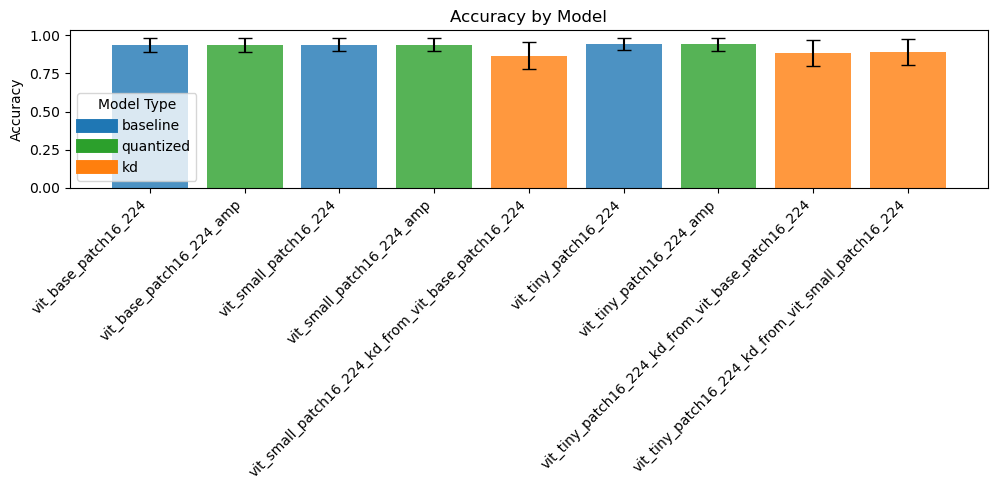

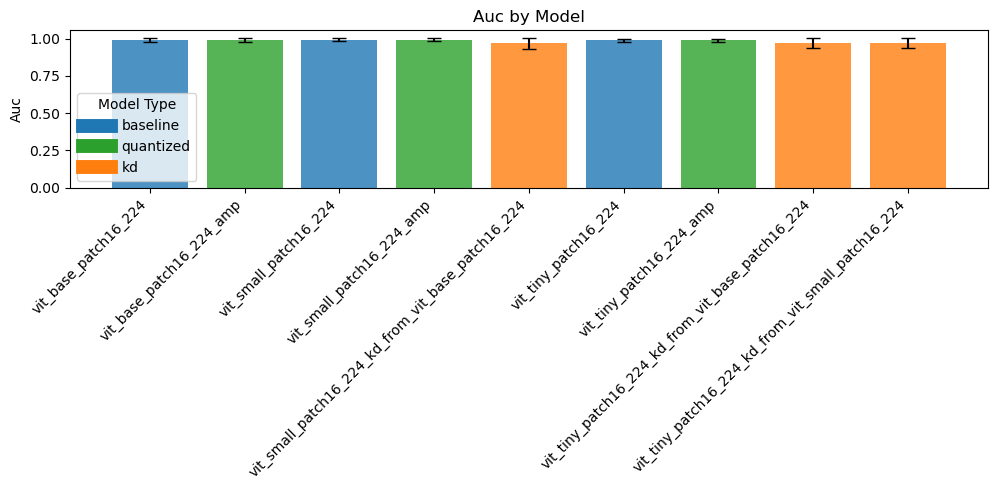

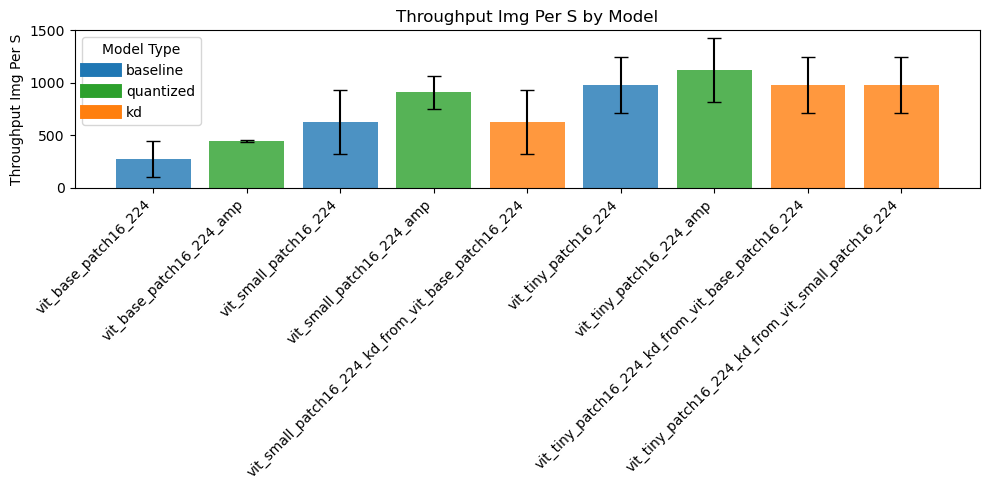

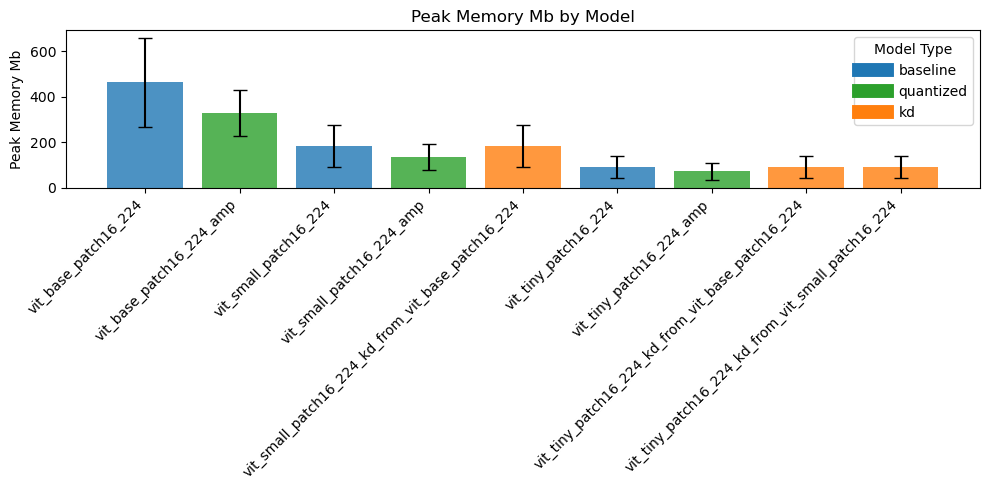

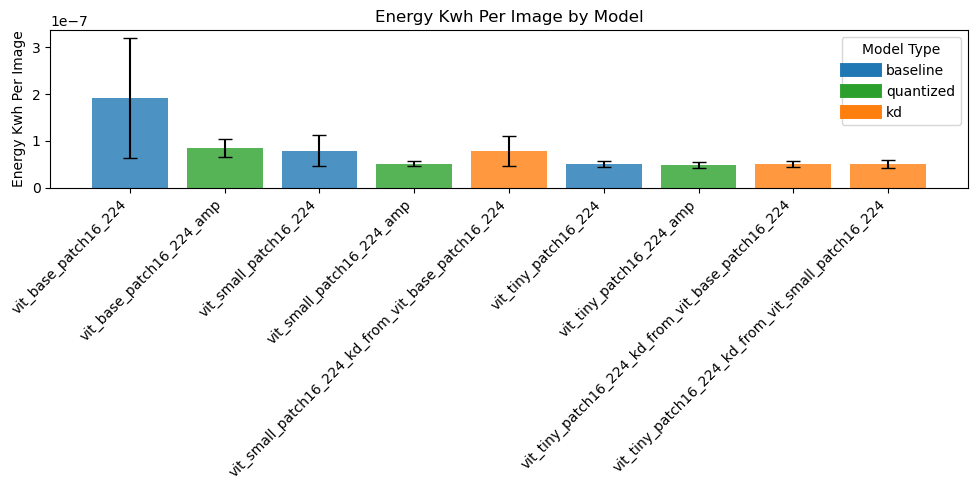

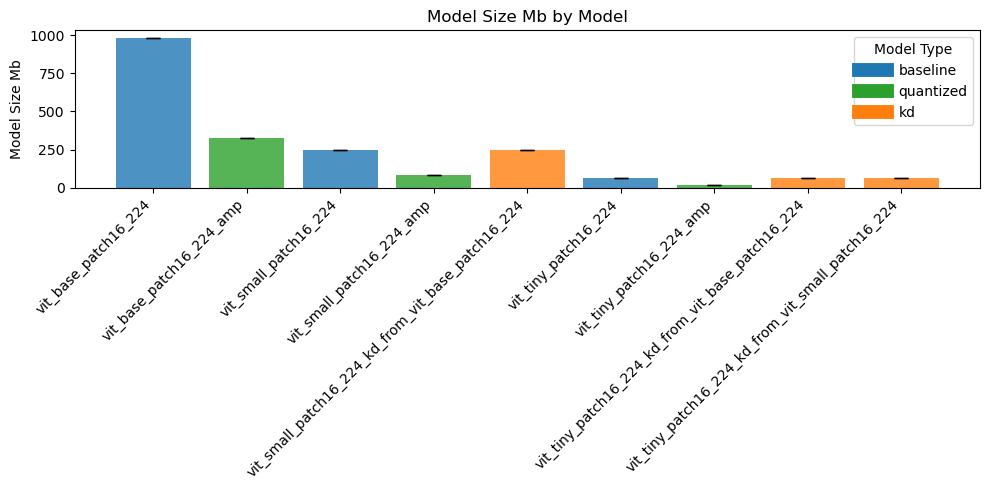

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === Load data with multi-level headers ===
csv_path = "/Users/arihangupta/Downloads/pruning_project_data/Vision/Benchmakring_results/global_summary.csv"
df = pd.read_csv(csv_path, header=[0, 1], sep="\t|,", engine="python")

# Flatten multi-index columns
df.columns = ["_".join(col).strip() for col in df.columns.values]
# Remove weird suffixes like "_Unnamed: 0_level_1"
df.columns = [col.split("_Unnamed")[0] for col in df.columns]

# Check the result
print(df.columns)

# === Metrics to visualize ===
metrics = {
    "accuracy": ("accuracy_mean", "accuracy_std"),
    "auc": ("auc_mean", "auc_std"),
    "throughput_img_per_s": ("throughput_img_per_s_mean", "throughput_img_per_s_std"),
    "peak_memory_mb": ("peak_memory_mb_mean", "peak_memory_mb_std"),
    "energy_kwh_per_image": ("energy_kwh_per_image_mean", "energy_kwh_per_image_std"),
    "model_size_mb": ("model_size_mb_first", None),  # no std column
}

# === Assign colors by model type ===
type_colors = {"baseline": "#1f77b4", "quantized": "#2ca02c", "kd": "#ff7f0e"}

# === Generate plots ===
for metric, (mean_col, std_col) in metrics.items():
    if mean_col not in df.columns:
        print(f"⚠️ Skipping {metric} — column not found in CSV.")
        continue

    means = df[mean_col]
    stds = df[std_col] if std_col in df.columns else np.zeros_like(means)
    model_names = df["model_name"]
    model_types = df["model_type"]

    x = np.arange(len(df))
    colors = [type_colors.get(t, "gray") for t in model_types]

    plt.figure(figsize=(10, 5))
    plt.bar(x, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
    plt.xticks(x, model_names, rotation=45, ha="right")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(f"{metric.replace('_', ' ').title()} by Model")
    plt.tight_layout()

    handles = [plt.Line2D([0], [0], color=c, lw=10) for c in type_colors.values()]
    plt.legend(handles, type_colors.keys(), title="Model Type")

    plt.show()


In [3]:
import pandas as pd

csv_path = "/Users/arihangupta/Downloads/pruning_project_data/Vision/Benchmakring_results/global_summary.csv"
df = pd.read_csv(csv_path, header=[0, 1], sep="\t|,", engine="python")

# Flatten headers
df.columns = ["_".join(col).strip() for col in df.columns.values]
print(df.columns.tolist())


['model_name_Unnamed: 0_level_1', 'model_type_Unnamed: 1_level_1', 'accuracy_mean', 'accuracy_std', 'auc_mean', 'auc_std', 'throughput_img_per_s_mean', 'throughput_img_per_s_std', 'throughput_img_per_s_median', 'latency_per_image_ms_mean', 'latency_per_image_ms_std', 'latency_per_image_ms_median', 'peak_memory_mb_mean', 'peak_memory_mb_std', 'energy_kwh_per_image_mean', 'energy_kwh_per_image_std', 'model_size_mb_first', 'total_params_first']


Loading data from: /Users/arihangupta/Downloads/pruning_project_data/Vision/Benchmakring_results/bloodmnist_summary.csv

Columns found: ['dataset', 'model_name', 'model_type', 'batch_size', 'precision', 'n_runs', 'mean_accuracy', 'std_accuracy', 'mean_auc', 'std_auc', 'mean_throughput', 'std_throughput', 'median_throughput', 'mean_latency_ms', 'std_latency_ms', 'median_latency_ms', 'mean_peak_memory_mb', 'std_peak_memory_mb', 'mean_energy_kwh', 'mean_energy_per_img', 'mean_emissions_kg', 'model_size_mb', 'total_params']
Shape: (27, 23)

Filtering to batch size 64 only...
After filtering: (9, 23)

Data appears to already be aggregated (n_runs = 3)
Using data as-is without further aggregation

Processing 9 model configurations

SUMMARY STATISTICS

Total model configurations: 9

Comparison groups:
  group1_baseline_family: 3 configurations
  group2_base_distillation: 3 configurations
  group3_small_family: 2 configurations
  group4_tiny_family: 1 configurations

--------------------------

/var/folders/6j/g0y2v65d04z9ylxbfz12hqm40000gn/T/ipykernel_3592/3913557119.py:324: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Creating efficiency frontiers...
  Plotting efficiency frontiers

All visualizations saved to: /Users/arihangupta/Downloads/pruning_project_data/Vision/Benchmakring_results/visulizations
Aggregated data saved to: /Users/arihangupta/Downloads/pruning_project_data/Vision/Benchmakring_results/visulizations/aggregated_results.csv


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

def load_and_aggregate_data(file_path):
    """Load data and aggregate across the 3 runs for each configuration."""
    df = pd.read_csv(file_path, sep='\t')
    
    # Group by model configuration and aggregate
    group_cols = ['model_name', 'model_type', 'batch_size', 'precision']
    
    agg_dict = {
        'mean_accuracy': 'mean',
        'mean_auc': 'mean',
        'mean_throughput': 'mean',
        'mean_energy_per_img': 'mean',
        'mean_latency_ms': 'mean',
        'mean_peak_memory_mb': 'mean',
        'model_size_mb': 'first',  # Same for all runs
        'total_params': 'first'     # Same for all runs
    }
    
    aggregated = df.groupby(group_cols).agg(agg_dict).reset_index()
    
    # Create display name
    aggregated['display_name'] = (
        aggregated['model_name'].str.replace('vit_', '').str.replace('_patch16_224', '') + 
        '\n(' + aggregated['model_type'] + ')'
    )
    
    return aggregated

def plot_throughput_comparison(df, output_dir):
    """Plot throughput comparison across models."""
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Sort by throughput
    df_sorted = df.sort_values('mean_throughput', ascending=False)
    
    colors = {'baseline': '#3b82f6', 'quantized': '#10b981', 'kd': '#f59e0b'}
    bar_colors = [colors[mt] for mt in df_sorted['model_type']]
    
    bars = ax.bar(range(len(df_sorted)), df_sorted['mean_throughput'], color=bar_colors)
    ax.set_xticks(range(len(df_sorted)))
    ax.set_xticklabels(df_sorted['display_name'], rotation=45, ha='right')
    ax.set_ylabel('Throughput (images/sec)', fontsize=12, fontweight='bold')
    ax.set_title('Model Throughput Comparison', fontsize=14, fontweight='bold', pad=20)
    ax.grid(axis='y', alpha=0.3)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors[k], label=k.capitalize()) 
                      for k in colors.keys() if k in df['model_type'].values]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.savefig(output_dir / 'throughput_comparison.png', dpi=300, bbox_inches='tight')
    plt.close()

def plot_energy_efficiency(df, output_dir):
    """Plot energy consumption per image."""
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Convert to nanojoules for readability
    df['energy_nj'] = df['mean_energy_per_img'] * 1e9
    df_sorted = df.sort_values('energy_nj')
    
    colors = {'baseline': '#3b82f6', 'quantized': '#10b981', 'kd': '#f59e0b'}
    bar_colors = [colors[mt] for mt in df_sorted['model_type']]
    
    bars = ax.bar(range(len(df_sorted)), df_sorted['energy_nj'], color=bar_colors)
    ax.set_xticks(range(len(df_sorted)))
    ax.set_xticklabels(df_sorted['display_name'], rotation=45, ha='right')
    ax.set_ylabel('Energy per Image (nJ)', fontsize=12, fontweight='bold')
    ax.set_title('Energy Efficiency Comparison', fontsize=14, fontweight='bold', pad=20)
    ax.grid(axis='y', alpha=0.3)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors[k], label=k.capitalize()) 
                      for k in colors.keys() if k in df['model_type'].values]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.savefig(output_dir / 'energy_efficiency.png', dpi=300, bbox_inches='tight')
    plt.close()

def plot_accuracy_vs_size(df, output_dir):
    """Plot accuracy vs model size scatter plot."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = {'baseline': '#3b82f6', 'quantized': '#10b981', 'kd': '#f59e0b'}
    
    for model_type in df['model_type'].unique():
        mask = df['model_type'] == model_type
        ax.scatter(df[mask]['model_size_mb'], 
                  df[mask]['mean_accuracy'] * 100,
                  c=colors[model_type], 
                  label=model_type.capitalize(),
                  s=100, 
                  alpha=0.7,
                  edgecolors='black',
                  linewidth=1)
    
    ax.set_xlabel('Model Size (MB)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_title('Accuracy vs Model Size', fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='best')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_dir / 'accuracy_vs_size.png', dpi=300, bbox_inches='tight')
    plt.close()

def plot_auc_comparison(df, output_dir):
    """Plot AUC comparison across models."""
    fig, ax = plt.subplots(figsize=(14, 6))
    
    df_sorted = df.sort_values('mean_auc', ascending=False)
    
    colors = {'baseline': '#3b82f6', 'quantized': '#10b981', 'kd': '#f59e0b'}
    bar_colors = [colors[mt] for mt in df_sorted['model_type']]
    
    bars = ax.bar(range(len(df_sorted)), df_sorted['mean_auc'] * 100, color=bar_colors)
    ax.set_xticks(range(len(df_sorted)))
    ax.set_xticklabels(df_sorted['display_name'], rotation=45, ha='right')
    ax.set_ylabel('AUC (%)', fontsize=12, fontweight='bold')
    ax.set_title('AUC Performance Comparison', fontsize=14, fontweight='bold', pad=20)
    ax.set_ylim([99.0, 100.0])
    ax.grid(axis='y', alpha=0.3)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors[k], label=k.capitalize()) 
                      for k in colors.keys() if k in df['model_type'].values]
    ax.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.savefig(output_dir / 'auc_comparison.png', dpi=300, bbox_inches='tight')
    plt.close()

def plot_throughput_vs_energy(df, output_dir):
    """Plot throughput vs energy trade-off."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    df['energy_nj'] = df['mean_energy_per_img'] * 1e9
    
    colors = {'baseline': '#3b82f6', 'quantized': '#10b981', 'kd': '#f59e0b'}
    
    for model_type in df['model_type'].unique():
        mask = df['model_type'] == model_type
        ax.scatter(df[mask]['mean_throughput'], 
                  df[mask]['energy_nj'],
                  c=colors[model_type], 
                  label=model_type.capitalize(),
                  s=100, 
                  alpha=0.7,
                  edgecolors='black',
                  linewidth=1)
    
    ax.set_xlabel('Throughput (images/sec)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Energy per Image (nJ)', fontsize=12, fontweight='bold')
    ax.set_title('Throughput vs Energy Trade-off', fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='best')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_dir / 'throughput_vs_energy.png', dpi=300, bbox_inches='tight')
    plt.close()

def plot_parameters_comparison(df, output_dir):
    """Plot model parameters comparison."""
    fig, ax = plt.subplots(figsize=(14, 6))
    
    df['params_millions'] = df['total_params'] / 1e6
    df_sorted = df.sort_values('params_millions', ascending=False)
    
    colors = {'baseline': '#3b82f6', 'quantized': '#10b981', 'kd': '#f59e0b'}
    bar_colors = [colors[mt] for mt in df_sorted['model_type']]
    
    bars = ax.bar(range(len(df_sorted)), df_sorted['params_millions'], color=bar_colors)
    ax.set_xticks(range(len(df_sorted)))
    ax.set_xticklabels(df_sorted['display_name'], rotation=45, ha='right')
    ax.set_ylabel('Parameters (Millions)', fontsize=12, fontweight='bold')
    ax.set_title('Model Parameter Count', fontsize=14, fontweight='bold', pad=20)
    ax.grid(axis='y', alpha=0.3)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors[k], label=k.capitalize()) 
                      for k in colors.keys() if k in df['model_type'].values]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.savefig(output_dir / 'parameters_comparison.png', dpi=300, bbox_inches='tight')
    plt.close()

def plot_multi_metric_heatmap(df, output_dir):
    """Create a heatmap showing normalized metrics for all models."""
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Select key metrics
    metrics = ['mean_accuracy', 'mean_auc', 'mean_throughput', 
               'mean_energy_per_img', 'model_size_mb']
    
    # Create pivot table
    heatmap_data = df[['display_name'] + metrics].set_index('display_name')
    
    # Normalize metrics (0-1 scale, invert energy and size since lower is better)
    normalized = heatmap_data.copy()
    for col in metrics:
        if col in ['mean_energy_per_img', 'model_size_mb']:
            # Invert: lower is better
            normalized[col] = 1 - (heatmap_data[col] - heatmap_data[col].min()) / (heatmap_data[col].max() - heatmap_data[col].min())
        else:
            # Normal: higher is better
            normalized[col] = (heatmap_data[col] - heatmap_data[col].min()) / (heatmap_data[col].max() - heatmap_data[col].min())
    
    # Rename columns for display
    normalized.columns = ['Accuracy', 'AUC', 'Throughput', 'Energy Eff.', 'Size Eff.']
    
    sns.heatmap(normalized, annot=True, fmt='.2f', cmap='RdYlGn', 
                cbar_kws={'label': 'Normalized Score (0-1)'}, 
                linewidths=0.5, ax=ax)
    ax.set_title('Multi-Metric Performance Heatmap (Normalized)', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    plt.tight_layout()
    plt.savefig(output_dir / 'multi_metric_heatmap.png', dpi=300, bbox_inches='tight')
    plt.close()

def print_summary_statistics(df):
    """Print summary statistics."""
    print("\n" + "="*80)
    print("SUMMARY STATISTICS")
    print("="*80)
    
    print(f"\nTotal model configurations: {len(df)}")
    print(f"\nModel types: {df['model_type'].unique()}")
    print(f"Batch sizes: {sorted(df['batch_size'].unique())}")
    print(f"Precisions: {df['precision'].unique()}")
    
    print("\n" + "-"*80)
    print("AVERAGE METRICS BY MODEL TYPE")
    print("-"*80)
    
    for model_type in df['model_type'].unique():
        subset = df[df['model_type'] == model_type]
        print(f"\n{model_type.upper()}:")
        print(f"  Accuracy: {subset['mean_accuracy'].mean()*100:.2f}%")
        print(f"  AUC: {subset['mean_auc'].mean()*100:.2f}%")
        print(f"  Throughput: {subset['mean_throughput'].mean():.2f} img/s")
        print(f"  Energy/Image: {subset['mean_energy_per_img'].mean()*1e9:.2f} nJ")
        print(f"  Model Size: {subset['model_size_mb'].mean():.2f} MB")
    
    print("\n" + "-"*80)
    print("TOP 5 MODELS BY THROUGHPUT")
    print("-"*80)
    top_throughput = df.nlargest(5, 'mean_throughput')[
        ['display_name', 'mean_throughput', 'model_type', 'precision', 'batch_size']
    ]
    print(top_throughput.to_string(index=False))
    
    print("\n" + "-"*80)
    print("TOP 5 MODELS BY ENERGY EFFICIENCY (LOWEST)")
    print("-"*80)
    df['energy_nj'] = df['mean_energy_per_img'] * 1e9
    top_energy = df.nsmallest(5, 'energy_nj')[
        ['display_name', 'energy_nj', 'model_type', 'precision', 'batch_size']
    ]
    print(top_energy.to_string(index=False))
    
    print("\n" + "="*80 + "\n")

def main(data_path, output_dir='./visualizations'):
    """Main function to generate all visualizations."""
    # Create output directory
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True, parents=True)
    
    print(f"Loading data from: {data_path}")
    df = load_and_aggregate_data(data_path)
    
    print(f"Aggregated {len(df)} model configurations")
    
    # Print summary statistics
    print_summary_statistics(df)
    
    # Generate all plots
    print("Generating visualizations...")
    
    print("  - Throughput comparison")
    plot_throughput_comparison(df, output_dir)
    
    print("  - Energy efficiency")
    plot_energy_efficiency(df, output_dir)
    
    print("  - Accuracy vs size")
    plot_accuracy_vs_size(df, output_dir)
    
    print("  - AUC comparison")
    plot_auc_comparison(df, output_dir)
    
    print("  - Throughput vs energy trade-off")
    plot_throughput_vs_energy(df, output_dir)
    
    print("  - Parameters comparison")
    plot_parameters_comparison(df, output_dir)
    
    print("  - Multi-metric heatmap")
    plot_multi_metric_heatmap(df, output_dir)
    
    print(f"\nAll visualizations saved to: {output_dir.absolute()}")
    
    # Save aggregated data to CSV
    output_csv = output_dir / 'aggregated_results.csv'
    df.to_csv(output_csv, index=False)
    print(f"Aggregated data saved to: {output_csv}")

if __name__ == "__main__":
    # USAGE: Replace with your actual file path
    DATA_PATH = "/Users/arihangupta/Downloads/pruning_project_data/Vision/Benchmakring_results/bloodmnist_summary.csv"  # <-- UPDATE THIS PATH
    
    main(DATA_PATH)
    
    # Optional: Filter by precision or batch size
    # main(DATA_PATH, output_dir='./visualizations_amp')  # Then filter df in main() function

Loading data from: /Users/arihangupta/Downloads/pruning_project_data/Vision/Benchmakring_results/bloodmnist_summary.csv


KeyError: 'model_name'